# Import

In [1]:
import pandas as pd
import numpy as np

In [2]:
# data_path = 'E:\멋사\practice\study_files/'
data_path = 'D:\VS_Code/'

# 데이터 불러오기

In [18]:
# df1 = pd.read_csv(f'{data_path}2019-Dec.csv')
# df2 = pd.read_csv(f'{data_path}2019-Nov.csv')
# df3 = pd.read_csv(f'{data_path}2019-Oct.csv')
# df4 = pd.read_csv(f'{data_path}2020-Feb.csv')
# df5 = pd.read_csv(f'{data_path}2020-Jan.csv')

# EDA

In [4]:
# # 기존 데이터프레임 리스트
# dfs = [df1, df2, df3, df4, df5]

# # 데이터프레임 연결
# df_combined = pd.concat(dfs, ignore_index=True)

# # 연결된 데이터프레임 확인
# print(df_combined.head())
# print(df_combined.shape)

In [3]:
df_combined = pd.read_csv('df_combined.csv')
print(df_combined.shape)

(20692840, 9)


In [6]:
df_combined.head(3)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554


In [4]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20692840 entries, 0 to 20692839
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 1.4+ GB


In [22]:
df_combined.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    20339246
brand             8757117
price                   0
user_id                 0
user_session         4598
dtype: int64

In [23]:
df_combined['brand'].value_counts()

brand
runail       1528908
irisk        1033852
masura        861763
grattol       852591
bpw.style     434813
              ...   
shifei             9
vl-gel             7
dessata            6
gena               3
pueen              1
Name: count, Length: 273, dtype: int64

- Brand 결측치 -> Unknown

In [4]:
# 'brand' 컬럼의 결측치(NaN)를 'Unknown' 문자열로 대체합니다.
df_combined['brand'].fillna('Unknown', inplace=True)

# 확인
print(df_combined.isnull().sum())
# 'Unknown'이 가장 큰 값으로 추가되었는지 확인

C:\Users\user\AppData\Local\Temp\ipykernel_8464\3104901736.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined['brand'].fillna('Unknown', inplace=True)


event_time              0
event_type              0
product_id              0
category_id             0
category_code    20339246
brand                   0
price                   0
user_id                 0
user_session         4598
dtype: int64


In [25]:
df_combined.corr(numeric_only= True)

,product_id,category_id,price,user_id
product_id,1.000000,0.029570,-0.020206,-0.015683
category_id,0.029570,1.000000,0.010145,0.013734
price,-0.020206,0.010145,1.000000,0.035366
user_id,-0.015683,0.013734,0.035366,1.000000


- 결측치가 row의 수 비슷해 category_id 제거

In [5]:
df_combined.drop('category_code', axis=1, inplace=True)

In [10]:
df_combined.isnull().sum()

event_time         0
event_type         0
product_id         0
category_id        0
brand              0
price              0
user_id            0
user_session    4598
dtype: int64

In [28]:
df_combined['event_time'].value_counts()

event_time
2020-02-15 16:08:37 UTC    3087
2020-02-05 09:55:55 UTC    2067
2020-02-06 18:10:38 UTC    1982
2020-02-05 09:55:40 UTC    1892
2020-02-15 16:08:56 UTC    1075
                           ... 
2019-10-13 00:27:19 UTC       1
2019-10-13 00:27:17 UTC       1
2019-10-13 00:27:16 UTC       1
2019-10-13 00:27:13 UTC       1
2020-01-31 23:59:58 UTC       1
Name: count, Length: 8782890, dtype: int64

In [6]:
df_combined['event_time'] = pd.to_datetime(df_combined['event_time'].str.replace(' UTC', '', regex=False))

In [7]:
# 연/월/일/시/분/초 추출
df_combined['year'] = df_combined['event_time'].dt.year
df_combined['month'] = df_combined['event_time'].dt.month
df_combined['day'] = df_combined['event_time'].dt.day
df_combined['hour'] = df_combined['event_time'].dt.hour
df_combined['minute'] = df_combined['event_time'].dt.minute
df_combined['second'] = df_combined['event_time'].dt.second

In [13]:
df_combined.head(3)

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second
0,2019-12-01 00:00:00,remove_from_cart,5712790,1487580005268456287,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,2019,12,1,0,0,0
1,2019-12-01 00:00:00,view,5764655,1487580005411062629,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,2019,12,1,0,0,0
2,2019-12-01 00:00:02,cart,4958,1487580009471148064,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019,12,1,0,0,2


In [14]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20692840 entries, 0 to 20692839
Data columns (total 14 columns):
 #   Column        Dtype         
---  ------        -----         
 0   event_time    datetime64[ns]
 1   event_type    object        
 2   product_id    int64         
 3   category_id   int64         
 4   brand         object        
 5   price         float64       
 6   user_id       int64         
 7   user_session  object        
 8   year          int32         
 9   month         int32         
 10  day           int32         
 11  hour          int32         
 12  minute        int32         
 13  second        int32         
dtypes: datetime64[ns](1), float64(1), int32(6), int64(3), object(3)
memory usage: 1.7+ GB


- 시각화

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# event_type의 빈도수를 계산하고 시각화합니다.
from matplotlib import font_manager, rc

# 1. 경고 메시지 무시 설정
# 'UserWarning'과 'FutureWarning'을 포함한 모든 경고를 무시하도록 설정합니다.
warnings.filterwarnings('ignore')
font_name = font_manager.FontProperties(fname="C:/Windows/Fonts/malgun.ttf").get_name()
# 만약 위 코드가 오류나면 아래 코드를 사용해 시스템 기본 폰트 설정
# try:
#     font_name = 'Malgun Gothic' # Windows
# except:
#     font_name = 'AppleGothic' # Mac

rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

In [33]:
df_combined[df_combined['price'] < 0]

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second
693061,2019-12-06 08:44:06,purchase,5670257,1487580014042939619,Unknown,-15.87,410016187,2414f145-f7fa-473f-9d74-41e5694178a0,2019,12,6,8,44,6
942049,2019-12-08 12:38:35,purchase,5670257,1487580014042939619,Unknown,-15.87,579811230,001d3051-07af-1cef-f5e4-10443d9742b9,2019,12,8,12,38,35
1633142,2019-12-13 08:44:49,purchase,5716859,1487580014042939619,Unknown,-47.62,414087247,6617078d-899a-4b89-8538-b70e505bff38,2019,12,13,8,44,49
1667368,2019-12-13 13:48:10,purchase,5716857,1487580014042939619,Unknown,-23.81,584773479,a3f156d9-b7fc-444d-8899-920715cca75d,2019,12,13,13,48,10
2143701,2019-12-17 10:37:03,purchase,5670257,1487580014042939619,Unknown,-15.87,584498077,ecbf0f7c-3c10-42e8-9af6-1397b5428afa,2019,12,17,10,37,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19619234,2020-01-24 21:30:42,purchase,5716859,1487580014042939619,Unknown,-47.62,605668162,1609dc0c-7112-468d-8b5c-1cdcabd4f674,2020,1,24,21,30,42
19850269,2020-01-26 18:55:52,purchase,5716861,1487580014042939619,Unknown,-79.37,606448681,466cd335-b273-49a4-aefb-3077b5fcd87e,2020,1,26,18,55,52
19914917,2020-01-27 08:04:32,view,5716861,1487580014042939619,Unknown,-79.37,531900924,38fe5484-6b5f-44e6-8092-3713df449df7,2020,1,27,8,4,32
19996527,2020-01-27 14:39:33,purchase,5716859,1487580014042939619,Unknown,-47.62,544827743,9bddc864-778a-987e-7f59-a98410752421,2020,1,27,14,39,33


In [34]:
non_purchase_negative_price = df_combined[
    (df_combined['price'] < 0) & 
    (df_combined['event_type'] != 'purchase')
]

# 결과 출력
print(f"--- ⚠️ 가격이 음수이면서 'purchase'가 아닌 이벤트 (총 {len(non_purchase_negative_price)}건) ---")
if len(non_purchase_negative_price) > 0:
    print(non_purchase_negative_price.head())
else:
    print("해당 조건에 맞는 데이터가 없습니다.")

# 이벤트 타입 분포 확인 (이벤트가 있다면)
if len(non_purchase_negative_price) > 0:
    print("\n--- 해당 데이터의 event_type 분포 ---")
    print(non_purchase_negative_price['event_type'].value_counts())

--- ⚠️ 가격이 음수이면서 'purchase'가 아닌 이벤트 (총 5건) ---
                  event_time        event_type  product_id  \
16381402 2020-02-29 17:10:44  remove_from_cart     5716857   
16381480 2020-02-29 17:11:27  remove_from_cart     5716857   
16878100 2020-01-05 10:49:53              view     5716857   
17935633 2020-01-13 11:26:36  remove_from_cart     5716859   
19914917 2020-01-27 08:04:32              view     5716861   

                  category_id    brand  price    user_id  \
16381402  1487580014042939619  Unknown -23.81  621914288   
16381480  1487580014042939619  Unknown -23.81  621914288   
16878100  1487580014042939619  Unknown -23.81  439078759   
17935633  1487580014042939619  Unknown -47.62  600263955   
19914917  1487580014042939619  Unknown -79.37  531900924   

                                  user_session  year  month  day  hour  \
16381402  bf16ca09-b11f-4c3c-a332-1bfdbb65d303  2020      2   29    17   
16381480  bf16ca09-b11f-4c3c-a332-1bfdbb65d303  2020      2   29    17 

In [35]:
df_combined[(df_combined['category_id'] == 1487580014042939619) & (df_combined['brand'] != 'NaN')]

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second
4032,2019-12-01 03:02:53,view,5670256,1487580014042939619,Unknown,15.87,580017316,56c1d343-3daf-49ff-8ad7-a12e188ba3b1,2019,12,1,3,2,53
4035,2019-12-01 03:03:05,cart,5670256,1487580014042939619,Unknown,15.87,580017316,56c1d343-3daf-49ff-8ad7-a12e188ba3b1,2019,12,1,3,3,5
46047,2019-12-01 12:01:34,view,5670256,1487580014042939619,Unknown,15.87,580017316,8ac79e18-e2ee-4f1f-900b-b42afef372b2,2019,12,1,12,1,34
58574,2019-12-01 13:41:45,view,5670256,1487580014042939619,Unknown,15.87,580282180,fddaca33-ae12-471b-b470-52a74e66e8a3,2019,12,1,13,41,45
91028,2019-12-01 17:57:59,view,5670256,1487580014042939619,Unknown,15.87,475468226,c8a7b70a-8195-40c5-91e3-18cd643e58b0,2019,12,1,17,57,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587770,2020-01-31 08:07:48,remove_from_cart,5670256,1487580014042939619,Unknown,15.87,607586754,47e5d5be-3aa5-49de-a4ba-7309fddf8fd0,2020,1,31,8,7,48
20587772,2020-01-31 08:07:49,remove_from_cart,5670256,1487580014042939619,Unknown,15.87,607586754,47e5d5be-3aa5-49de-a4ba-7309fddf8fd0,2020,1,31,8,7,49
20587812,2020-01-31 08:08:10,view,5670256,1487580014042939619,Unknown,15.87,607586754,47e5d5be-3aa5-49de-a4ba-7309fddf8fd0,2020,1,31,8,8,10
20587819,2020-01-31 08:08:12,cart,5670256,1487580014042939619,Unknown,15.87,607586754,47e5d5be-3aa5-49de-a4ba-7309fddf8fd0,2020,1,31,8,8,12


# event_time

## year

- 연도별 event 발생 횟수

--- 1. 연도별 전체 이벤트 발생 횟수 ---
year
2019    12271406
2020     8421434
dtype: int64
----------------------------------------


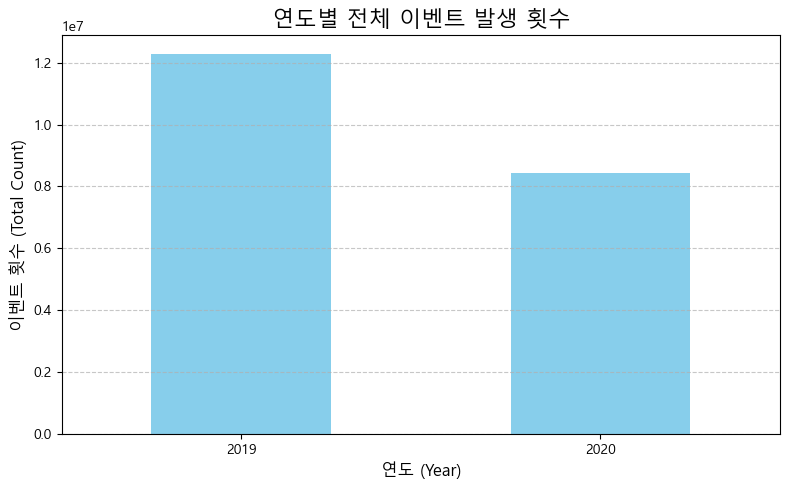

In [36]:
# 1. 연도별 그룹화 후 이벤트 개수(size) 계산
yearly_total_events = df_combined.groupby('year').size()

print("--- 1. 연도별 전체 이벤트 발생 횟수 ---")
print(yearly_total_events)
print("-" * 40)

# 2. 시각화: 연도별 전체 이벤트 추이
plt.figure(figsize=(8, 5))
yearly_total_events.plot(kind='bar', color='skyblue')

plt.title('연도별 전체 이벤트 발생 횟수', fontsize=16)
plt.xlabel('연도 (Year)', fontsize=12)
plt.ylabel('이벤트 횟수 (Total Count)', fontsize=12)
plt.xticks(rotation=0) # 연도는 회전 없이 표시
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## month

In [37]:
df_combined['month'].value_counts()

month
11    4635837
1     4264752
2     4156682
10    4102283
12    3533286
Name: count, dtype: int64

- 월별 event 발생 횟수

--- 📊 월별 총 이벤트 발생 수 ---
1     4264752
2     4156682
10    4102283
11    4635837
12    3533286
------------------------------


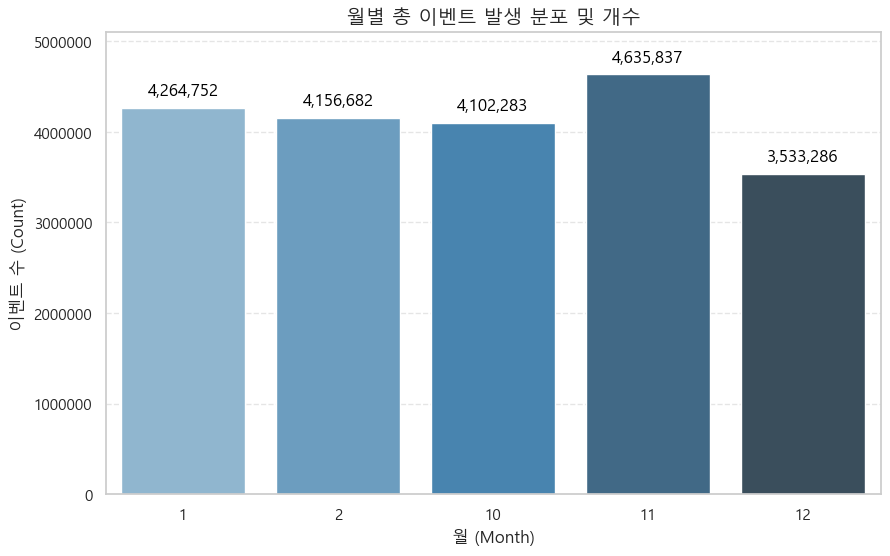

In [109]:
# 1. 월별 이벤트 수 계산
monthly_counts = df_combined['month'].value_counts().sort_index()

# 📌 추가된 코드: 월별 이벤트 수 출력
print("--- 📊 월별 총 이벤트 발생 수 ---")
# to_string을 사용하여 인덱스(월)와 값(이벤트 수)을 깔끔하게 출력합니다.
print(monthly_counts.to_string(header=False, float_format='{:,.0f}'.format))
print("-" * 30)

# 2. 시각화 객체 생성 (막대 그래프)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    # X축 값을 문자열로 변환하여 공백 제거
    x=monthly_counts.index.astype(str), 
    y=monthly_counts.values, 
    palette='Blues_d'
)

# 3. 각 막대 위에 개수(count) 텍스트 추가
for p in ax.patches:
    # 막대의 높이 (Y축 값 = Count)
    height = p.get_height()
    # 텍스트를 표시할 위치 설정
    ax.text(
        # X 위치: 막대의 중앙
        p.get_x() + p.get_width() / 2., 
        # Y 위치: 막대의 높이 바로 위 (약간의 간격 추가)
        height + (monthly_counts.max() * 0.02), # Y축 최대값의 약 2%를 간격으로 사용
        # 표시할 텍스트: 정수 형태로 포맷 (쉼표 포함)
        '{:,.0f}'.format(height), 
        ha = 'center', # 가로 정렬: 중앙
        va = 'bottom', # 세로 정렬: 아래
        fontsize = 12,
        color = 'black'
    )

# 4. 그래프 설정
plt.title('월별 총 이벤트 발생 분포 및 개수', fontsize=14)
plt.xlabel('월 (Month)')
plt.ylabel('이벤트 수 (Count)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, monthly_counts.max() * 1.1) # Y축 범위를 조정하여 레이블이 잘리지 않도록 함
plt.show()

## hour

- 시간별 event 발생 횟수

--- ⏰ 시간대 4분할 이벤트 발생 수 ---
00-05시 (새벽)    1875254
06-11시 (오전)    6403731
12-17시 (오후)    6878911
18-23시 (저녁)    5534944
----------------------------------------


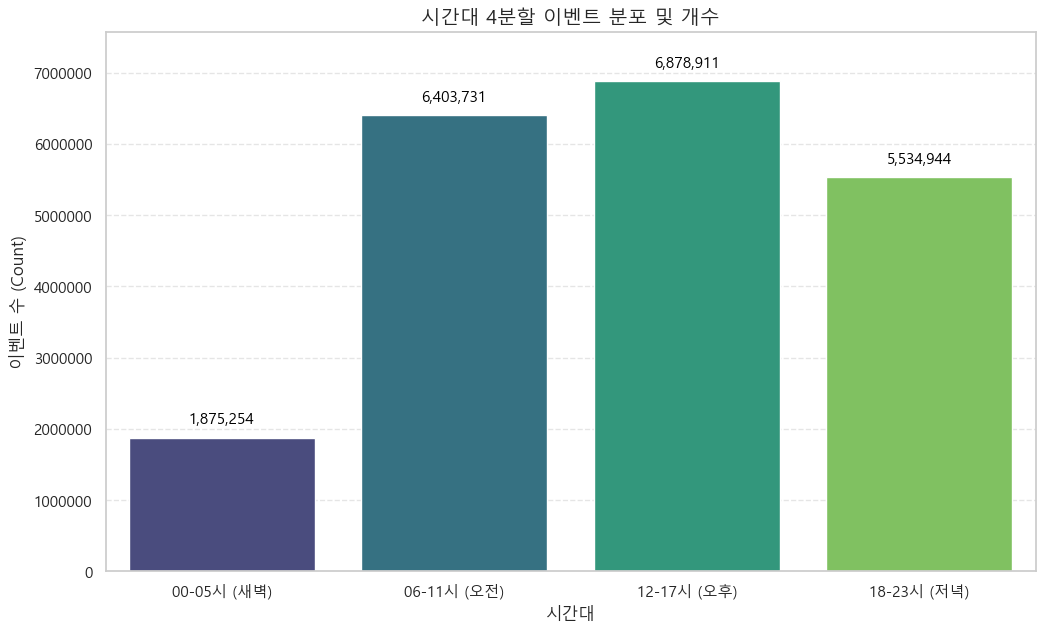

In [110]:
# 3. 0시부터 23시까지의 시간을 4등분하여 범주화
bins = [-1, 5, 11, 17, 23]
labels = ['00-05시 (새벽)', '06-11시 (오전)', '12-17시 (오후)', '18-23시 (저녁)']

# df_combined['hour'] 컬럼이 준비되었다고 가정하고 time_segment를 생성
# (이전에 df_combined['hour']를 추출하는 코드가 있었다고 가정합니다)
if 'time_segment' not in df_combined.columns:
    df_combined['time_segment'] = pd.cut(
        df_combined['hour'],
        bins=bins,
        labels=labels,
        right=True,
        include_lowest=True
    ).astype(str)

# 4. 시간대별 이벤트 수 계산 및 시각화 객체 생성
segment_counts = df_combined['time_segment'].value_counts().reindex(labels) # 순서를 labels로 재정렬

# 📌 추가된 코드: 시간대별 이벤트 수 출력
print("--- ⏰ 시간대 4분할 이벤트 발생 수 ---")
# to_string을 사용하여 인덱스(시간대)와 값(이벤트 수)을 깔끔하게 출력합니다.
print(segment_counts.to_string(header=False, float_format='{:,.0f}'.format))
print("-" * 40)

plt.figure(figsize=(12, 7)) # 그래프 크기 조정
ax = sns.barplot(
    x=segment_counts.index, 
    y=segment_counts.values, 
    order=labels, # 순서 보장
    palette='viridis'
)

# 5. 각 막대 위에 개수(count) 텍스트 추가
for p in ax.patches:
    # 막대의 높이 (Y축 값 = Count)
    height = p.get_height()
    # 텍스트를 표시할 위치 설정
    ax.text(
        # X 위치: 막대의 중앙
        p.get_x() + p.get_width() / 2., 
        # Y 위치: 막대의 높이 바로 위 (약간의 간격 추가)
        height + (segment_counts.max() * 0.02), # Y축 최대값의 약 2%를 간격으로 사용
        # 표시할 텍스트: 정수 형태로 포맷 (쉼표 포함)
        '{:,.0f}'.format(height), 
        ha = 'center', # 가로 정렬: 중앙
        va = 'bottom', # 세로 정렬: 아래
        fontsize = 11,
        color = 'black'
    )

# 6. 그래프 설정
plt.title('시간대 4분할 이벤트 분포 및 개수', fontsize=14)
plt.xlabel('시간대')
plt.ylabel('이벤트 수 (Count)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, segment_counts.max() * 1.1) # Y축 범위를 조정하여 레이블이 잘리지 않도록 함
plt.show()

## day

- 보름별 event 발생 횟수(1-15, 16-31)

--- 📅 월초/월말 이벤트 발생 수 ---
월초 (1일 ~ 15일)     10257676
월말 (16일 ~ 31일)    10435164
-----------------------------------


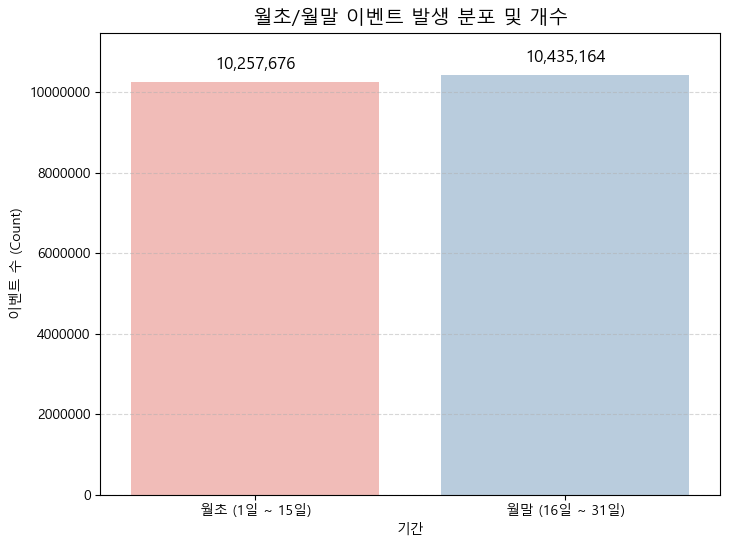

In [16]:
# 1. 'day_period' 컬럼 생성
# 조건: 'day' 컬럼의 값이 15 이하 (1일 ~ 15일)
df_combined['day_period'] = np.where(
    df_combined['day'] <= 15,
    '월초 (1일 ~ 15일)',  # 조건이 참(True)일 때
    '월말 (16일 ~ 31일)'  # 조건이 거짓(False)일 때 (16일 이후 모든 날짜 포함)
)

# 2. 기간별 이벤트 수 계산
# 순서를 명확히 하기 위해 value_counts(sort=False) 후 reindex를 통해 순서를 고정
order_labels = ['월초 (1일 ~ 15일)', '월말 (16일 ~ 31일)']
period_counts = df_combined['day_period'].value_counts().reindex(order_labels)

# 📌 추가된 코드: 월초/월말 이벤트 수 출력
print("--- 📅 월초/월말 이벤트 발생 수 ---")
# to_string을 사용하여 인덱스(기간)와 값(이벤트 수)을 깔끔하게 출력합니다.
print(period_counts.to_string(header=False, float_format='{:,.0f}'.format))
print("-" * 35)

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(8, 6)) # 그래프 크기 조정
ax = sns.barplot(
    x=period_counts.index,
    y=period_counts.values,
    order=order_labels, # 순서 보장
    palette='Pastel1'
)

# 4. 각 막대 위에 개수(count) 텍스트 추가
for p in ax.patches:
    height = p.get_height()
    # Y축 최대값의 약 2%를 간격으로 사용
    ax.text(
        p.get_x() + p.get_width() / 2., 
        height + (period_counts.max() * 0.02),
        '{:,.0f}'.format(height),
        ha = 'center',
        va = 'bottom',
        fontsize = 12,
        color = 'black'
    )

# 5. 그래프 설정
plt.title('월초/월말 이벤트 발생 분포 및 개수', fontsize=14)
plt.xlabel('기간')
plt.ylabel('이벤트 수 (Count)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, period_counts.max() * 1.1)
plt.show()

## 요일별

--- 📅 요일별 총 이벤트 발생 수 ---
Monday       3026945
Tuesday      3046446
Wednesday    3102554
Thursday     3134254
Friday       2943110
Saturday     2662163
Sunday       2777368
------------------------------


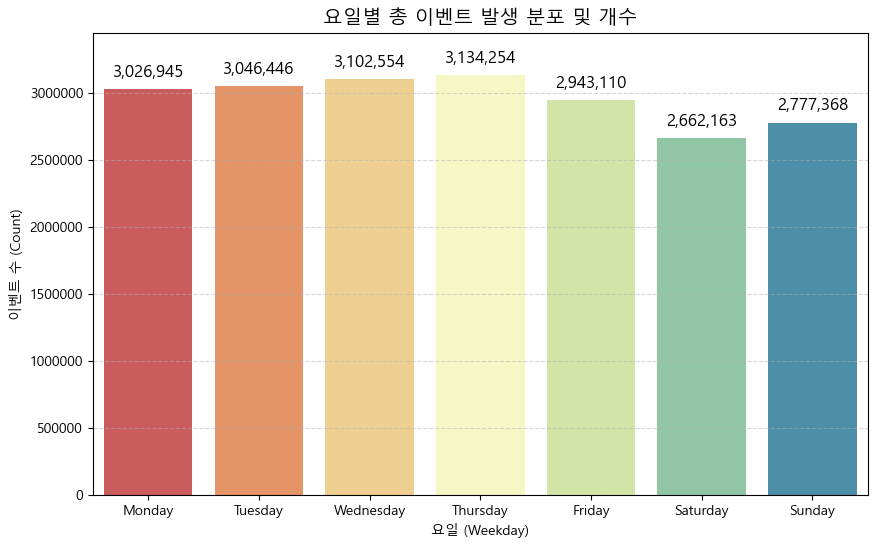

In [17]:
# 1. 요일 이름 추출
# event_time 컬럼이 datetime 타입이어야 합니다.
df_combined['weekday_name'] = df_combined['event_time'].dt.day_name()

# 2. 요일 순서 정의 (월요일부터 일요일까지)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 3. 요일별 이벤트 수 계산
weekday_counts = df_combined['weekday_name'].value_counts().reindex(weekday_order)

# 📌 추가된 코드: 요일별 이벤트 수 출력
print("--- 📅 요일별 총 이벤트 발생 수 ---")
# to_string을 사용하여 인덱스(요일)와 값(이벤트 수)을 깔끔하게 출력합니다.
print(weekday_counts.to_string(header=False, float_format='{:,.0f}'.format))
print("-" * 30)

# 4. 시각화 객체 생성 및 막대 그래프 그리기
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=weekday_counts.index,
    y=weekday_counts.values,
    order=weekday_order, # 정의된 순서로 정렬
    palette='Spectral'
)

# 5. 각 막대 위에 개수(count) 텍스트 추가
for p in ax.patches:
    height = p.get_height()
    # Y축 최대값의 약 2%를 간격으로 사용
    ax.text(
        p.get_x() + p.get_width() / 2., 
        height + (weekday_counts.max() * 0.02),
        '{:,.0f}'.format(height), 
        ha = 'center', 
        va = 'bottom',
        fontsize = 12,
        color = 'black'
    )

# 6. 그래프 설정
plt.title('요일별 총 이벤트 발생 분포 및 개수', fontsize=14)
plt.xlabel('요일 (Weekday)')
# X축 레이블을 영문 요일명 대신 한글로 표시하려면, 요일명 매핑 함수를 추가해야 합니다.
# 현재는 영어 요일명 그대로 출력됩니다.
plt.ylabel('이벤트 수 (Count)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, weekday_counts.max() * 1.1)
plt.show()

- '분, 초'는 비즈니스 제안에서 특정 상품에 대한 price를 끌어 올리기 위해 유저가 몰리는 특정 시간에 포함시키기(이벤트성 참여 유도)

# event_type

In [43]:
df_combined['event_type'].value_counts()

event_type
view                9657821
cart                5768333
remove_from_cart    3979679
purchase            1287007
Name: count, dtype: int64

- 이벤트 타입별 분포(도넛 차트)

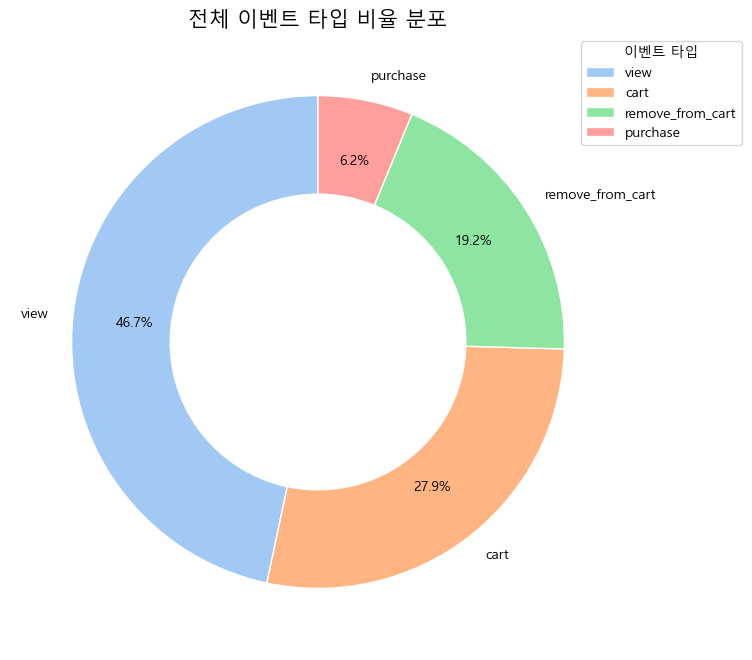

In [44]:
# 경고 메시지 무시 및 한글 폰트 설정 (이전 설정 유지)
warnings.filterwarnings('ignore')
try:
    plt.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False

# 1. event_type별 빈도수 (사용자 제공 데이터)
event_counts = pd.Series({
    'view': 9657821,
    'cart': 5768333,
    'remove_from_cart': 3979679,
    'purchase': 1287007
})

# 2. 파이/도넛 차트 시각화
plt.figure(figsize=(8, 8))

# 도넛 차트 그리기
plt.pie(
    event_counts.values,
    labels=event_counts.index,
    autopct='%1.1f%%', # 각 조각의 비율을 소수점 한 자리까지 표시
    startangle=90,     # 시작 각도를 90도로 설정 (세로 시작)
    wedgeprops=dict(width=0.4, edgecolor='w'), # 도넛 모양을 만들기 위해 중앙에 구멍을 뚫습니다.
    pctdistance=0.75, # 퍼센트 텍스트 위치 조정
    colors=sns.color_palette("pastel") # 색상 팔레트 지정
)

# 3. 그래프 설정
plt.title('전체 이벤트 타입 비율 분포', fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), title="이벤트 타입")
plt.show()

- 이벤트 타입별 발생 빈도

--- 🛒 이벤트 타입별 발생 수 ---
view                9657821
cart                5768333
remove_from_cart    3979679
purchase            1287007
-----------------------------------


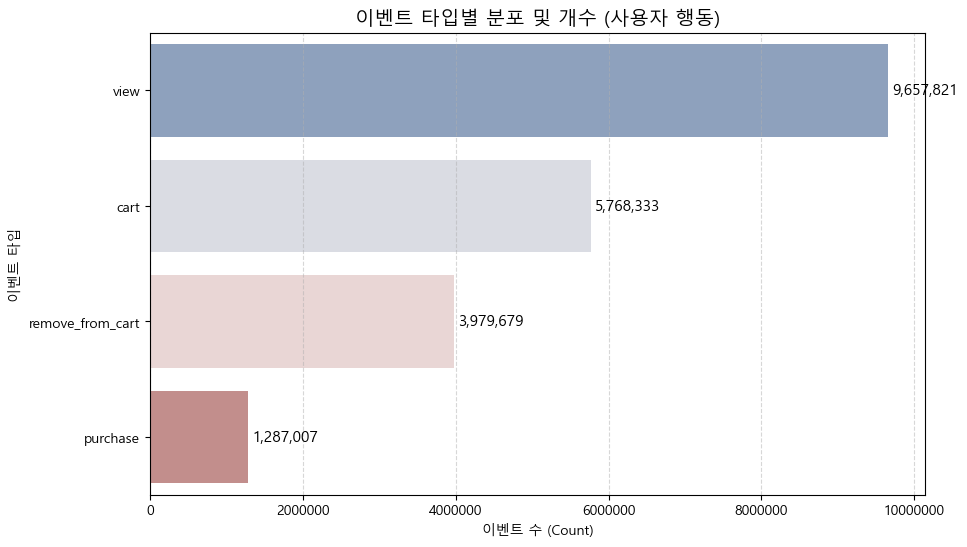

In [18]:
# 1. 이벤트 타입별 개수 계산
event_counts = df_combined['event_type'].value_counts()

# 📌 추가된 코드: 이벤트 타입별 개수 출력
print("--- 🛒 이벤트 타입별 발생 수 ---")
# to_string을 사용하여 인덱스(이벤트 타입)와 값(개수)을 깔끔하게 출력합니다.
print(event_counts.to_string(header=False, float_format='{:,.0f}'.format))
print("-" * 35)

# 2. 시각화 객체 생성 (countplot)
plt.figure(figsize=(10, 6)) # 크기를 약간 키워서 레이블 공간 확보
ax = sns.countplot(
    y='event_type',
    data=df_combined,
    order=event_counts.index, # 계산된 event_counts의 순서를 사용
    palette='vlag' 
)

# 3. 각 막대 위에 개수(count) 텍스트 추가
# ax.patches는 그래프의 모든 막대(Patch) 객체들을 담고 있습니다.
for p in ax.patches:
    # 막대의 너비 (X축 값 = Count)
    width = p.get_width()
    # 텍스트를 표시할 위치 설정
    ax.text(
        # X 위치: 막대의 너비에 약간의 간격을 더함
        width + (event_counts.max() * 0.005), # 최대값의 0.5% 정도를 간격으로 사용
        # Y 위치: 막대의 중앙
        p.get_y() + p.get_height() / 2, 
        # 표시할 텍스트: 정수 형태로 포맷 (쉼표 포함)
        '{:,.0f}'.format(width), 
        ha = 'left', # 가로 정렬: 왼쪽
        va = 'center', # 세로 정렬: 중앙
        fontsize = 11,
        color = 'black'
    )

# 4. 그래프 설정
plt.title('이벤트 타입별 분포 및 개수 (사용자 행동)', fontsize=14)
plt.xlabel('이벤트 수 (Count)')
plt.ylabel('이벤트 타입')
plt.ticklabel_format(style='plain', axis='x') # X축 표기를 1e7 대신 실제 숫자로 표시
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

- user_id별 product_id에 대한 event_type의 count

In [46]:
# 1. pivot_table 사용
try:
    user_product_event_counts = pd.pivot_table(
        df_combined,
        index=['user_id', 'product_id'],
        columns='event_type',
        aggfunc='size',
        fill_value=0
    )

    print("--- 1. pivot_table을 사용한 결과 (상위 30개) ---")
    print(user_product_event_counts.head(30))
    print(f"\n총 행 수: {len(user_product_event_counts):,}")

except Exception as e:
    print(f"❌ pivot_table에서도 오류 발생: {e}")

--- 1. pivot_table을 사용한 결과 (상위 30개) ---
event_type          cart  purchase  remove_from_cart  view
user_id product_id                                        
465496  5769989        0         0                 0     1
        5865524        0         0                 0     1
        5865526        0         0                 0     1
1120748 5240           0         0                 0     1
1180452 5881337        0         0                 0     1
1458813 5542414        0         0                 0     1
        5711078        0         0                 0     1
        5711087        0         0                 0     2
        5711117        0         0                 0     1
        5711122        0         0                 0     1
        5711135        0         0                 0     1
        5711145        0         0                 0     1
        5711154        0         0                 0     1
        5711160        0         0                 0     1
        5711172 

- purchase ≥ 1 이상만 필터링

In [25]:
# 1. pivot_table 사용: user_id와 product_id 별 event_type의 count 집계
try:
    user_product_event_counts = pd.pivot_table(
        df_combined,
        index=['user_id', 'product_id'],
        columns='event_type',
        aggfunc='size',
        fill_value=0
    )

    print("--- 1. pivot_table 생성 완료 ---")

    # 2. 'purchase'가 1 이상인 행만 필터링
    # purchase 컬럼이 존재함을 가정하고 필터링합니다.
    if 'purchase' in user_product_event_counts.columns:
        purchased_items_df = user_product_event_counts[
            user_product_event_counts['purchase'] >= 1
        ]
        
        print("\n--- 2. 'purchase' 횟수가 1 이상인 결과 (상위 30개) ---")
        print(purchased_items_df.head(30))
        
        print(f"\n총 행 수 (purchase ≥ 1): {len(purchased_items_df):,}")
        
    else:
        print("⚠️ pivot_table 결과에 'purchase' 컬럼이 없습니다. 데이터의 event_type을 확인해주세요.")

except Exception as e:
    print(f"❌ pivot_table 생성 중 오류 발생: {e}")

--- 1. pivot_table 생성 완료 ---

--- 2. 'purchase' 횟수가 1 이상인 결과 (상위 30개) ---
event_type           cart  purchase  remove_from_cart  view
user_id  product_id                                        
9794320  5724621        2         1                 0     1
         5809910        1         1                 0     3
         5811668        2         1                 1     5
         5812033        2         1                 1     3
10079204 5614842        1         1                 0     0
         5766379        1         1                 0     0
10280338 5809910        5         2                 0     2
         5809911        1         1                 0     2
         5809912        1         1                 0     2
         5816166        2         1                 1     1
         5850619        1         1                 0     0
         5850620        1         1                 0     0
         5850621        1         1                 0     0
         5850625        1 

In [27]:
# 구매 고객들의 평균 행동 수치 계산
avg_behavior = purchased_items_df.mean()

print("\n--- 📊 정량적 지표 요약 ---")
print(f"1. 구매 고객의 평균 상품 조회수(view): {avg_behavior.get('view', 0):.2f}회")
print(f"2. 구매 고객의 평균 장바구니 담기(cart): {avg_behavior.get('cart', 0):.2f}회")
print(f"3. 구매 고객의 평균 실제 구매 횟수(purchase): {avg_behavior.get('purchase', 0):.2f}회")


--- 📊 정량적 지표 요약 ---
1. 구매 고객의 평균 상품 조회수(view): 0.80회
2. 구매 고객의 평균 장바구니 담기(cart): 1.39회
3. 구매 고객의 평균 실제 구매 횟수(purchase): 1.05회


# product_id

In [48]:
df_combined['product_id'].nunique()

54571

In [49]:
df_combined['product_id'].value_counts()

product_id
5809910    141650
5809912     55606
5700037     51111
5802432     45008
5854897     44799
            ...  
5815775         1
5688893         1
5568096         1
5701709         1
5682848         1
Name: count, Length: 54571, dtype: int64

In [50]:
df_combined[df_combined['product_id'] == 5809910].head(5)

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second,time_segment,day_period,weekday_name
165,2019-12-01 00:05:57,view,5809910,1602943681873052386,grattol,5.24,579971425,548fb6a4-639a-4157-83c6-d43f80eceb12,2019,12,1,0,5,57,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
363,2019-12-01 00:10:54,view,5809910,1602943681873052386,grattol,5.24,579971563,8ef87d4a-3ab3-482a-81ca-f03a776b726a,2019,12,1,0,10,54,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
374,2019-12-01 00:11:18,cart,5809910,1602943681873052386,grattol,5.24,492321842,d1d89629-a5f8-4aab-b42e-e8c30756396f,2019,12,1,0,11,18,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
723,2019-12-01 00:21:57,view,5809910,1602943681873052386,grattol,5.24,495384210,39d97b62-20b7-49c3-aa53-683e26b7689f,2019,12,1,0,21,57,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
1806,2019-12-01 00:56:31,view,5809910,1602943681873052386,grattol,5.24,574974492,1f437fae-aad3-45d7-a0a2-c99939b769f5,2019,12,1,0,56,31,00-05시 (새벽),월초 (1일 ~ 15일),Sunday


- 상위 10개_view/cart/remove_from_cart/purchase 전환율(누적그래프)

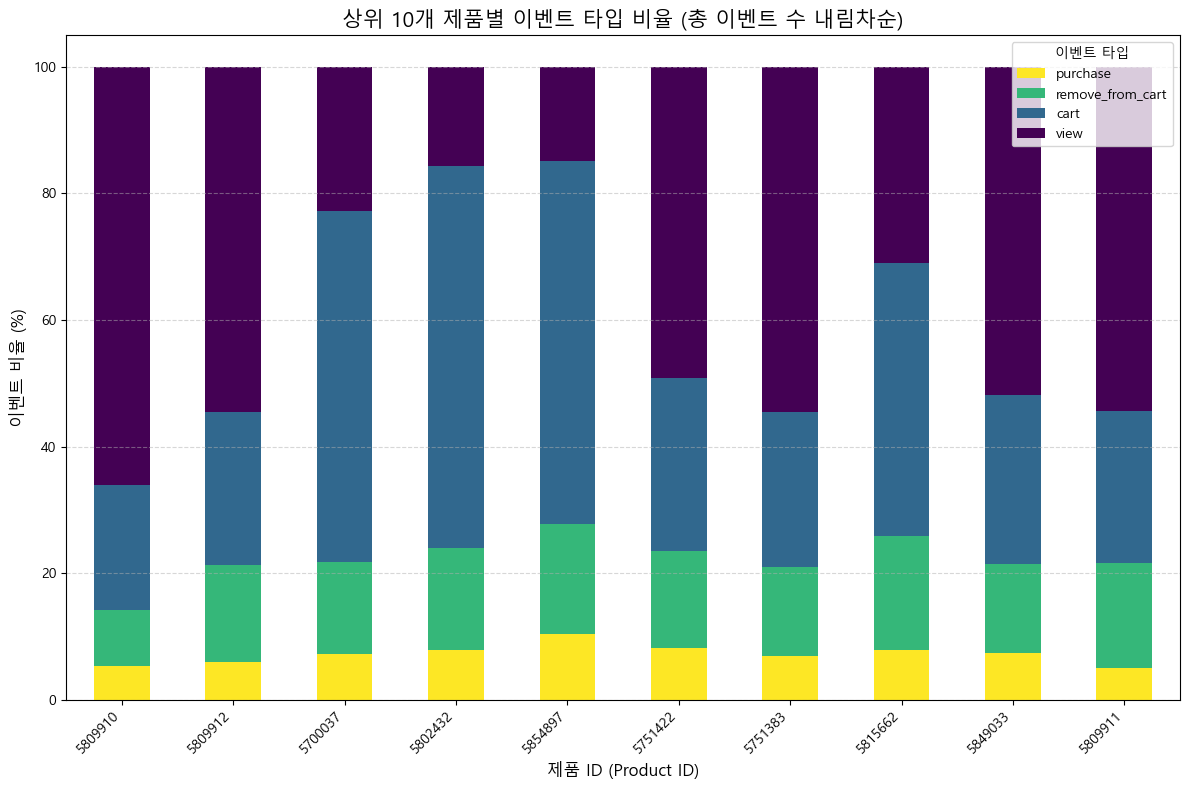

In [51]:
# 경고 메시지 무시 및 한글 폰트 설정 (이전 설정 유지)
warnings.filterwarnings('ignore')
try:
    plt.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False

# 1. 상위 N개 제품 ID 추출 (이미 개수가 큰 순서대로 정렬되어 있음)
top_n = 10
top_product_counts = df_combined['product_id'].value_counts().nlargest(top_n)
top_product_ids = top_product_counts.index # 개수가 큰 순서대로 ID가 저장됨

# 2. 상위 N개 제품 데이터 필터링
df_top_products = df_combined[df_combined['product_id'].isin(top_product_ids)]

# 3. 제품 ID와 event_type별 개수 계산 및 피벗 테이블 생성
event_pivot = df_top_products.groupby(['product_id', 'event_type']).size().unstack(fill_value=0)

# 4. 각 제품별로 이벤트 타입의 비율 계산 (Total 100% 기준)
event_proportion = event_pivot.div(event_pivot.sum(axis=1), axis=0) * 100

# 5. 제품 ID 순서 정렬 (가장 중요한 수정 부분)
# event_proportion의 인덱스(Product ID)를 총 개수가 큰 순서대로 재정렬합니다.
event_proportion = event_proportion.reindex(top_product_ids)

# 6. 시각화 (Stacked Bar Chart)
plt.figure(figsize=(12, 8))

# 막대 누적 순서 조정
order = ['purchase', 'remove_from_cart', 'cart', 'view'] 

# 비율 데이터 (event_proportion)를 사용하여 누적 막대 그래프 생성
# 'purchase'를 가장 위에 두어 눈에 잘 띄게 합니다.
event_proportion[order].plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 8), 
    colormap='viridis_r', 
    ax=plt.gca() 
)

# 7. 그래프 설정
plt.title(f'상위 {top_n}개 제품별 이벤트 타입 비율 (총 이벤트 수 내림차순)', fontsize=15)
plt.xlabel('제품 ID (Product ID)', fontsize=12)
plt.ylabel('이벤트 비율 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='이벤트 타입', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


==================== [상위 10개 제품별 이벤트 비율 (%)] ====================
event_type   view   cart  remove_from_cart  purchase
product_id                                          
5809910     66.02  19.84              8.81      5.33
5809912     54.61  24.08             15.37      5.95
5700037     22.84  55.46             14.49      7.21
5802432     15.62  60.37             16.16      7.85
5854897     14.81  57.39             17.46     10.34
5751422     49.15  27.41             15.30      8.14
5751383     54.57  24.54             14.06      6.84
5815662     30.94  43.25             17.95      7.86
5849033     51.91  26.62             14.07      7.39
5809911     54.38  24.05             16.52      5.05


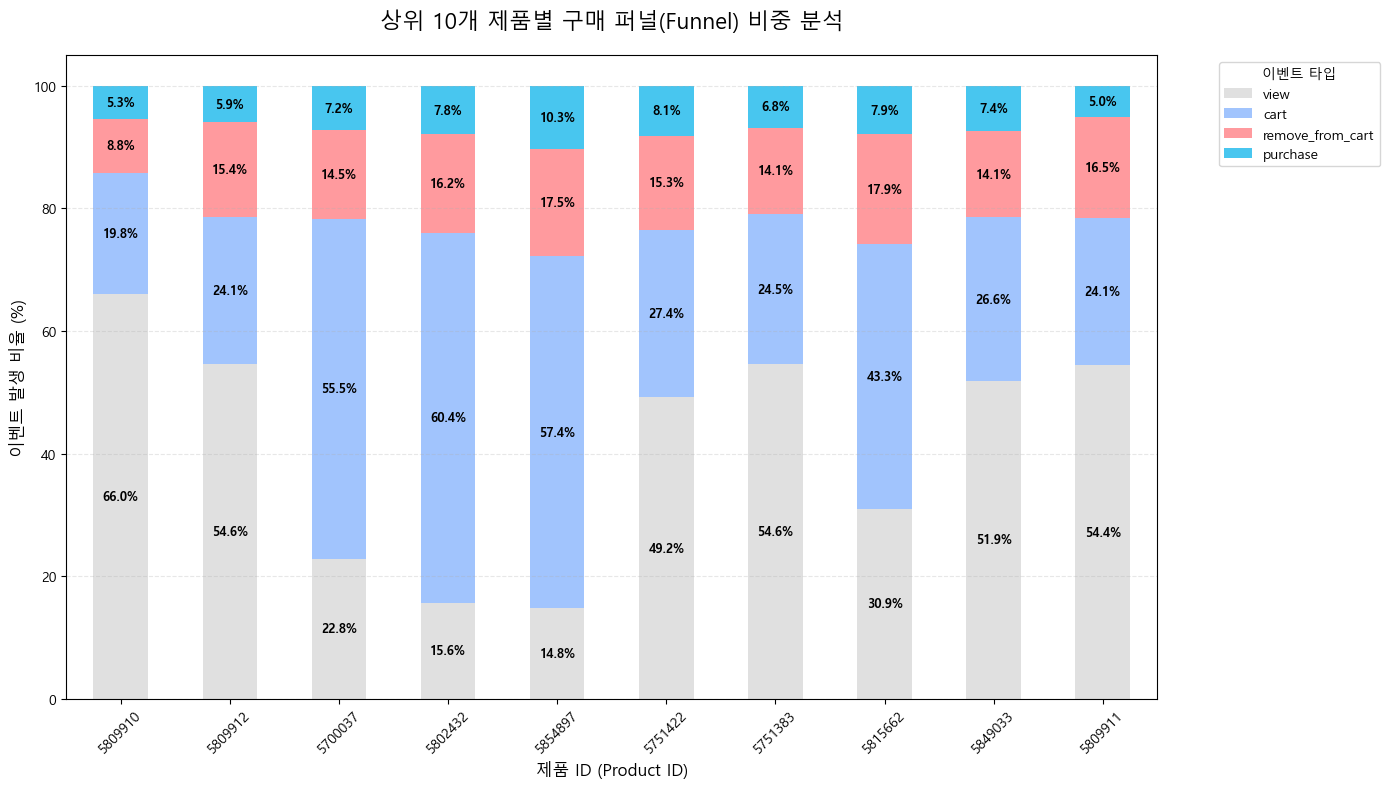

In [9]:
# 1. 환경 설정 및 한글 폰트 처리
warnings.filterwarnings('ignore')
try:
    plt.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False

# 2. 상위 10개 제품 ID 추출 (전체 이벤트 발생 빈도 기준)
top_n = 10
top_product_counts = df_combined['product_id'].value_counts().nlargest(top_n)
top_product_ids = top_product_counts.index

# 3. 데이터 필터링 및 피벗 테이블 생성
df_top_products = df_combined[df_combined['product_id'].isin(top_product_ids)]
event_pivot = df_top_products.groupby(['product_id', 'event_type']).size().unstack(fill_value=0)

# 4. 제품별 이벤트 비율(%) 계산
# 행(axis=1)의 합계로 나누어 각 행의 합이 100%가 되도록 정규화
event_proportion = event_pivot.div(event_pivot.sum(axis=1), axis=0) * 100

# 5. 제품 ID 순서 정렬 (전체 트래픽 순서 유지)
event_proportion = event_proportion.reindex(top_product_ids)

# 📌 6. 수치 결과값 확인을 위한 데이터프레임 출력
print(f"\n" + "="*20 + f" [상위 {top_n}개 제품별 이벤트 비율 (%)] " + "="*20)
# 가독성을 위해 소수점 2자리까지 출력
print(event_proportion[['view', 'cart', 'remove_from_cart', 'purchase']].round(2))
print("="*70)

# 7. 시각화 (Stacked Bar Chart)
plt.figure(figsize=(14, 8))

# 사용자 의도에 맞춘 누적 순서 (구매를 가장 눈에 띄는 곳에 배치 가능)
# 아래 order는 그래프 아래서부터 쌓이는 순서입니다.
order = ['view', 'cart', 'remove_from_cart', 'purchase'] 
colors = ['#e0e0e0', '#a1c4fd', '#ff9a9e', '#48c6ef'] # 부드러운 파스텔톤 컬러 설정

event_proportion[order].plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8), 
    color=colors,
    ax=plt.gca()
)

# 8. 그래프 디테일 설정
plt.title(f'상위 {top_n}개 제품별 구매 퍼널(Funnel) 비중 분석', fontsize=16, pad=20)
plt.xlabel('제품 ID (Product ID)', fontsize=12)
plt.ylabel('이벤트 발생 비율 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='이벤트 타입', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 막대 위에 수치 표시 (선택 사항: 비율이 큰 경우만 표시)
for i, (idx, row) in enumerate(event_proportion[order].iterrows()):
    cumulative = 0
    for col in order:
        value = row[col]
        if value > 5:  # 5% 이상인 경우만 텍스트 표시
            plt.text(i, cumulative + value/2, f'{value:.1f}%', 
                     va='center', ha='center', fontsize=9, color='black', fontweight='bold')
        cumulative += value

plt.tight_layout()
plt.show()

- 연도별 total price(매출) 기준 상위-하위(10%) 10개 product_id -> 가격 음수값 재처리 후 다시 결과 확인해보기

In [52]:
# 1. 연도별, 상품 ID별 총 매출(Total Price) 계산
# sum() 대신 mean()이나 median()을 사용하면 평균 가격 기준으로 분석할 수 있습니다.
yearly_product_sales = df_combined.groupby(['year', 'product_id'])['price'].sum().reset_index()
yearly_product_sales.rename(columns={'price': 'total_sales'}, inplace=True)


# 2. 연도별 상위 10% 및 하위 10% 기준 계산
results = {}

for year in yearly_product_sales['year'].unique():
    # 해당 연도의 데이터만 필터링
    df_year = yearly_product_sales[yearly_product_sales['year'] == year].copy()
    
    # 총 매출액(total_sales) 기준 상위 90% (즉, 상위 10% 컷오프 지점) 계산
    # .quantile(0.9)는 데이터의 90% 지점 값을 의미합니다.
    upper_threshold = df_year['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (즉, 하위 10% 컷오프 지점) 계산
    lower_threshold = df_year['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 상품 필터링
    
    # 상위 10% 상품 (매출액이 상위 90% 기준점보다 큰 상품)
    top_10_percent = df_year[df_year['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 상품 (매출액이 하위 10% 기준점보다 작은 상품)
    bottom_10_percent = df_year[df_year['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[year] = {
        'Upper_10_Percent': top_10_percent[['product_id', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['product_id', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for year, data in results.items():
    print(f"============================ 📅 연도: {year} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Product_ID (매출액 기준) ---")
    print(data['Upper_10_Percent'])

    print("\n--- 하위 10% Product_ID (매출액 기준) ---")
    print(data['Lower_10_Percent'])
    print("\n" + "=" * 60)

============================ 📅 연도: 2019 ============================
💰 상위 10% 기준 매출액: >= 2825.16
📉 하위 10% 기준 매출액: <= 15.20

--- 상위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
39513     5877456   1880772.98
2823      5560754   1778407.72
2237        89343   1772476.68
31326     5850281   1286200.71
2824      5560756   1182331.08
...           ...          ...
41539     5884242      2829.56
29495     5844363      2828.82
14169     5764989      2827.69
31893     5851606      2825.21
23089     5819225      2825.16

[4935 rows x 2 columns]

--- 하위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
10356     5716859      -619.06
10357     5716861      -317.48
10355     5716857      -309.53
6022      5670257      -285.66
10354     5716855       -55.58
...           ...          ...
32688     5853718        15.20
8204      5694754        15.20
3790      5602864        15.20
3791      5602865        15.20
45082     5900585        15.20

[4935 rows x 2 columns]

==========

- Price < 0 인 값을 0으로 처리

In [92]:
# 0. 데이터 복사 (원본 데이터프레임 보존)
# df_combined는 전체 이벤트 데이터프레임이라고 가정
df_temp = df_combined.copy()

# 📌 핵심 수정 로직: Price < 0 인 값을 0으로 처리 (취소 건 무시)
# 이커머스에서 환불/취소 건을 상품/브랜드별 '매출' 집계 시 0원으로 처리하는 것은 일반적인 방법입니다.
df_temp.loc[df_temp['price'] < 0, 'price'] = 0


# 1. 'purchase' 이벤트만 필터링한 후, 연도별, 상품 ID별 총 매출(Total Price) 계산
# sum() 대신 mean()이나 median()을 사용하면 평균 가격 기준으로 분석할 수 있습니다.
yearly_product_sales = df_temp[df_temp['event_type'] == 'purchase'].groupby(['year', 'product_id'])['price'].sum().reset_index()
yearly_product_sales.rename(columns={'price': 'total_sales'}, inplace=True)


# 2. 연도별 상위 10% 및 하위 10% 기준 계산
results = {}

for year in yearly_product_sales['year'].unique():
    # 해당 연도의 데이터만 필터링
    df_year = yearly_product_sales[yearly_product_sales['year'] == year].copy()
    
    # 3. 상위/하위 10% 기준 계산 (음수 값이 제거되어 0 이하의 값은 나타나지 않습니다)
    upper_threshold = df_year['total_sales'].quantile(0.9)
    lower_threshold = df_year['total_sales'].quantile(0.1)

    
    # 4. 상위/하위 10% 상품 필터링
    
    # 상위 10% 상품 (매출액이 상위 90% 기준점보다 큰 상품)
    top_10_percent = df_year[df_year['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 상품 (매출액이 하위 10% 기준점보다 작은 상품)
    # 이제 하위 10%는 0 이상의 가장 낮은 매출을 기록한 상품들이 됩니다.
    bottom_10_percent = df_year[df_year['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[year] = {
        'Upper_10_Percent': top_10_percent[['product_id', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['product_id', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 5. 결과 출력
for year, data in results.items():
    print(f"============================ 📅 연도: {year} (PURCHASE ONLY) ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Product_ID (매출액 기준) ---")
    print(data['Upper_10_Percent'])

    print("\n--- 하위 10% Product_ID (매출액 기준) ---")
    print(data['Lower_10_Percent'])
    print("\n" + "=" * 60)

============================ 📅 연도: 2019 (PURCHASE ONLY) ============================
💰 상위 10% 기준 매출액: >= 195.19
📉 하위 10% 기준 매출액: <= 5.08

--- 상위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
1468      5560754     41782.96
29064     5877454     23200.31
7927      5751422     22954.56
13944     5809910     21234.03
7889      5751383     18398.91
...           ...          ...
4244      5689316       195.32
6067      5723225       195.28
31392     5888068       195.28
492          8122       195.21
16912     5823668       195.20

[3628 rows x 2 columns]

--- 하위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
3279      5670257         0.00
6043      5716855         0.00
6044      5716857         0.00
6045      5716859         0.00
6046      5716861         0.00
...           ...          ...
16556     5822586         5.08
36005     5914137         5.08
4989      5698782         5.08
29129     5877604         5.08
19551     5837491         5.08

[3658 rows x 2 column

- sum & 3,2개월 기준

In [13]:
# 0. 데이터 복사 및 전처리
df_temp = df_combined.copy()

# 📌 핵심 수정 1: 가격 이상치 처리 (순매출 집계용)
df_temp.loc[df_temp['price'] < 0, 'price'] = 0

# 1. 'purchase' 이벤트 필터링 및 상품별 연도별 매출 합계 계산
# 브랜드 분석과 동일하게 'sum'을 사용하여 규모를 먼저 파악합니다.
yearly_product_sales = df_temp[df_temp['event_type'] == 'purchase'].groupby(['year', 'product_id'])['price'].sum().reset_index()
yearly_product_sales.rename(columns={'price': 'total_sales_sum'}, inplace=True)

# 2. 📌 핵심 수정 2: 연도별 월 수 정규화 (Normalization)
# 19년(3개월), 20년(2개월) 수집 기간 차이를 극복하기 위해 월평균으로 변환합니다.
month_counts = df_temp.groupby('year')['event_time'].apply(lambda x: x.dt.month.nunique()).to_dict()

yearly_product_sales['avg_monthly_sales'] = yearly_product_sales.apply(
    lambda row: row['total_sales_sum'] / month_counts[row['year']], axis=1
)

# 3. 연도별 상위 10% 및 하위 10% 분석
results = {}

for year in sorted(yearly_product_sales['year'].unique()):
    # 해당 연도 데이터 필터링
    df_year = yearly_product_sales[yearly_product_sales['year'] == year].copy()
    
    # 📌 핵심 수정 3: 기준점을 'avg_monthly_sales'(월평균)로 설정
    upper_threshold = df_year['avg_monthly_sales'].quantile(0.9)
    lower_threshold = df_year['avg_monthly_sales'].quantile(0.1)

    # 상위 10% 상품 (히트 상품군)
    top_10_percent = df_year[df_year['avg_monthly_sales'] >= upper_threshold].sort_values(
        'avg_monthly_sales', ascending=False
    )
    
    # 하위 10% 상품 (저성과 상품군)
    bottom_10_percent = df_year[df_year['avg_monthly_sales'] <= lower_threshold].sort_values(
        'avg_monthly_sales', ascending=True
    )
    
    results[year] = {
        'Upper_10_Percent': top_10_percent[['product_id', 'avg_monthly_sales', 'total_sales_sum']],
        'Lower_10_Percent': bottom_10_percent[['product_id', 'avg_monthly_sales', 'total_sales_sum']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold,
        'Months_Count': month_counts[year]
    }

# 4. 결과 출력
for year, data in results.items():
    print(f"\n" + "=" * 25 + f" 📅 연도: {year} ({data['Months_Count']}개월 기준) " + "=" * 25)
    print(f"💰 월평균 상위 10% 상품 기준액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 월평균 하위 10% 상품 기준액: <= {data['Lower_Threshold']:.2f}")
    
    print(f"\n--- 🏆 {year}년 월평균 매출 Top 10 상품 ---")
    # 상품 ID는 데이터가 많으므로 상위 10개만 출력
    print(data['Upper_10_Percent'].head(10).to_string(index=False, float_format='{:.2f}'.format))

    print(f"\n--- 📉 {year}년 월평균 매출 Bottom 10 상품 ---")
    print(data['Lower_10_Percent'].head(10).to_string(index=False, float_format='{:.2f}'.format))
    print("\n" + "=" * 80)


========================= 📅 연도: 2019 (3개월 기준) =========================
💰 월평균 상위 10% 상품 기준액: >= 65.06
📉 월평균 하위 10% 상품 기준액: <= 1.69

--- 🏆 2019년 월평균 매출 Top 10 상품 ---
 product_id  avg_monthly_sales  total_sales_sum
    5560754           13927.65         41782.96
    5877454            7733.44         23200.31
    5751422            7651.52         22954.56
    5809910            7078.01         21234.03
    5751383            6132.97         18398.91
    5850281            6087.07         18261.22
    5792800            5783.83         17351.48
    5856186            5462.18         16386.53
    5849033            5388.98         16166.94
    5846437            5380.26         16140.79

--- 📉 2019년 월평균 매출 Bottom 10 상품 ---
 product_id  avg_monthly_sales  total_sales_sum
    5670257               0.00             0.00
    5716855               0.00             0.00
    5716857               0.00             0.00
    5716859               0.00             0.00
    5716861               0.0

- 월별 total price(매출) 기준 상위-하위(10%) 10개 product_id

In [54]:
# 1. 월별, 상품 ID별 총 매출(Total Price) 계산
# sum() 함수를 사용하여 총 매출액을 계산합니다.
monthly_product_sales = df_combined.groupby(['month', 'product_id'])['price'].sum().reset_index()
monthly_product_sales.rename(columns={'price': 'total_sales'}, inplace=True)


# 2. 월별 상위 10% 및 하위 10% 기준 계산
results = {}

# 월별로 반복하며 분석을 수행합니다.
for month in monthly_product_sales['month'].unique():
    # 해당 월의 데이터만 필터링
    df_month = monthly_product_sales[monthly_product_sales['month'] == month].copy()
    
    # 총 매출액(total_sales) 기준 상위 90% (즉, 상위 10% 컷오프 지점) 계산
    # .quantile(0.9)는 데이터의 90% 지점 값을 의미합니다.
    upper_threshold = df_month['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (즉, 하위 10% 컷오프 지점) 계산
    # .quantile(0.1)는 데이터의 10% 지점 값을 의미합니다.
    lower_threshold = df_month['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 상품 필터링
    
    # 상위 10% 상품 (매출액이 상위 90% 기준점보다 크거나 같은 상품)
    top_10_percent = df_month[df_month['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 상품 (매출액이 하위 10% 기준점보다 작거나 같은 상품)
    bottom_10_percent = df_month[df_month['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[month] = {
        'Upper_10_Percent': top_10_percent[['product_id', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['product_id', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for month, data in results.items():
    print(f"============================ 📅 월: {month} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Product_ID (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Upper_10_Percent'].head(10))

    print("\n--- 하위 10% Product_ID (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Lower_10_Percent'].head(10))
    print("\n" + "=" * 60)

============================ 📅 월: 1 ============================
💰 상위 10% 기준 매출액: >= 1113.94
📉 하위 10% 기준 매출액: <= 8.90

--- 상위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
2298      5560754    775621.16
1851        89343    598720.57
34896     5877456    582256.08
27346     5850281    411548.86
2299      5560756    397581.28
29110     5856186    348649.60
34894     5877454    292269.71
2300      5560758    269899.30
16637     5804820    230521.20
44355     5917178    205993.65

--- 하위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
8232      5716859      -428.58
8233      5716861      -396.85
8231      5716857      -309.53
4704      5670257      -158.70
8230      5716855       -15.88
45483     5924514         0.00
44791     5921265         0.00
44789     5921177         0.00
44788     5921175         0.00
44780     5921167         0.00

============================ 📅 월: 2 ============================
💰 상위 10% 기준 매출액: >= 1032.09
📉 하위 10% 기준 매출액: <= 7.56

--- 상위 1

- Price < 0 인 값을 0으로 처리

In [10]:
# 1. 'purchase' 이벤트만 필터링한 후, 월별, 상품 ID별 총 매출(Total Price) 계산
# df_combined는 전체 이벤트 데이터프레임이라고 가정
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()

# 📌 핵심 수정 로직: Price < 0 인 값을 0으로 처리 (취소/환불 건을 매출 집계에서 제외)
# 이 로직을 통해 'total_sales'는 순매출액을 의미하게 됩니다.
df_purchase.loc[df_purchase['price'] < 0, 'price'] = 0

# sum() 함수를 사용하여 총 매출액을 계산합니다.
# 그룹핑 기준을 'month'와 'product_id'로 변경
monthly_product_sales = df_purchase.groupby(['month', 'product_id'])['price'].sum().reset_index()
monthly_product_sales.rename(columns={'price': 'total_sales'}, inplace=True)


# 2. 월별 상위 10% 및 하위 10% 기준 계산
results = {}

# 월별로 반복하며 분석을 수행합니다.
for month in monthly_product_sales['month'].unique():
    # 해당 월의 데이터만 필터링
    df_month = monthly_product_sales[monthly_product_sales['month'] == month].copy()
    
    # 총 매출액(total_sales) 기준 상위 90% (즉, 상위 10% 컷오프 지점) 계산
    upper_threshold = df_month['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (즉, 하위 10% 컷오프 지점) 계산
    lower_threshold = df_month['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 상품 필터링
    
    # 상위 10% 상품 (매출액이 상위 90% 기준점보다 크거나 같은 상품)
    top_10_percent = df_month[df_month['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 상품 (매출액이 하위 10% 기준점보다 작거나 같은 상품)
    # 0원 처리 로직으로 인해 하위 10%는 0 이상의 가장 낮은 매출을 기록한 상품들로 구성됩니다.
    bottom_10_percent = df_month[df_month['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[month] = {
        'Upper_10_Percent': top_10_percent[['product_id', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['product_id', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for month, data in results.items():
    print(f"============================ 📅 월: {month} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Product_ID (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Upper_10_Percent'].head(10))

    print("\n--- 하위 10% Product_ID (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Lower_10_Percent'].head(10))
    print("\n" + "=" * 60)

============================ 📅 월: 1 ============================
💰 상위 10% 기준 매출액: >= 87.60
📉 하위 10% 기준 매출액: <= 3.40

--- 상위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
1203      5560754     16527.40
10769     5809910     10631.96
6425      5751422      8738.10
16702     5849033      6976.32
1204      5560756      6862.02
6395      5751383      6687.36
9013      5792800      6047.52
10771     5809912      4993.72
27021     5917178      4790.55
6435      5751742      4519.60

--- 하위 10% Product_ID (매출액 기준) ---
       product_id  total_sales
2696      5670257         0.00
4872      5716857         0.00
4871      5716855         0.00
4873      5716859         0.00
4874      5716861         0.00
15088     5838788         0.22
3056      5682659         0.22
983         89758         0.32
24502     5900461         0.33
24504     5900464         0.33

============================ 📅 월: 2 ============================
💰 상위 10% 기준 매출액: >= 79.35
📉 하위 10% 기준 매출액: <= 3.09

--- 상위 10% P

In [ ]:
df_combined.head(10)

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second,time_segment,day_period,weekday_name
0,2019-12-01 00:00:00,remove_from_cart,5712790,1487580005268456287,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,2019,12,1,0,0,0,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
1,2019-12-01 00:00:00,view,5764655,1487580005411062629,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,2019,12,1,0,0,0,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
2,2019-12-01 00:00:02,cart,4958,1487580009471148064,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019,12,1,0,0,2,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
3,2019-12-01 00:00:05,view,5848413,1487580007675986893,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4,2019,12,1,0,0,5,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
4,2019-12-01 00:00:07,view,5824148,1487580005511725929,Unknown,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019,12,1,0,0,7,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
5,2019-12-01 00:00:09,view,5773361,1487580005134238553,runail,2.62,560109803,38cf4ba1-4a0a-4c9e-b870-46685d105f95,2019,12,1,0,0,9,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
6,2019-12-01 00:00:18,cart,5629988,1487580009311764506,Unknown,1.19,579966747,1512be50-d0fd-4a92-bcd8-3ea3943f2a3b,2019,12,1,0,0,18,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
7,2019-12-01 00:00:22,view,5807805,1487580005713052531,ingarden,4.44,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019,12,1,0,0,22,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
8,2019-12-01 00:00:27,view,5588608,1487580008145748965,roubloff,5.40,546170008,676d9fcc-2a4f-4448-b49d-136f2e4208c1,2019,12,1,0,0,27,00-05시 (새벽),월초 (1일 ~ 15일),Sunday
9,2019-12-01 00:00:34,cart,5335,1487580009605365797,runail,0.40,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019,12,1,0,0,34,00-05시 (새벽),월초 (1일 ~ 15일),Sunday


- product_id 당 view에서 구매까지 걸리는 평균 시간

In [57]:
# 만약 'user_session' 컬럼이 있다면, # groups = ['user_id', 'product_id'] 로 수정하세요.
# groups=['user_id', 'user_session', 'product_id']
groups=['user_id', 'product_id'] 

# 2. 첫 'view' 및 첫 'purchase' 시간 추출
df_time = df_combined.sort_values('event_time')

# 각 그룹에서 'view' 이벤트 중 가장 빠른 시간
first_view = df_time[df_time['event_type'] == 'view'].groupby(groups)['event_time'].min().reset_index()
first_view.rename(columns={'event_time': 'first_view_time'}, inplace=True)

# 각 그룹에서 'purchase' 이벤트 중 가장 빠른 시간
first_purchase = df_time[df_time['event_type'] == 'purchase'].groupby(groups)['event_time'].min().reset_index()
first_purchase.rename(columns={'event_time': 'first_purchase_time'}, inplace=True)


# 3. 데이터프레임 병합 (merge)
# view 이후 purchase가 발생한 경우만 남깁니다.
df_merged = pd.merge(first_view, first_purchase, on=groups, how='inner')

# 4. 구매까지 걸린 시간 계산 (TimeDelta)
# purchase가 view보다 늦게 발생한 경우만 필터링합니다 (논리적 오류 방지)
df_merged['time_to_purchase'] = df_merged['first_purchase_time'] - df_merged['first_view_time']
df_merged = df_merged[df_merged['time_to_purchase'].dt.total_seconds() >= 0].copy()


# 5. product_id 당 평균 시간 계산
# timedelta 객체는 mean() 시 평균 시간으로 자동 계산됩니다.
avg_time_by_product = df_merged.groupby('product_id')['time_to_purchase'].mean().reset_index()
avg_time_by_product.rename(columns={'time_to_purchase': 'avg_time_to_purchase'}, inplace=True)

# 시각적 확인을 위해 초(seconds) 단위로 변환
avg_time_by_product['avg_seconds'] = avg_time_by_product['avg_time_to_purchase'].dt.total_seconds()

# 결과 출력
print("--- 🛒 상품 ID별 구매까지 걸린 평균 시간 (상위 10개) ---")
print(avg_time_by_product.sort_values('avg_seconds', ascending=False).head(10))

# 가장 빠르게 구매되는 상품 (결정 시간이 짧은 상품)
print("\n--- 🚀 가장 빠르게 구매되는 상품 (하위 10개) ---")
print(avg_time_by_product.sort_values('avg_seconds', ascending=True).head(10))

--- 🛒 상품 ID별 구매까지 걸린 평균 시간 (상위 10개) ---
       product_id avg_time_to_purchase  avg_seconds
724         29914    134 days 18:39:49   11644789.0
9716      5780926    123 days 23:25:53   10711553.0
24468     5864857    122 days 20:17:03   10613823.0
16844     5830308    122 days 17:06:40   10602400.0
24000     5863088    117 days 00:17:51   10109871.0
12625     5808311    116 days 23:08:38   10105718.0
18551     5839087    114 days 03:38:41    9862721.0
23598     5861810    111 days 22:19:03    9670743.0
8194      5761798    108 days 23:42:35    9416555.0
4998      5701841    105 days 03:41:20    9085280.0

--- 🚀 가장 빠르게 구매되는 상품 (하위 10개) ---
       product_id avg_time_to_purchase  avg_seconds
14094     5814694      0 days 00:00:00          0.0
17317     5833664      0 days 00:00:30         30.0
34201     5921619      0 days 00:00:33         33.0
13651     5812623      0 days 00:00:35         35.0
26950     5877707      0 days 00:00:37         37.0
34047     5919970      0 days 00:00:39   

- 상위 10개 -> Hour, 하위 10개 -> Seconds 수정

In [ ]:
# 1. 분(Minute) 단위 컬럼 추가
# # 1분 = 60초
# avg_time_by_product['avg_minutes'] = avg_time_by_product['avg_seconds'] / 60

# 2. 시간(Hour) 단위 컬럼 추가
# 1시간 = 3600초 (60분 * 60초)
avg_time_by_product['avg_hours'] = avg_time_by_product['avg_seconds'] / 3600

# 3. 상품 ID별 구매까지 걸린 평균 시간 (시간 단위 출력)
print("--- 🛒 상품 ID별 구매까지 걸린 평균 시간 (상위 10개) - 시간(Hour) 단위 ---")

# 'avg_hours' 기준으로 내림차순 정렬
# 출력 컬럼을 'avg_time_to_purchase'와 'avg_hours'로 제한하여 깔끔하게 표시
top_10_hours = avg_time_by_product.sort_values('avg_hours', ascending=False).head(10)

# avg_hours를 소수점 2자리로 포맷팅하여 출력
print(top_10_hours[['product_id', 'avg_time_to_purchase', 'avg_hours']].to_string(float_format='%.2f'))
print("-" * 70)


# 4. 가장 빠르게 구매되는 상품 (분 단위 출력)
print("\n--- 🚀 가장 빠르게 구매되는 상품 (하위 10개) - 초(Seconds) 단위 ---")

# 'avg_minutes' 기준으로 오름차순 정렬
bottom_10_minutes = avg_time_by_product.sort_values('avg_seconds', ascending=True).head(10)

# avg_minutes를 소수점 2자리로 포맷팅하여 출력
print(bottom_10_minutes[['product_id', 'avg_time_to_purchase', 'avg_seconds']].to_string(float_format='%.2f'))
print("-" * 70)

--- 🛒 상품 ID별 구매까지 걸린 평균 시간 (상위 10개) - 시간(Hour) 단위 ---
       product_id avg_time_to_purchase  avg_hours
724         29914    134 days 18:39:49    3234.66
9716      5780926    123 days 23:25:53    2975.43
24468     5864857    122 days 20:17:03    2948.28
16844     5830308    122 days 17:06:40    2945.11
24000     5863088    117 days 00:17:51    2808.30
12625     5808311    116 days 23:08:38    2807.14
18551     5839087    114 days 03:38:41    2739.64
23598     5861810    111 days 22:19:03    2686.32
8194      5761798    108 days 23:42:35    2615.71
4998      5701841    105 days 03:41:20    2523.69
--------------------------------------------------

--- 🚀 가장 빠르게 구매되는 상품 (하위 10개) - 초(Seconds) 단위 ---
       product_id avg_time_to_purchase  avg_seconds
14094     5814694      0 days 00:00:00         0.00
17317     5833664      0 days 00:00:30        30.00
34201     5921619      0 days 00:00:33        33.00
13651     5812623      0 days 00:00:35        35.00
26950     5877707      0 days 00:0

- product_id 당 cart에서 구매까지 걸리는 평균 시간

In [59]:
# 그룹화 기준 (사용자-세션-상품)
groups=['user_id', 'user_session', 'product_id'] 

# 2. 첫 'cart' 및 첫 'purchase' 시간 추출
df_time = df_combined.sort_values('event_time')

# 각 그룹에서 'cart' 이벤트 중 가장 빠른 시간 (★ 수정된 부분)
first_cart = df_time[df_time['event_type'] == 'cart'].groupby(groups)['event_time'].min().reset_index()
first_cart.rename(columns={'event_time': 'first_cart_time'}, inplace=True)

# 각 그룹에서 'purchase' 이벤트 중 가장 빠른 시간 (이전과 동일)
first_purchase = df_time[df_time['event_type'] == 'purchase'].groupby(groups)['event_time'].min().reset_index()
first_purchase.rename(columns={'event_time': 'first_purchase_time'}, inplace=True)


# 3. 데이터프레임 병합 (merge)
# cart 이후 purchase가 발생한 경우만 남깁니다. (★ 'first_view' 대신 'first_cart' 사용)
df_merged = pd.merge(first_cart, first_purchase, on=groups, how='inner')

# 4. 구매까지 걸린 시간 계산 (TimeDelta)
# purchase가 cart보다 늦게 발생한 경우만 필터링 (논리적 오류 방지)
df_merged['time_to_purchase'] = df_merged['first_purchase_time'] - df_merged['first_cart_time'] # ★ 시간 계산 기준 변경
df_merged = df_merged[df_merged['time_to_purchase'].dt.total_seconds() >= 0].copy()


# 5. product_id 당 평균 시간 계산
avg_time_by_product = df_merged.groupby('product_id')['time_to_purchase'].mean().reset_index()
avg_time_by_product.rename(columns={'time_to_purchase': 'avg_time_to_purchase'}, inplace=True)

# 시각적 확인을 위해 초(seconds) 단위로 변환
avg_time_by_product['avg_seconds'] = avg_time_by_product['avg_time_to_purchase'].dt.total_seconds()

# 결과 출력 (상위 10개: Hour 단위, 하위 10개: Second 단위)
# Hour 단위 추가
avg_time_by_product['avg_hours'] = avg_time_by_product['avg_seconds'] / 3600


print("--- 🛒 상품 ID별 (Cart → Purchase) 평균 시간 (상위 10개) - 시간(Hour) 단위 ---")

# 'avg_hours' 기준으로 내림차순 정렬
top_10_hours = avg_time_by_product.sort_values('avg_hours', ascending=False).head(10)
print(top_10_hours[['product_id', 'avg_time_to_purchase', 'avg_hours']].to_string(float_format='%.2f'))
print("-" * 50)


print("\n--- 🚀 가장 빠르게 구매되는 상품 (하위 10개) - 초(Second) 단위 ---")

# 'avg_seconds' 기준으로 오름차순 정렬
bottom_10_seconds = avg_time_by_product.sort_values('avg_seconds', ascending=True).head(10)
print(bottom_10_seconds[['product_id', 'avg_time_to_purchase', 'avg_seconds']].to_string(float_format='%.0f'))
print("-" * 50)

--- 🛒 상품 ID별 (Cart → Purchase) 평균 시간 (상위 10개) - 시간(Hour) 단위 ---
       product_id avg_time_to_purchase  avg_hours
11528     5796776    142 days 05:59:11    3413.99
7844      5751430    142 days 05:53:30    3413.89
23450     5856294    142 days 05:01:56    3413.03
8386      5759134    112 days 18:57:55    2706.97
22584     5852407    111 days 19:47:35    2683.79
6839      5735046    110 days 18:01:54    2658.03
28363     5877343    106 days 04:05:43    2548.10
27408     5870990     97 days 05:26:01    2333.43
31174     5890850     82 days 20:00:36    1988.01
33432     5903818     71 days 23:47:51    1727.80
--------------------------------------------------

--- 🚀 가장 빠르게 구매되는 상품 (하위 10개) - 초(Second) 단위 ---
       product_id avg_time_to_purchase  avg_seconds
36305     5921706      0 days 00:00:00            0
11137     5787923      0 days 00:00:00            0
9559      5773162      0 days 00:00:00            0
4142      5688131      0 days 00:00:00            0
17503     5828847      0 

- product_id 당 remove_from_cart에서 구매까지 걸리는 평균 시간

In [60]:
# 그룹화 기준 (사용자-세션-상품)
groups=['user_id', 'user_session', 'product_id'] 

# 2. 첫 'remove_from_cart' 및 첫 'purchase' 시간 추출
df_time = df_combined.sort_values('event_time')

# 각 그룹에서 'remove_from_cart' 이벤트 중 가장 빠른 시간 (★ 수정된 부분)
first_remove_from_cart = df_time[df_time['event_type'] == 'remove_from_cart'].groupby(groups)['event_time'].min().reset_index()
first_remove_from_cart.rename(columns={'event_time': 'first_remove_time'}, inplace=True) # 컬럼명 변경

# 각 그룹에서 'purchase' 이벤트 중 가장 빠른 시간
first_purchase = df_time[df_time['event_type'] == 'purchase'].groupby(groups)['event_time'].min().reset_index()
first_purchase.rename(columns={'event_time': 'first_purchase_time'}, inplace=True)


# 3. 데이터프레임 병합 (merge)
# remove_from_cart 이후 purchase가 발생한 경우만 남깁니다.
df_merged = pd.merge(first_remove_from_cart, first_purchase, on=groups, how='inner')

# 4. 구매까지 걸린 시간 계산 (TimeDelta)
# purchase가 remove_from_cart보다 늦게 발생한 경우만 필터링 (논리적 오류 방지)
df_merged['time_to_purchase'] = df_merged['first_purchase_time'] - df_merged['first_remove_time'] # ★ 시간 계산 기준 변경
df_merged = df_merged[df_merged['time_to_purchase'].dt.total_seconds() >= 0].copy()


# 5. product_id 당 평균 시간 계산
avg_time_by_product = df_merged.groupby('product_id')['time_to_purchase'].mean().reset_index()
avg_time_by_product.rename(columns={'time_to_purchase': 'avg_time_to_purchase'}, inplace=True)

# 시각적 확인을 위해 초(seconds) 단위로 변환
avg_time_by_product['avg_seconds'] = avg_time_by_product['avg_time_to_purchase'].dt.total_seconds()

# 결과 출력 (상위 10개: Hour 단위, 하위 10개: Second 단위)
# Hour 단위 추가
avg_time_by_product['avg_hours'] = avg_time_by_product['avg_seconds'] / 3600


print("--- 🛒 상품 ID별 (Remove from Cart → Purchase) 평균 시간 (상위 10개) - 시간(Hour) 단위 ---")

# 'avg_hours' 기준으로 내림차순 정렬
top_10_hours = avg_time_by_product.sort_values('avg_hours', ascending=False).head(10)
print(top_10_hours[['product_id', 'avg_time_to_purchase', 'avg_hours']].to_string(float_format='%.2f'))
print("-" * 50)


print("\n--- 🚀 가장 빠르게 재구매되는 상품 (하위 10개) - 초(Second) 단위 ---")

# 'avg_seconds' 기준으로 오름차순 정렬
bottom_10_seconds = avg_time_by_product.sort_values('avg_seconds', ascending=True).head(10)
print(bottom_10_seconds[['product_id', 'avg_time_to_purchase', 'avg_seconds']].to_string(float_format='%.0f'))
print("-" * 50)

--- 🛒 상품 ID별 (Remove from Cart → Purchase) 평균 시간 (상위 10개) - 시간(Hour) 단위 ---
       product_id avg_time_to_purchase  avg_hours
3546      5713403    143 days 02:59:52    3435.00
8208      5814736    141 days 12:04:45    3396.08
3449      5711130    133 days 22:51:12    3214.85
10504     5841986    124 days 02:01:43    2978.03
5425      5771933    115 days 03:26:21    2763.44
4742      5755390    115 days 01:18:39    2761.31
16173     5900365    114 days 16:16:18    2752.27
12886     5862569    109 days 23:35:14    2639.59
14278     5877343    106 days 03:23:33    2547.39
14279     5877345    106 days 03:01:11    2547.02
--------------------------------------------------

--- 🚀 가장 빠르게 재구매되는 상품 (하위 10개) - 초(Second) 단위 ---
       product_id avg_time_to_purchase  avg_seconds
4723      5755141      0 days 00:00:14           14
12108     5856609      0 days 00:00:19           19
13361     5866951      0 days 00:00:20           20
12129     5856848      0 days 00:00:22           22
11682     58

- 브랜드별 view에서 구매까지 걸린 시간(상위 10개 -> Hour, 하위 10개 -> Seconds)

In [61]:
# 그룹핑 기준을 'user_id'와 'brand'로 설정
groups = ['user_id', 'brand'] 

# 'Unknown' 브랜드는 분석에서 제외합니다.
df_time = df_combined[df_combined['brand'] != 'Unknown'].sort_values('event_time').copy()

# 2. 첫 'view' 및 첫 'purchase' 시간 추출
# 각 그룹에서 'view' 이벤트 중 가장 빠른 시간
first_view_brand = df_time[df_time['event_type'] == 'view'].groupby(groups)['event_time'].min().reset_index()
first_view_brand.rename(columns={'event_time': 'first_view_time'}, inplace=True)

# 각 그룹에서 'purchase' 이벤트 중 가장 빠른 시간
first_purchase_brand = df_time[df_time['event_type'] == 'purchase'].groupby(groups)['event_time'].min().reset_index()
first_purchase_brand.rename(columns={'event_time': 'first_purchase_time'}, inplace=True)


# 3. 데이터프레임 병합 (merge)
# view 이후 purchase가 발생한 경우만 남깁니다.
df_merged_brand = pd.merge(first_view_brand, first_purchase_brand, on=groups, how='inner')

# 4. 구매까지 걸린 시간 계산 (TimeDelta)
df_merged_brand['time_to_purchase'] = df_merged_brand['first_purchase_time'] - df_merged_brand['first_view_time']
# purchase가 view보다 늦게 발생한 경우만 필터링 (논리적 오류 방지)
df_merged_brand = df_merged_brand[df_merged_brand['time_to_purchase'].dt.total_seconds() >= 0].copy()


# 5. brand 당 평균 시간 계산
avg_time_by_brand = df_merged_brand.groupby('brand')['time_to_purchase'].mean().reset_index()
avg_time_by_brand.rename(columns={'time_to_purchase': 'avg_time_to_purchase'}, inplace=True)

# 시각적 확인을 위해 초(seconds) 단위 컬럼 추가
avg_time_by_brand['avg_seconds'] = avg_time_by_brand['avg_time_to_purchase'].dt.total_seconds()

# 6. 단위 변환 컬럼 추가 (시간 단위)
avg_time_by_brand['avg_hours'] = avg_time_by_brand['avg_seconds'] / 3600


# 7. 결과 출력 (상위 10개는 Hour, 하위 10개는 Second)
print("--- 🛒 브랜드별 구매까지 걸린 평균 시간 (상위 10개) - 시간(Hour) 단위 ---")

# 'avg_hours' 기준으로 내림차순 정렬
top_10_hours_brand = avg_time_by_brand.sort_values('avg_hours', ascending=False).head(10)

# avg_hours를 소수점 2자리로 포맷팅하여 출력
print(top_10_hours_brand[['brand', 'avg_time_to_purchase', 'avg_hours']].to_string(float_format='%.2f'))
print("-" * 50)


print("\n--- 🚀 가장 빠르게 구매되는 브랜드 (하위 10개) - 초(Second) 단위 ---")

# 'avg_seconds' 기준으로 오름차순 정렬
bottom_10_seconds_brand = avg_time_by_brand.sort_values('avg_seconds', ascending=True).head(10)

# avg_seconds를 정수 형태로 출력
print(bottom_10_seconds_brand[['brand', 'avg_time_to_purchase', 'avg_seconds']].to_string(float_format='%.0f'))
print("-" * 50)

--- 🛒 브랜드별 구매까지 걸린 평균 시간 (상위 10개) - 시간(Hour) 단위 ---
          brand       avg_time_to_purchase  avg_hours
88          fly           12 days 13:18:34     301.31
170       moyou 12 days 11:04:00.723076923     299.07
206      s.care 12 days 04:04:56.263157894     292.08
98      grattol 12 days 00:53:51.665910427     288.90
138     ladykin 11 days 15:01:53.794871794     279.03
180        oniq 11 days 06:13:26.782798833     270.22
234         uno 11 days 05:30:12.002706641     269.50
105    ingarden 11 days 04:04:35.788873812     268.08
45   cosmoprofi 10 days 17:24:32.762001627     257.41
109       irisk 10 days 17:07:44.115960032     257.13
--------------------------------------------------

--- 🚀 가장 빠르게 구매되는 브랜드 (하위 10개) - 초(Second) 단위 ---
         brand      avg_time_to_purchase  avg_seconds
227      tazol           0 days 00:04:14          254
32      bosnic           0 days 00:05:25          325
152    lunaris           0 days 00:06:04          364
133  koreatida    0 days 00:11:18.12

# category_id

In [62]:
df_combined['category_id'].head()

0    1487580005268456287
1    1487580005411062629
2    1487580009471148064
3    1487580007675986893
4    1487580005511725929
Name: category_id, dtype: int64

- 카테고리별 price(매출) 기준 상위 10개

In [63]:
# 2. category_id별 총 매출(Total Price) 계산
category_sales = df_combined.groupby('category_id')['price'].sum().reset_index()
category_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 3. 총 매출(total_sales) 기준 내림차순 정렬 후 상위 10개 추출
top_10_categories = category_sales.sort_values(by='total_sales', ascending=False).head(10)

# 4. 결과 출력
print("--- 🥇 Category ID별 총 매출(Total Sales) 기준 상위 10개 ---")
print(top_10_categories)

print("\n--- 📊 매출 기여도 확인 ---")
total_revenue = category_sales['total_sales'].sum()
top_10_revenue = top_10_categories['total_sales'].sum()
contribution_rate = (top_10_revenue / total_revenue) * 100

print(f"전체 총 매출: {total_revenue:,.2f}")
print(f"상위 10개 카테고리 총 매출: {top_10_revenue:,.2f}")
print(f"상위 10개 카테고리의 전체 매출 기여율: {contribution_rate:.2f}%")

--- 🥇 Category ID별 총 매출(Total Sales) 기준 상위 10개 ---
             category_id  total_sales
55   1487580006300255120  32625148.64
334  1487580013950664926   8225616.13
57   1487580006350586771   7141572.21
12   1487580005092295511   6860398.55
156  1487580009051717646   6311482.35
510  2193074740619379535   4960554.80
16   1487580005268456287   3755378.10
130  1487580008246412266   3590654.39
358  1602943681873052386   3298153.71
56   1487580006317032337   2975933.02

--- 📊 매출 기여도 확인 ---
전체 총 매출: 176,607,915.74
상위 10개 카테고리 총 매출: 79,744,891.90
상위 10개 카테고리의 전체 매출 기여율: 45.15%


- event_type = purchase -> 필터링

In [64]:
# 2. category_id별 총 매출(Total Price) 계산
category_sales = df_combined[df_combined['event_type'] == 'purchase'].groupby('category_id')['price'].sum().reset_index()
category_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 3. 총 매출(total_sales) 기준 내림차순 정렬 후 상위 10개 추출
top_10_categories = category_sales.sort_values(by='total_sales', ascending=False).head(10)

# 4. 결과 출력
print("--- 🥇 Category ID별 총 매출(Total Sales) 기준 상위 10개 ---")
print(top_10_categories)

print("\n--- 📊 매출 기여도 확인 ---")
total_revenue = category_sales['total_sales'].sum()
top_10_revenue = top_10_categories['total_sales'].sum()
contribution_rate = (top_10_revenue / total_revenue) * 100

print(f"전체 총 매출: {total_revenue:,.2f}")
print(f"상위 10개 카테고리 총 매출: {top_10_revenue:,.2f}")
print(f"상위 10개 카테고리의 전체 매출 기여율: {contribution_rate:.2f}%")

--- 🥇 Category ID별 총 매출(Total Sales) 기준 상위 10개 ---
             category_id  total_sales
11   1487580005092295511    418363.33
45   1487580006300255120    351672.31
13   1487580005268456287    265312.54
304  1602943681873052386    186388.51
46   1487580006317032337    179969.53
113  1487580008246412266    139934.73
47   1487580006350586771    138623.97
282  1487580013950664926    135893.36
25   1487580005595612013    134047.48
133  1487580009051717646    114698.00

--- 📊 매출 기여도 확인 ---
전체 총 매출: 6,348,004.87
상위 10개 카테고리 총 매출: 2,064,903.76
상위 10개 카테고리의 전체 매출 기여율: 32.53%


- Price < 0 인 값을 0으로 처리

In [96]:
# 1. 'purchase' 이벤트만 필터링
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()

# 📌 핵심 수정 로직: Price < 0 인 값을 0으로 처리 (취소/환불 건을 매출 집계에서 제외)
# 이 로직을 통해 'total_sales'는 순매출액을 의미하게 됩니다.
df_purchase.loc[df_purchase['price'] < 0, 'price'] = 0

# 2. category_id별 총 매출(Total Price) 계산
# 이제 총 매출은 순매출액을 의미합니다.
category_sales = df_purchase.groupby('category_id')['price'].sum().reset_index()
category_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 3. 총 매출(total_sales) 기준 내림차순 정렬 후 상위 10개 추출
top_10_categories = category_sales.sort_values(by='total_sales', ascending=False).head(10)

# 4. 결과 출력
print("--- 🥇 Category ID별 총 매출(Total Sales) 기준 상위 10개 ---")
print(top_10_categories)

print("\n--- 📊 매출 기여도 확인 ---")
total_revenue = category_sales['total_sales'].sum()
top_10_revenue = top_10_categories['total_sales'].sum()
contribution_rate = (top_10_revenue / total_revenue) * 100

print(f"전체 총 매출: {total_revenue:,.2f}")
print(f"상위 10개 카테고리 총 매출: {top_10_revenue:,.2f}")
print(f"상위 10개 카테고리의 전체 매출 기여율: {contribution_rate:.2f}%")

--- 🥇 Category ID별 총 매출(Total Sales) 기준 상위 10개 ---
             category_id  total_sales
11   1487580005092295511    418363.33
45   1487580006300255120    351672.31
13   1487580005268456287    265312.54
304  1602943681873052386    186388.51
46   1487580006317032337    179969.53
113  1487580008246412266    139934.73
47   1487580006350586771    138623.97
282  1487580013950664926    135893.36
25   1487580005595612013    134047.48
133  1487580009051717646    114698.00

--- 📊 매출 기여도 확인 ---
전체 총 매출: 6,351,830.29
상위 10개 카테고리 총 매출: 2,064,903.76
상위 10개 카테고리의 전체 매출 기여율: 32.51%


- 카테고리별 event_type 기준 event_time(시간) 분포

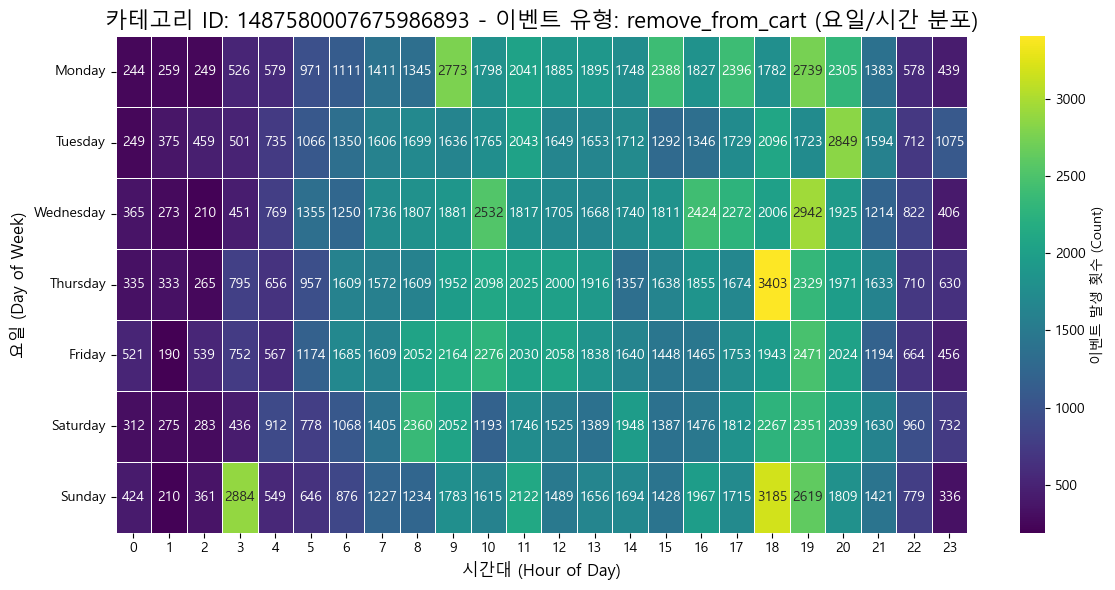

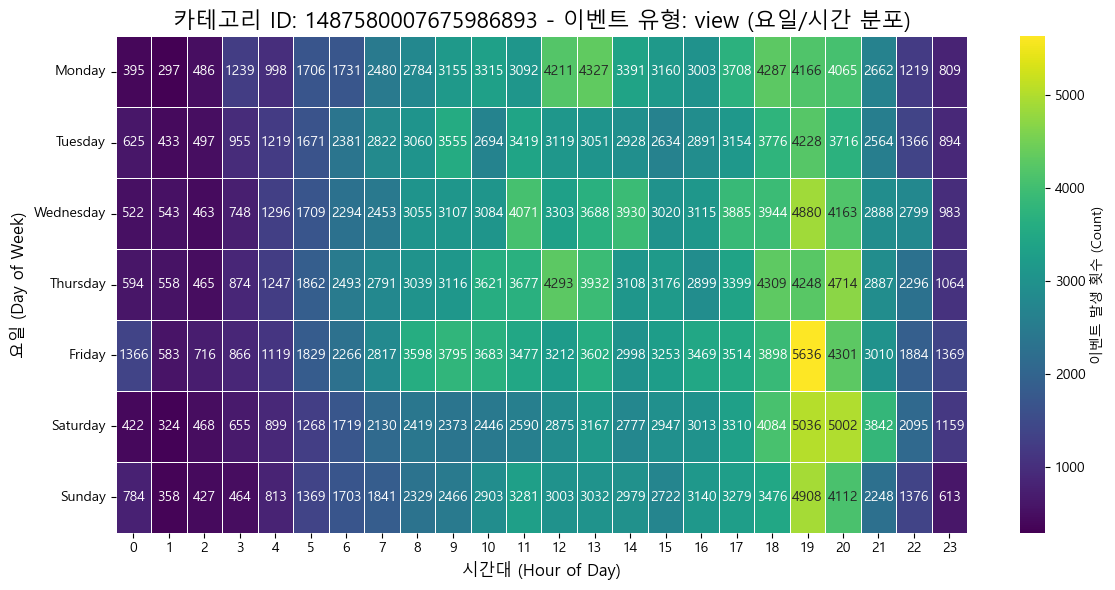

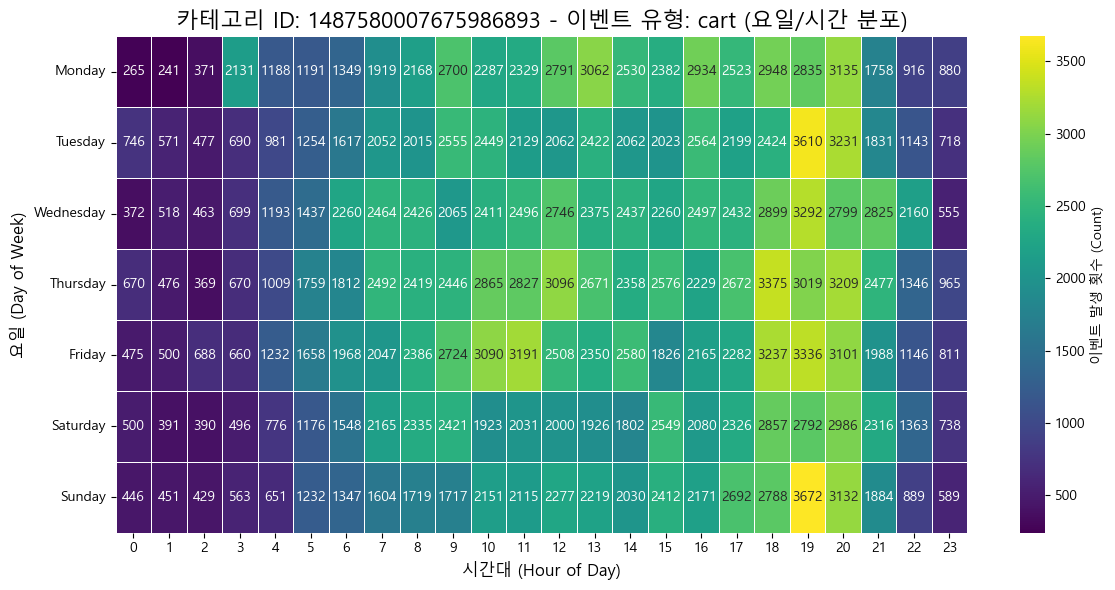

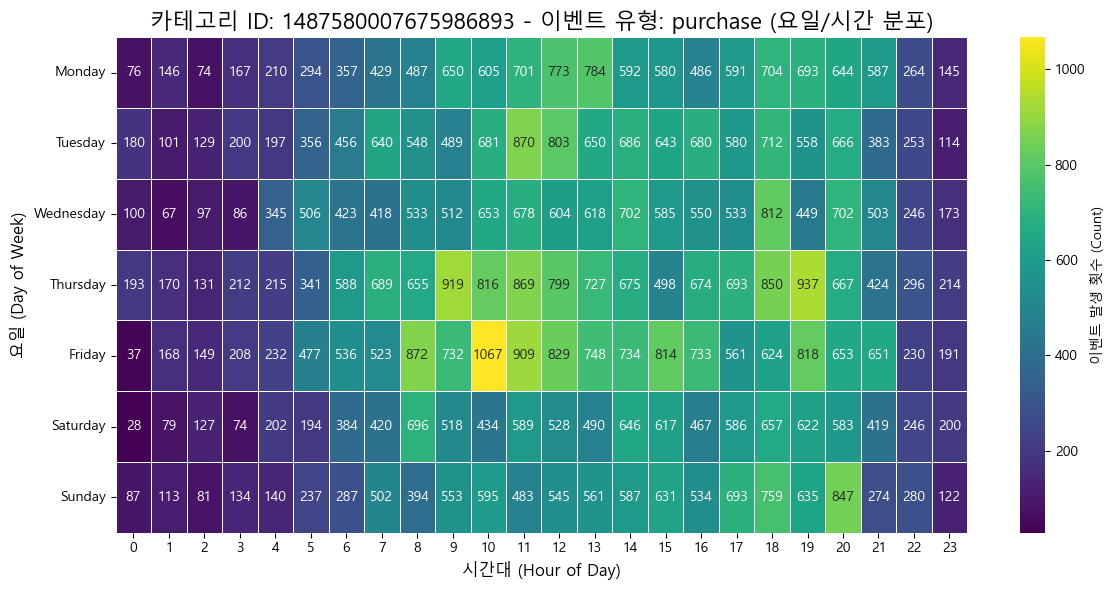

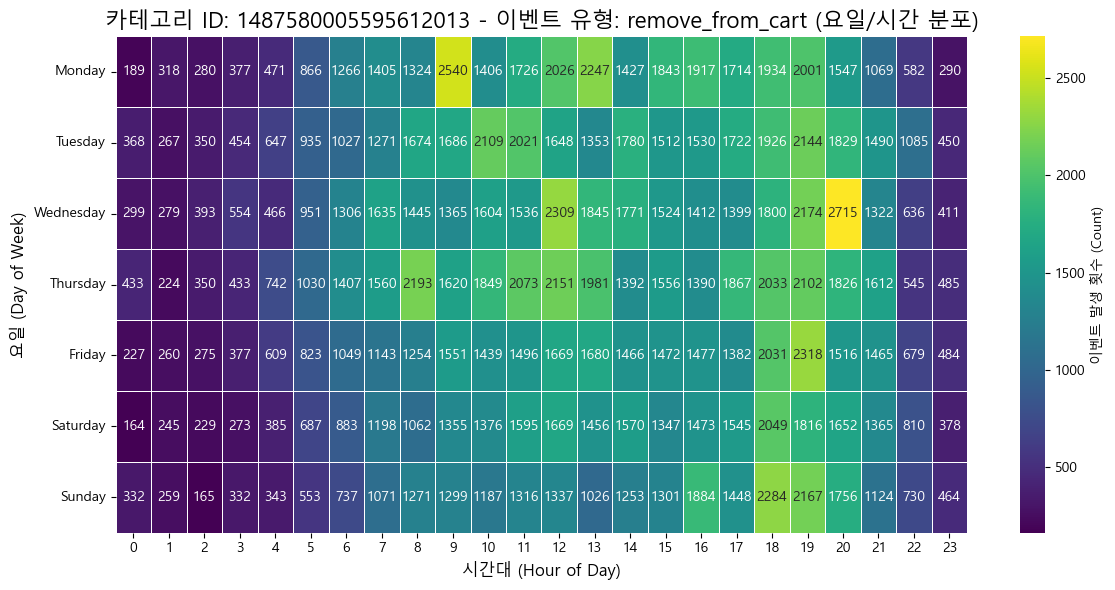

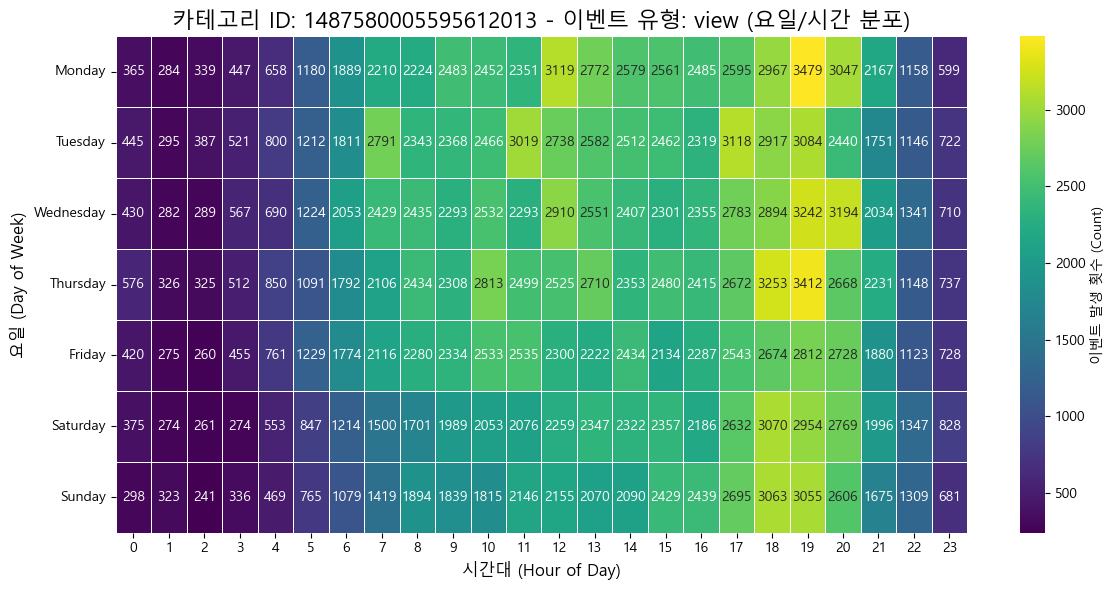

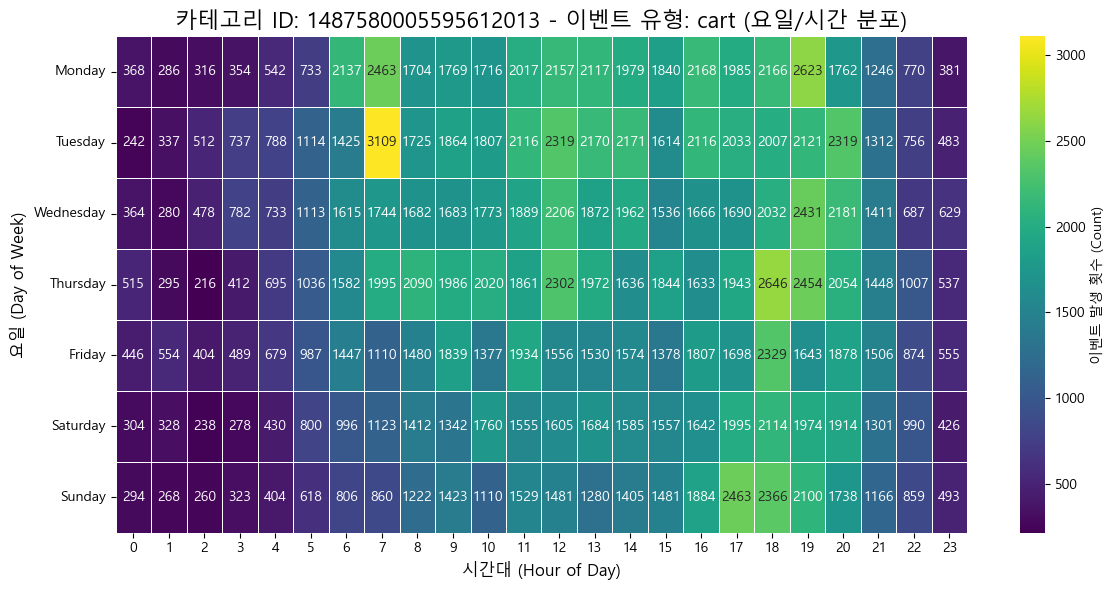

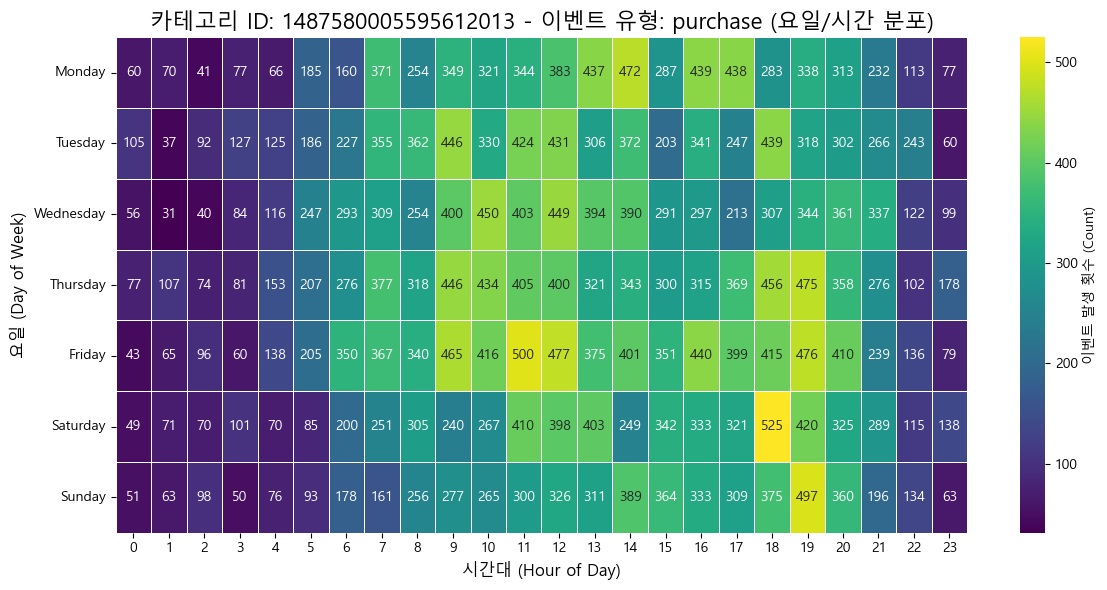

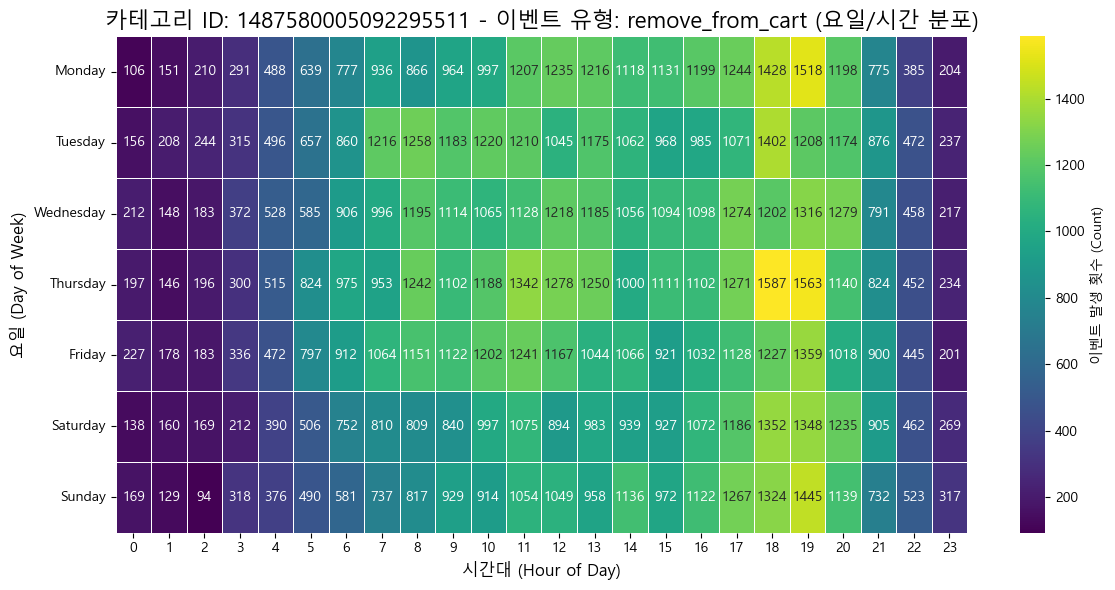

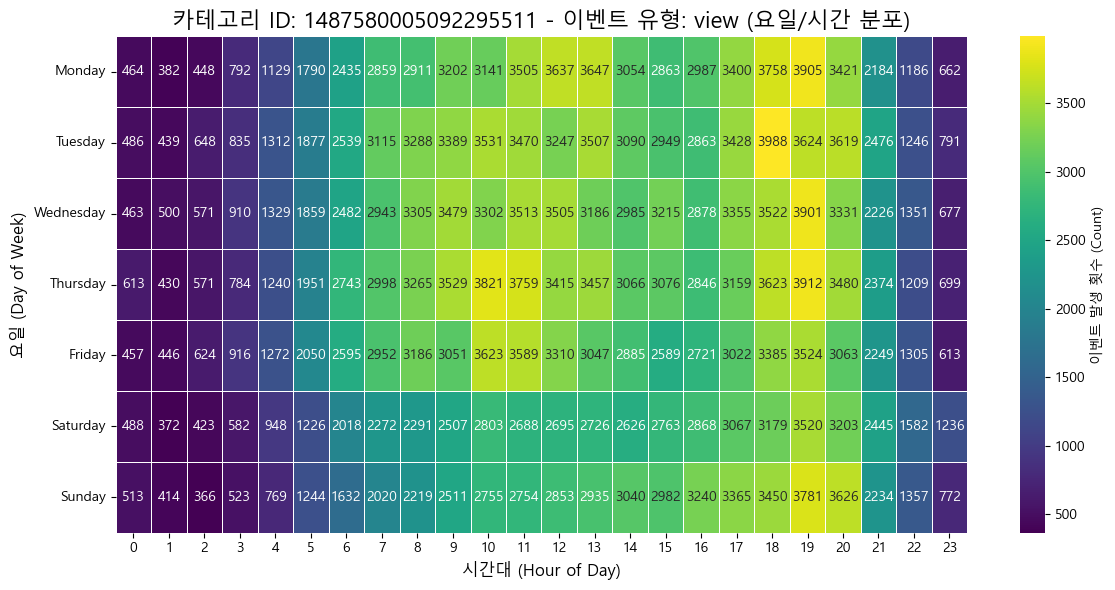

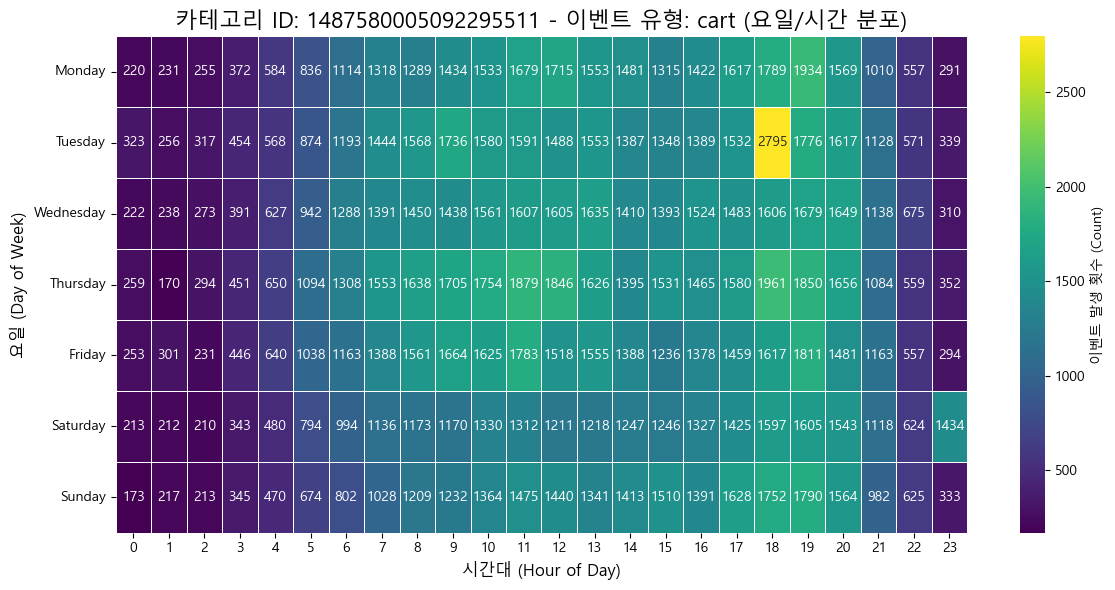

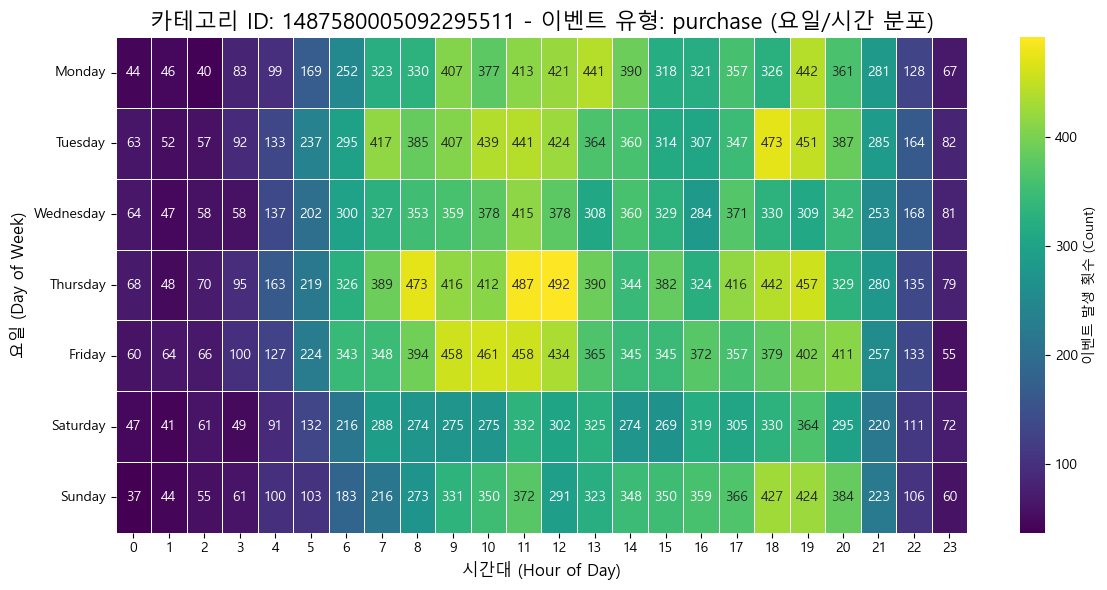

In [65]:
# 📌 이미 선언된 요일 순서 활용
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# **주의: 'day_name' 컬럼이 영어 요일 이름으로 되어 있고, 'hour' 컬럼이 이미 존재한다고 가정합니다.**

# 1. 분석할 카테고리와 이벤트 유형을 정의 (예시)
# 가장 빈번한 상위 3개 카테고리 선택
top_categories = df_combined['category_id'].value_counts().head(3).index.tolist()
event_types = df_combined['event_type'].unique().tolist()

# 2. 히트맵 생성 및 시각화
for category in top_categories:
    
    # 2.1. 해당 카테고리 데이터 필터링
    df_cat = df_combined[df_combined['category_id'] == category].copy()
    
    # 2.2. 이벤트 유형별로 반복하여 히트맵 생성
    for event_type in event_types:
        
        # 해당 이벤트 유형 데이터 필터링
        df_plot = df_cat[df_cat['event_type'] == event_type].copy()
        
        # 요일-시간별 발생 횟수 집계 (피벗 테이블 형태)
        if not df_plot.empty:
            
            # 피벗 테이블 생성: day_name(인덱스), hour(컬럼), 값(개수)
            event_pivot = df_plot.pivot_table(
                index='weekday_name',
                columns='hour', 
                values='event_type', 
                aggfunc='size', # 내부 count
                fill_value=0
            )
            
            # 📌 요일 순서 지정 (weekday_order 사용)
            # 만약 'day_name'에 한글 요일이 있다면, 이 부분에서 오류가 발생할 수 있습니다.
            event_pivot = event_pivot.reindex(weekday_order)
            
            # 시각화
            plt.figure(figsize=(12, 6))
            
            sns.heatmap(
                event_pivot, 
                cmap="viridis", 
                annot=True, 
                fmt="d", 
                linewidths=.5, 
                cbar_kws={'label': '이벤트 발생 횟수 (Count)'}
            )
            
            plt.title(f'카테고리 ID: {category} - 이벤트 유형: {event_type} (요일/시간 분포)', fontsize=16)
            plt.xlabel('시간대 (Hour of Day)', fontsize=12)
            plt.ylabel('요일 (Day of Week)', fontsize=12)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

- 카테고리별 user_id 분포

✅ 폰트 설정: 'Malgun Gothic' 적용 완료.

             Category ID별 고유 사용자 수 (상위 20개)             
        category_id  unique_users
1487580005092295511        131487
1487580013841613016        114718
1487580008246412266        110036
1487580013950664926        107262
1602943681873052386         96182
1487580006300255120         91253
1487580005268456287         88362
1487580006317032337         74887
1487580005595612013         70615
1487580007675986893         68535
1487580009445982239         66518
1487580008263189483         60865
1487580005671109489         57535
1487580009286598681         49984
1487580008145748965         46409
1487580013522845895         39480
1487580005134238553         37193
1487580010100293687         36741
1487580006350586771         36527
1487580009051717646         36082


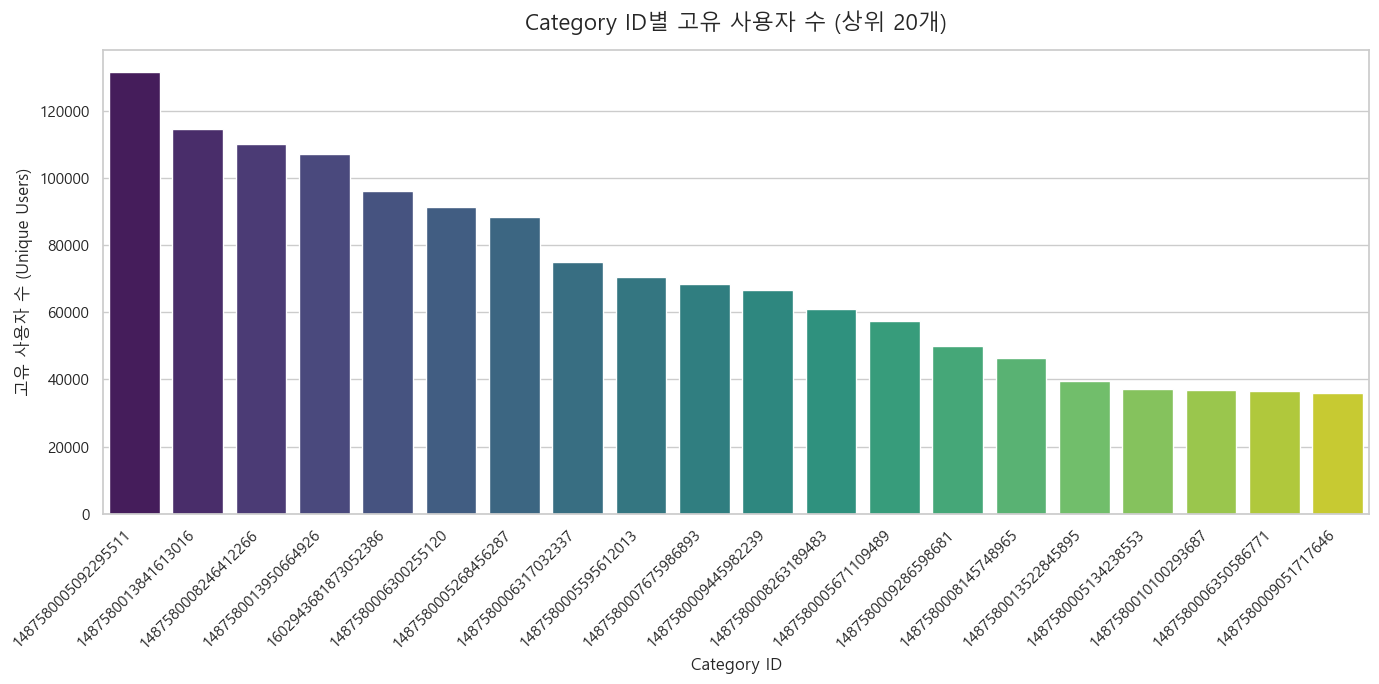

In [66]:
# 1. 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# 📌 강력한 한글 폰트 설정 (Matplotlib과 Seaborn 모두 적용)
try:
    # Matplotlib의 기본 폰트 설정
    plt.rc("font", family="Malgun Gothic")
    # Seaborn의 기본 스타일과 함께 폰트 및 마이너스 부호 설정
    sns.set(font="Malgun Gothic", 
            rc={"axes.unicode_minus": False}, 
            style='whitegrid') 
    print("✅ 폰트 설정: 'Malgun Gothic' 적용 완료.")
except Exception as e:
    print(f"⚠️ 폰트 설정 오류: {e}. 환경에 'Malgun Gothic'이 설치되어 있는지 확인하세요.")


# --------------------- 데이터 준비 (기존 코드 유지) ---------------------

# 1. Category ID별 고유 user_id 수 계산
category_user_counts = df_combined.groupby('category_id')['user_id'].nunique().reset_index()
category_user_counts.rename(columns={'user_id': 'unique_users'}, inplace=True)

# 2. 고유 사용자 수 기준 내림차순 정렬
top_20_categories = category_user_counts.sort_values(by='unique_users', ascending=False).head(20)

# 3. 표(DataFrame) 출력 (확인용)
print("\n==================================================================")
print("             Category ID별 고유 사용자 수 (상위 20개)             ")
print("==================================================================")
print(top_20_categories.to_string(index=False, float_format='{:,}'.format))
print("==================================================================")


# 4. 막대 그래프 시각화 (Seaborn 사용)
plt.figure(figsize=(14, 7))

sns.barplot(
    x='category_id', 
    y='unique_users', 
    data=top_20_categories, 
    palette='viridis',
    order=top_20_categories['category_id'] 
)

# 그래프 설정
# 폰트 설정이 적용되어 한글 제목이 정상적으로 출력됩니다.
plt.title('Category ID별 고유 사용자 수 (상위 20개)', fontsize=16, pad=15)
plt.xlabel('Category ID', fontsize=12)
plt.ylabel('고유 사용자 수 (Unique Users)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()
# 1487580006300255120


            Category ID별 고유 사용자 수 (하위 20개)             
        category_id  unique_users
1487580011450859636             6
1487580006216369036             5
1487580012231000209             5
1487580011224367209             5
1487580005796938615             4
1487580008204469224             4
1487580009857024046             4
1487580005654332272             4
1487580013363462335             4
1487580012549767321             4
1487580010024796212             3
1487580011140481125             3
1487580011073372258             3
1487580007155893175             2
1487580013715783889             2
1487580010897211483             1
1487580009706029097             1
1487580011056595041             1
1487580005159404378             1
1487580009890578479             1


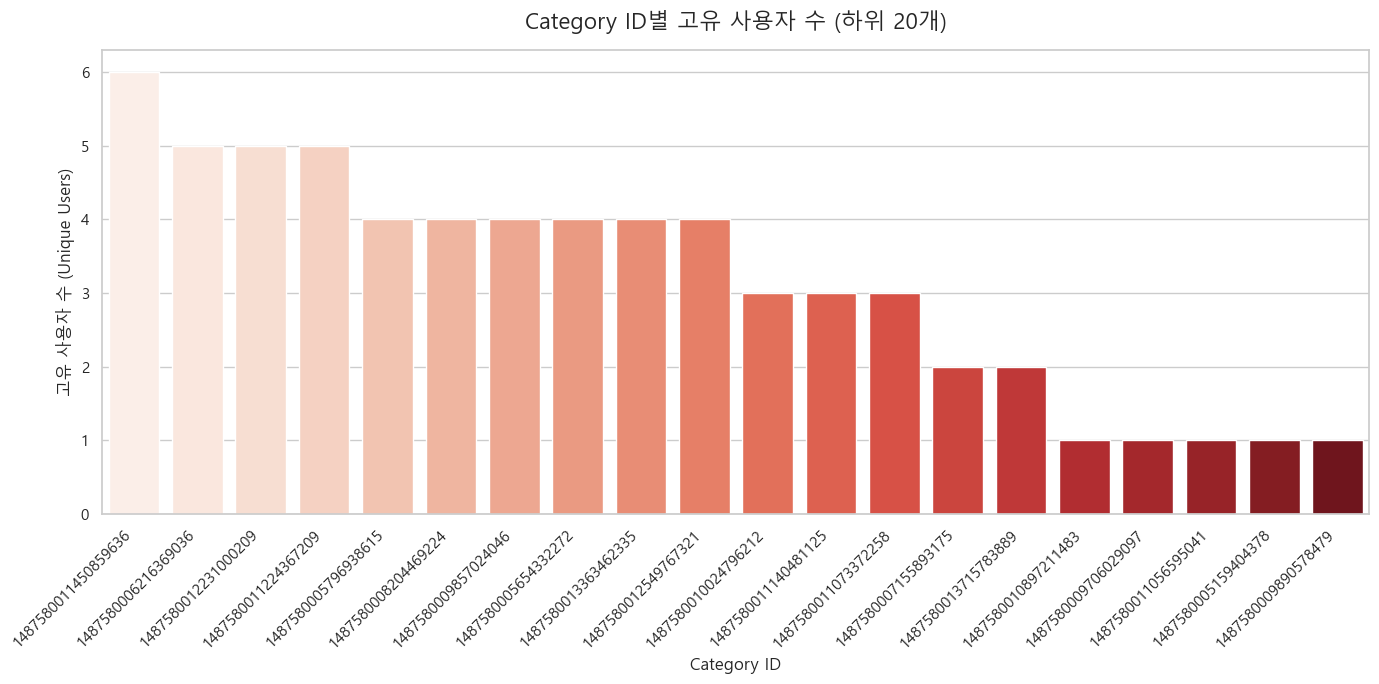

In [67]:
# 1. 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# 📌 강력한 한글 폰트 설정 (웹에서 찾으신 내용을 반영)
# Matplotlib의 기본 폰트 설정
plt.rc("font", family="Malgun Gothic")
# Seaborn의 기본 스타일과 함께 폰트 및 마이너스 부호 설정
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') # 기존 코드의 'seaborn-v0_8-whitegrid'와 유사한 스타일 사용

# ------------------------------------------------------------------

# 1. Category ID별 고유 user_id 수 계산
category_user_counts = df_combined.groupby('category_id')['user_id'].nunique().reset_index()
category_user_counts.rename(columns={'user_id': 'unique_users'}, inplace=True)

# 2. 고유 사용자 수 기준 내림차순 정렬
# 하위 20개 카테고리 선택: .tail(20) 사용
bottom_20_categories = category_user_counts.sort_values(by='unique_users', ascending=False).tail(20)

# 3. 표(DataFrame) 출력 (확인용)
print("\n==================================================================")
print("            Category ID별 고유 사용자 수 (하위 20개)             ")
print("==================================================================")
print(bottom_20_categories.to_string(index=False, float_format='{:,}'.format))
print("==================================================================")


# 4. 막대 그래프 시각화 (Seaborn 사용)
plt.figure(figsize=(14, 7))

sns.barplot(
    x='category_id', 
    y='unique_users', 
    # 📌 수정된 변수 사용
    data=bottom_20_categories, 
    palette='Reds', # 하위 카테고리임을 나타내기 위해 빨간색 팔레트 사용
    order=bottom_20_categories['category_id'] 
)

# 그래프 설정
plt.title('Category ID별 고유 사용자 수 (하위 20개)', fontsize=16, pad=15)
plt.xlabel('Category ID', fontsize=12)
plt.ylabel('고유 사용자 수 (Unique Users)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

- 카테고리별 구매전환률(구매율) 상하위 n개 cart -> 구매

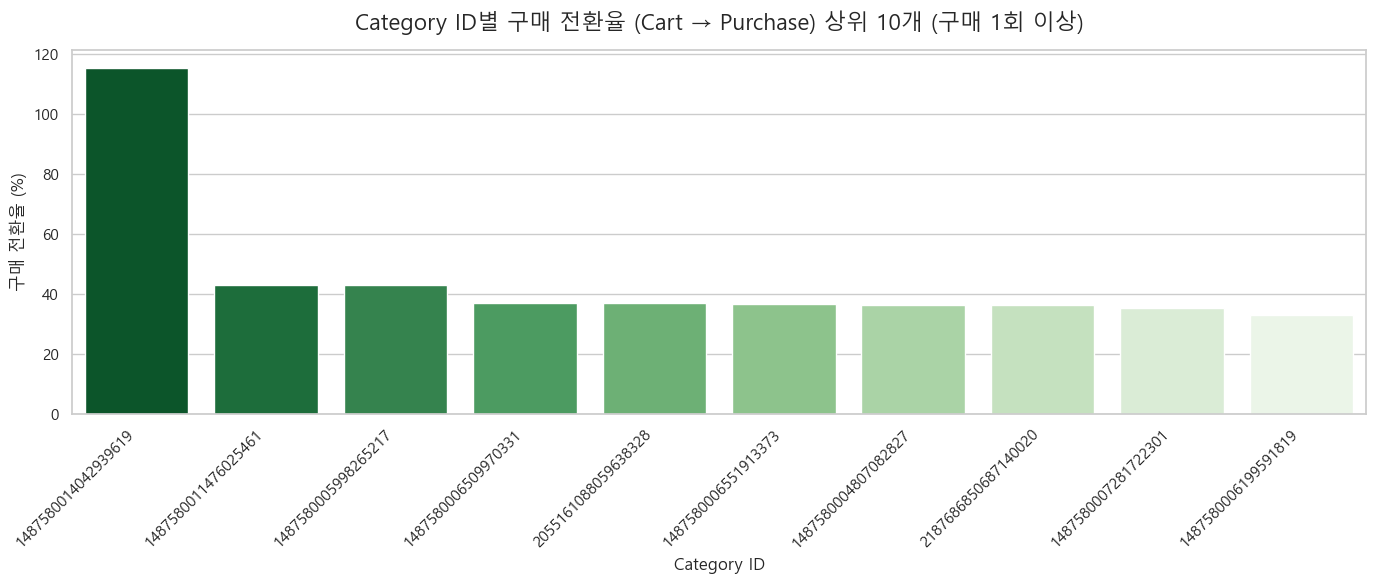

--- 구매 전환율 상위 10개 카테고리 (구매 1회 이상) ---
        category_id  purchase_rate_percent
1487580014042939619                115.38%
1487580011476025461                 42.99%
1487580005998265217                 42.86%
1487580006509970331                 36.92%
2055161088059638328                 36.91%
1487580006551913373                 36.51%
1487580004807082827                 36.36%
2187686850687140020                 36.36%
1487580007281722301                 35.19%
1487580006199591819                 32.98%


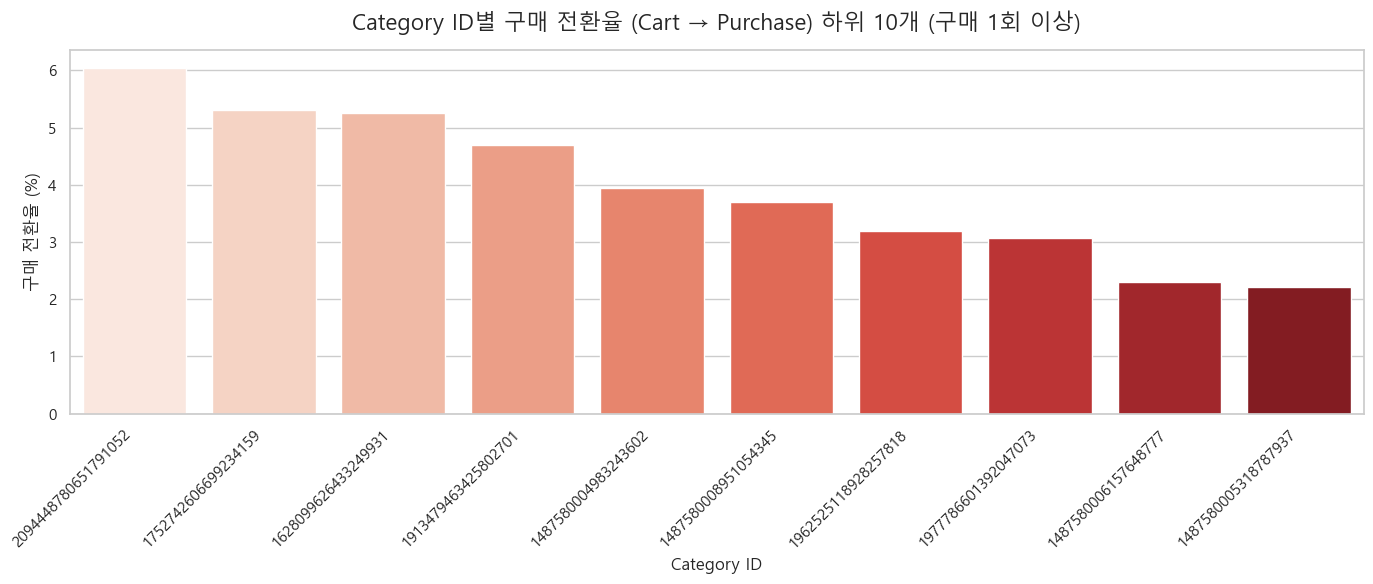


--- 구매 전환율 하위 10개 카테고리 (구매 1회 이상, 개선 필요) ---
        category_id  purchase_rate_percent
2094448780651791052                  6.05%
1752742606699234159                  5.31%
1628099626433249931                  5.26%
1913479463425802701                  4.69%
1487580004983243602                  3.95%
1487580008951054345                  3.70%
1962525118928257818                  3.19%
1977786601392047073                  3.08%
1487580006157648777                  2.30%
1487580005318787937                  2.22%


In [68]:
warnings.filterwarnings('ignore')

# 📌 폰트 설정
plt.rc("font", family="Malgun Gothic")
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') 

# --------------------- 카테고리별 전환율 계산 및 필터링 ---------------------

# 1. Category ID별 이벤트 수 집계
category_events = df_combined.groupby('category_id')['event_type'].value_counts().unstack(fill_value=0).reset_index()

# 2. 필요한 컬럼 추출 및 정리
if 'cart' not in category_events.columns:
    category_events['cart'] = 0
if 'purchase' not in category_events.columns:
    category_events['purchase'] = 0

# 3. 구매 건수가 최소 1 이상인 카테고리만 필터링 (★ 수정된 부분)
# 0인 항목을 제외하여 유의미한 비교를 수행합니다.
valid_categories = category_events[category_events['purchase'] >= 1].copy()

# 4. 구매 전환율 (Cart to Purchase) 계산
# Formula: (purchase count) / (cart count)
valid_categories['purchase_rate'] = valid_categories.apply(
    lambda row: row['purchase'] / row['cart'] if row['cart'] > 0 else 0, # 이미 purchase >= 1 이므로 0이 나올 확률은 낮지만 안전장치
    axis=1
)

# 5. 결과 정리
conversion_rates = valid_categories[['category_id', 'purchase_rate']].sort_values(by='purchase_rate', ascending=False)
conversion_rates['purchase_rate_percent'] = conversion_rates['purchase_rate'] * 100

# 시각화할 상위/하위 N개 정의
N = 10
top_N = conversion_rates.head(N)
bottom_N = conversion_rates.tail(N)

plt.figure(figsize=(14, 6))

sns.barplot(
    x='category_id', 
    y='purchase_rate_percent', 
    data=top_N, 
    palette='Greens_r', 
    order=top_N['category_id'] 
)

# 그래프 설정
plt.title(f'Category ID별 구매 전환율 (Cart → Purchase) 상위 {N}개 (구매 1회 이상)', fontsize=16, pad=15)
plt.xlabel('Category ID', fontsize=12)
plt.ylabel('구매 전환율 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 결과 출력 (표)
print(f"--- 구매 전환율 상위 {N}개 카테고리 (구매 1회 이상) ---")
print(top_N[['category_id', 'purchase_rate_percent']].to_string(index=False, float_format='{:.2f}%'.format))

plt.figure(figsize=(14, 6))

sns.barplot(
    x='category_id', 
    y='purchase_rate_percent', 
    data=bottom_N, 
    palette='Reds', 
    order=bottom_N['category_id'] 
)

# 그래프 설정
plt.title(f'Category ID별 구매 전환율 (Cart → Purchase) 하위 {N}개 (구매 1회 이상)', fontsize=16, pad=15)
plt.xlabel('Category ID', fontsize=12)
plt.ylabel('구매 전환율 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 결과 출력 (표)
print(f"\n--- 구매 전환율 하위 {N}개 카테고리 (구매 1회 이상, 개선 필요) ---")
print(bottom_N[['category_id', 'purchase_rate_percent']].to_string(index=False, float_format='{:.2f}%'.format))

In [69]:
df_combined.columns

Index(['event_time', 'event_type', 'product_id', 'category_id', 'brand',
       'price', 'user_id', 'user_session', 'year', 'month', 'day', 'hour',
       'minute', 'second', 'time_segment', 'day_period', 'weekday_name'],
      dtype='object')

# brand

- 결측치 처리 후 brand

In [70]:
df_combined['brand'].value_counts()

brand
Unknown    8757117
runail     1528908
irisk      1033852
masura      861763
grattol     852591
            ...   
shifei           9
vl-gel           7
dessata          6
gena             3
pueen            1
Name: count, Length: 274, dtype: int64

In [71]:
# 'Unknown' 브랜드 내의 event_type별 빈도수 계산
df_combined[df_combined['brand'] == 'Unknown']['event_type'].value_counts()

event_type
view                3972455
cart                2493706
remove_from_cart    1741263
purchase             549693
Name: count, dtype: int64

- Unknown에 대한 event_type 비율

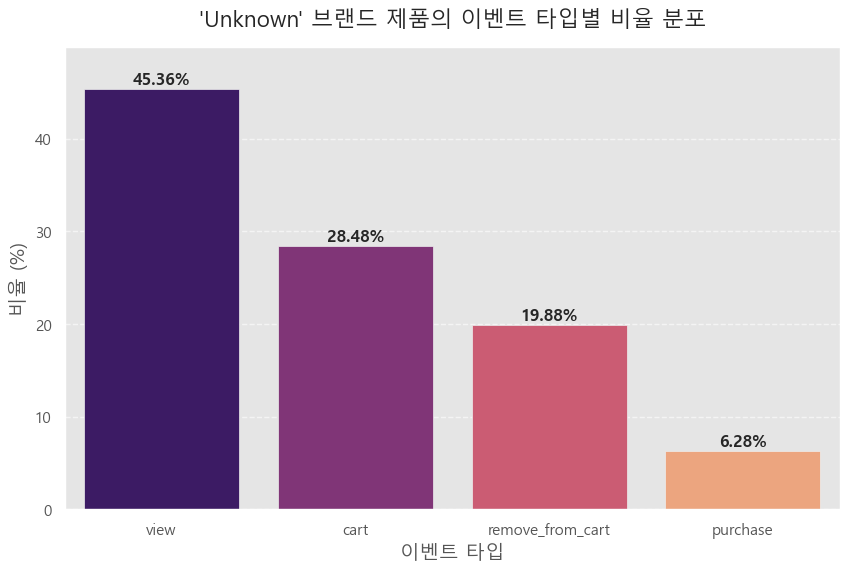

In [72]:
# 경고 메시지 무시 및 한글 폰트 설정 (이전 설정 유지)
warnings.filterwarnings('ignore')
try:
    plt.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot') # 그래프 스타일 설정

# 1. 'Unknown' 브랜드 이벤트 빈도수 (제공된 결과 데이터)
unknown_event_counts = pd.Series({
    'view': 3972455,
    'cart': 2493706,
    'remove_from_cart': 1741263,
    'purchase': 549693
})
unknown_event_counts.name = 'count' # Series에 이름 지정

# 2. 비율 계산 및 정렬
total_events = unknown_event_counts.sum()
unknown_event_proportion = unknown_event_counts.div(total_events) * 100

# 깔때기 순서에 맞게 데이터 정렬
funnel_order = ['view', 'cart', 'remove_from_cart', 'purchase']
unknown_event_proportion = unknown_event_proportion.reindex(funnel_order)

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=unknown_event_proportion.index, 
    y=unknown_event_proportion.values, 
    palette='magma' # 따뜻한 색상 계열 팔레트 사용
)

# 4. 각 막대 위에 비율(%) 값 표시
for i, value in enumerate(unknown_event_proportion.values):
    ax.text(
        i, 
        value + 0.5, 
        f'{value:.2f}%', 
        ha='center', 
        fontsize=12,
        fontweight='bold' # 비율을 강조
    )

# 5. 그래프 설정
plt.title('\'Unknown\' 브랜드 제품의 이벤트 타입별 비율 분포', fontsize=16, pad=15)
plt.xlabel('이벤트 타입', fontsize=14)
plt.ylabel('비율 (%)', fontsize=14)
plt.ylim(0, unknown_event_proportion.max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

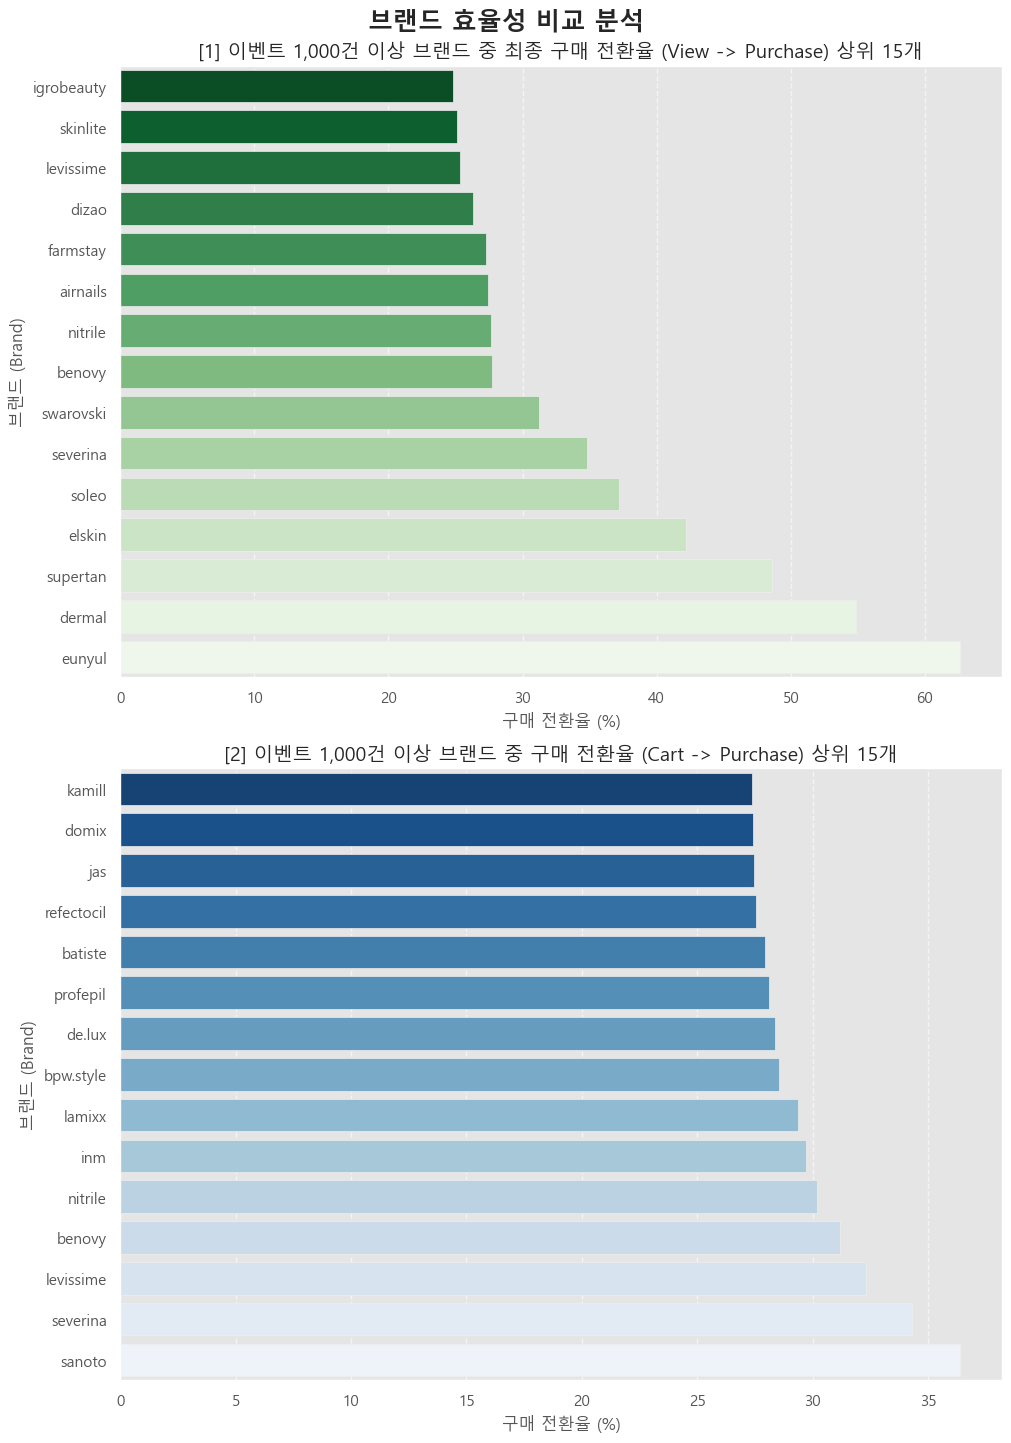

In [73]:
# ----------------------------------------------------
# 폰트 설정 (Windows PC 환경 최적화)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 
plt.style.use('ggplot') 
# ----------------------------------------------------

# **주의: 이 코드는 df_combined 데이터프레임과 brand_events 변수가 메모리에 정의되어 있다고 가정합니다.**

# 1. 'Unknown' 브랜드를 제외한 데이터셋 생성 및 이벤트 계산 (통합)
# 실제 실행 시 주석을 해제하고 사용해야 합니다.
df_branded = df_combined[df_combined['brand'] != 'Unknown'].copy()
brand_events = df_branded.groupby(['brand', 'event_type']).size().unstack(fill_value=0)

# 'view', 'cart', 'purchase' 컬럼이 있는지 확인 및 가져오기
view_counts = brand_events.get('view', pd.Series(0, index=brand_events.index))
cart_counts = brand_events.get('cart', pd.Series(0, index=brand_events.index))
purchase_counts = brand_events.get('purchase', pd.Series(0, index=brand_events.index))

# 4. 필터링 기준 설정
min_events = 1000
top_n = 15
valid_brands = brand_events.sum(axis=1) > min_events

# --- 전환율 계산 ---
# 2.1. 최종 구매 전환율 (View to Purchase)
conversion_rate_vp = (purchase_counts / view_counts) * 100
conversion_rate_vp = conversion_rate_vp.fillna(0)

# 2.2. 장바구니 대비 구매 전환율 (Cart to Purchase)
conversion_rate_cp = (purchase_counts / cart_counts) * 100
conversion_rate_cp = conversion_rate_cp.fillna(0)

# 3. 상위 N개 브랜드 추출
top_conversion_brands_vp = conversion_rate_vp[valid_brands].nlargest(top_n).sort_values(ascending=True)
top_conversion_brands_cp = conversion_rate_cp[valid_brands].nlargest(top_n).sort_values(ascending=True)


## 5. 시각화 (Subplots을 이용한 1개 페이지 출력)
fig, axes = plt.subplots(2, 1, figsize=(10, 14), constrained_layout=True)
# constrained_layout=True: 서브플롯 간 간격 자동 조정

# ----------------------------------------------------
# 첫 번째 서브플롯: View to Purchase 전환율
# ----------------------------------------------------
sns.barplot(
    x=top_conversion_brands_vp.values, 
    y=top_conversion_brands_vp.index, 
    palette='Greens_r',
    ax=axes[0] # 첫 번째 축에 할당
)
axes[0].set_title(f'[1] 이벤트 1,000건 이상 브랜드 중 최종 구매 전환율 (View -> Purchase) 상위 {top_n}개', fontsize=14)
axes[0].set_xlabel('구매 전환율 (%)', fontsize=12)
axes[0].set_ylabel('브랜드 (Brand)', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# ----------------------------------------------------
# 두 번째 서브플롯: Cart to Purchase 전환율
# ----------------------------------------------------
sns.barplot(
    x=top_conversion_brands_cp.values, 
    y=top_conversion_brands_cp.index, 
    palette='Blues_r',
    ax=axes[1] # 두 번째 축에 할당
)
axes[1].set_title(f'[2] 이벤트 1,000건 이상 브랜드 중 구매 전환율 (Cart -> Purchase) 상위 {top_n}개', fontsize=14)
axes[1].set_xlabel('구매 전환율 (%)', fontsize=12)
axes[1].set_ylabel('브랜드 (Brand)', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('브랜드 효율성 비교 분석', fontsize=18, fontweight='bold', y=1.02)
plt.show()

- 브랜드 별 평균 제품가격

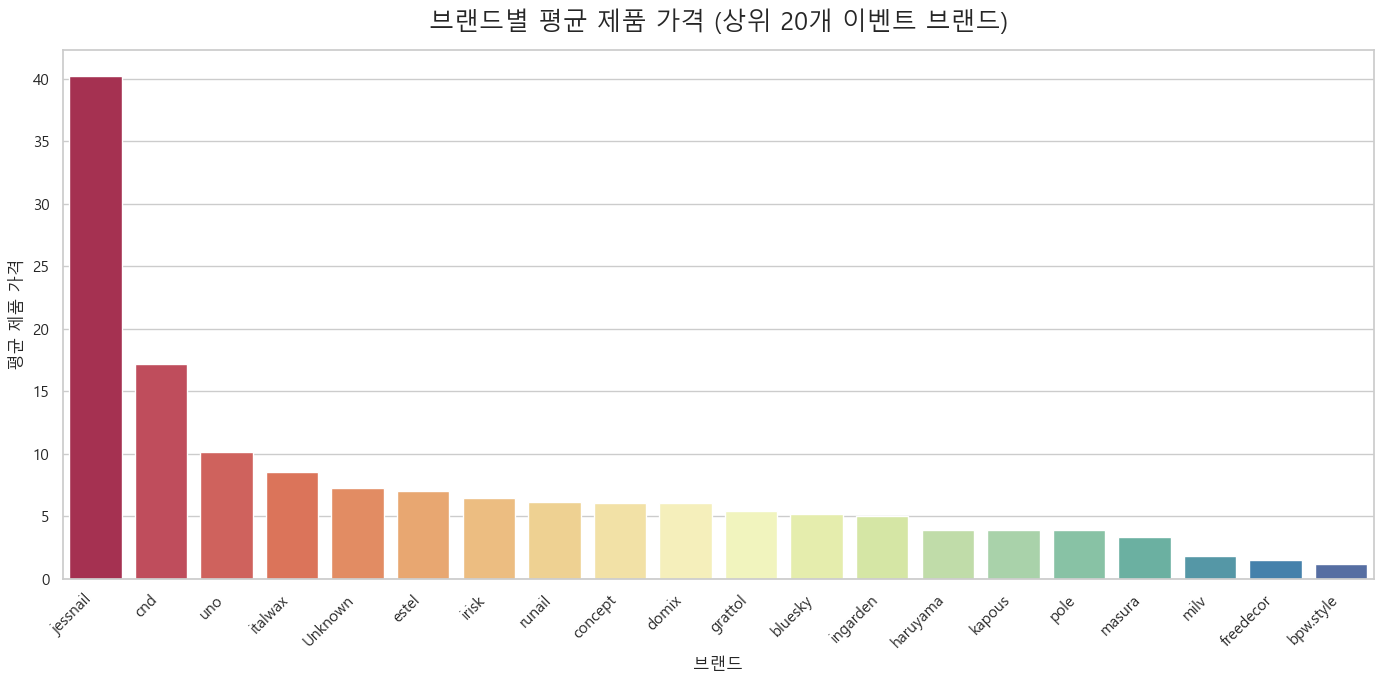

In [74]:
warnings.filterwarnings('ignore')

# 📌 폰트 설정 (이전 문제 해결 코드를 반영)
plt.rc("font", family="Malgun Gothic")
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') 

# 시각화할 상위 N개 브랜드 정의
N = 20 

# 1. 브랜드별 이벤트 발생 횟수를 기준으로 상위 N개 브랜드 선정
top_brands = df_combined['brand'].value_counts().head(N).index.tolist()

# 2. 상위 N개 브랜드 데이터만 필터링
df_top_brands = df_combined[df_combined['brand'].isin(top_brands)].copy()

# 3. 브랜드별 평균 가격 계산
# 주의: 'price' 컬럼이 숫자형(float/int)이라고 가정합니다.
brand_avg_price = df_top_brands.groupby('brand')['price'].mean().reset_index()
brand_avg_price.rename(columns={'price': 'avg_price'}, inplace=True)

# 4. 평균 가격 기준으로 내림차순 정렬 (시각화 순서를 위해)
brand_avg_price_sorted = brand_avg_price.sort_values(by='avg_price', ascending=False)

plt.figure(figsize=(14, 7))

# 막대 그래프 생성 (브랜드별 평균 가격)
sns.barplot(
    x='brand', 
    y='avg_price', 
    data=brand_avg_price_sorted, 
    palette='Spectral', # 다양한 색상 팔레트를 사용해 브랜드 구분
    order=brand_avg_price_sorted['brand'] # 정렬된 순서대로 표시
)

# 그래프 설정
plt.title(f'브랜드별 평균 제품 가격 (상위 {N}개 이벤트 브랜드)', fontsize=18, pad=15)
plt.xlabel('브랜드', fontsize=12)
plt.ylabel('평균 제품 가격', fontsize=12)
plt.xticks(rotation=45, ha='right') # 브랜드 이름이 길 경우 회전
plt.ticklabel_format(style='plain', axis='y') # Y축 숫자를 지수표기법이 아닌 일반 숫자로 표시
plt.tight_layout()
plt.show()

- 연도별 total price(매출) 기준 상위-하위(10%) 10개 brand & 원본

In [75]:
# 1. 연도별, 브랜드별 총 매출(Total Price) 계산
yearly_brand_sales = df_combined.groupby(['year', 'brand'])['price'].sum().reset_index()
yearly_brand_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 'Unknown' 브랜드는 분석에서 제외합니다. (필수)
yearly_brand_sales = yearly_brand_sales[yearly_brand_sales['brand'] != 'Unknown'].copy()


# 2. 연도별 상위 10% 및 하위 10% 기준 계산
results = {}

for year in yearly_brand_sales['year'].unique():
    # 해당 연도의 데이터만 필터링
    df_year = yearly_brand_sales[yearly_brand_sales['year'] == year].copy()
    
    # 해당 연도에 브랜드가 충분히 적을 경우 (10개 미만) 분석을 건너뜁니다.
    if len(df_year) < 10:
        print(f"⚠️ {year}년은 브랜드 수가 너무 적어(N={len(df_year)}) 10% 분석을 건너뜁니다.")
        continue

    # 총 매출액(total_sales) 기준 상위 90% (상위 10% 컷오프 지점) 계산
    upper_threshold = df_year['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (하위 10% 컷오프 지점) 계산
    lower_threshold = df_year['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 브랜드 필터링
    
    # 상위 10% 브랜드 (매출액이 상위 90% 기준점보다 크거나 같은 브랜드)
    top_10_percent = df_year[df_year['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 브랜드 (매출액이 하위 10% 기준점보다 작거나 같은 브랜드)
    bottom_10_percent = df_year[df_year['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[year] = {
        'Upper_10_Percent': top_10_percent[['brand', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['brand', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for year, data in results.items():
    print(f"============================ 📅 연도: {year} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Upper_10_Percent'].head(10))

    print("\n--- 하위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Lower_10_Percent'].head(10))
    print("\n" + "=" * 60)

============================ 📅 연도: 2019 ============================
💰 상위 10% 기준 매출액: >= 638083.79
📉 하위 10% 기준 매출액: <= 755.94

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sales
230    strong   7029840.61
121  jessnail   5959861.14
213    runail   5555264.05
117     irisk   3829816.85
102   grattol   2689217.09
163  marathon   2598852.45
40        cnd   2047646.70
166    masura   1710050.94
242       uno   1519929.29
80      estel   1474591.20

--- 하위 10% Brand (매출액 기준) ---
            brand  total_sales
204         pueen         6.98
247        vl-gel         7.56
109           ibd        15.68
248         voesh        15.75
98           gena        17.78
219        shifei        28.09
31       bodipure        48.43
116  invisibobble        64.40
187          nova        71.96
243      uralsoap        88.74

============================ 📅 연도: 2020 ============================
💰 상위 10% 기준 매출액: >= 378875.20
📉 하위 10% 기준 매출액: <= 353.81

--- 상위 10% Brand (매출액 기준) ---
        brand  t

- Price < 0 인 값을 0으로 처리 & 집계 기준 median

In [23]:
# 1. 'purchase' 이벤트만 필터링한 후, 연도별, 브랜드별 총 매출(Total Price) 계산
# df_combined는 전체 이벤트 데이터프레임이라고 가정
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()

# 📌 핵심 수정 로직: Price < 0 인 값을 0으로 처리 (취소/환불 건을 매출 집계에서 제외)
# 이 로직을 통해 'total_sales'는 순매출액을 의미하게 됩니다.
df_purchase.loc[df_purchase['price'] < 0, 'price'] = 0

yearly_brand_sales = df_purchase.groupby(['year', 'brand'])['price'].median().reset_index()
yearly_brand_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 'Unknown' 브랜드는 분석에서 제외합니다. (필수)
# 이미 앞선 전처리 단계에서 Null 값이 'unknown'으로 치환되었으므로 'unknown'으로 처리합니다.
yearly_brand_sales = yearly_brand_sales[yearly_brand_sales['brand'] != 'unknown'].copy()


# 2. 연도별 상위 10% 및 하위 10% 기준 계산
results = {}

for year in yearly_brand_sales['year'].unique():
    # 해당 연도의 데이터만 필터링
    df_year = yearly_brand_sales[yearly_brand_sales['year'] == year].copy()
    
    # 해당 연도에 브랜드가 충분히 적을 경우 (10개 미만) 분석을 건너뜁니다.
    if len(df_year) < 10:
        print(f"⚠️ {year}년은 브랜드 수가 너무 적어(N={len(df_year)}) 10% 분석을 건너뜁니다.")
        continue

    # 총 매출액(total_sales) 기준 상위 90% (상위 10% 컷오프 지점) 계산
    upper_threshold = df_year['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (하위 10% 컷오프 지점) 계산
    # 0원 처리 로직 덕분에 음수 매출액이 하위 10%에 포함되는 오류가 사라집니다.
    lower_threshold = df_year['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 브랜드 필터링
    
    # 상위 10% 브랜드 (매출액이 상위 90% 기준점보다 크거나 같은 브랜드)
    top_10_percent = df_year[df_year['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 브랜드 (매출액이 하위 10% 기준점보다 작거나 같은 브랜드)
    bottom_10_percent = df_year[df_year['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[year] = {
        'Upper_10_Percent': top_10_percent[['brand', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['brand', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for year, data in results.items():
    print(f"============================ 📅 연도: {year} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Upper_10_Percent'].head(10))

    print("\n--- 하위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Lower_10_Percent'].head(10))
    print("\n" + "=" * 60)

============================ 📅 연도: 2019 ============================
💰 상위 10% 기준 매출액: >= 23.36
📉 하위 10% 기준 매출액: <= 1.80

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sales
211    strong       194.44
197    sanoto       157.14
147  marathon       137.78
196    s.care       103.17
154       max        79.21
212       sun        74.14
227     vosev        62.70
37     coifin        55.56
181   polarus        53.81
167   neoleor        51.70

--- 하위 10% Brand (매출액 기준) ---
            brand  total_sales
207         soleo         0.71
79       farmstay         0.79
48         de.lux         0.79
68         entity         0.84
74         eunyul         0.95
214      supertan         0.95
52         dermal         1.03
192  rocknailstar         1.07
27          blixz         1.19
41         cosima         1.19

============================ 📅 연도: 2020 ============================
💰 상위 10% 기준 매출액: >= 26.25
📉 하위 10% 기준 매출액: <= 1.97

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sales
4

- sum & 연도별 개월 수에 대한 평균

In [11]:
warnings.filterwarnings('ignore')

# 1. 'purchase' 이벤트 필터링 및 전처리
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()

# 📌 가격 이상치 처리 (순매출 집계를 위해 음수 및 0원 미만 0 처리)
df_purchase.loc[df_purchase['price'] < 0, 'price'] = 0

# 2. 브랜드별 연도별 총 매출 합계 계산
# 'median' 대신 'sum'을 사용하여 실제 매출 규모를 파악합니다.
yearly_brand_sales = df_purchase.groupby(['year', 'brand'])['price'].sum().reset_index()
yearly_brand_sales.rename(columns={'price': 'total_sales_sum'}, inplace=True)

# 'Unknown' 브랜드 제외
yearly_brand_sales = yearly_brand_sales[yearly_brand_sales['brand'] != 'Unknown'].copy()

# 3. 📌 월평균 매출 정규화 (Normalization)
# 연도별로 데이터에 포함된 고유 월(Month)의 개수를 계산합니다. (19년: 3개, 20년: 2개 자동 계산)
month_counts = df_purchase.groupby('year')['event_time'].apply(lambda x: x.dt.month.nunique()).to_dict()

# 연도별 월 수로 나누어 '월평균 매출' 컬럼 생성
yearly_brand_sales['avg_monthly_sales'] = yearly_brand_sales.apply(
    lambda row: row['total_sales_sum'] / month_counts[row['year']], axis=1
)

# 4. 연도별 상위 10% 및 하위 10% 분석
results = {}

for year in yearly_brand_sales['year'].unique():
    # 해당 연도 데이터 필터링
    df_year = yearly_brand_sales[yearly_brand_sales['year'] == year].copy()
    
    if len(df_year) < 10:
        print(f"⚠️ {year}년은 브랜드 수가 너무 적어(N={len(df_year)}) 분석을 건너뜁니다.")
        continue

    # 📌 기준점을 'avg_monthly_sales'로 설정 (공정한 비교)
    upper_threshold = df_year['avg_monthly_sales'].quantile(0.9)
    lower_threshold = df_year['avg_monthly_sales'].quantile(0.1)

    # 상위 10% 브랜드
    top_10_percent = df_year[df_year['avg_monthly_sales'] >= upper_threshold].sort_values(
        'avg_monthly_sales', ascending=False
    )
    
    # 하위 10% 브랜드
    bottom_10_percent = df_year[df_year['avg_monthly_sales'] <= lower_threshold].sort_values(
        'avg_monthly_sales', ascending=True
    )
    
    results[year] = {
        'Upper_10_Percent': top_10_percent[['brand', 'avg_monthly_sales', 'total_sales_sum']],
        'Lower_10_Percent': bottom_10_percent[['brand', 'avg_monthly_sales', 'total_sales_sum']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold,
        'Months_Count': month_counts[year]
    }

# 5. 결과 출력
for year, data in results.items():
    print(f"\n" + "=" * 30 + f" 📅 연도: {year} ({data['Months_Count']}개월 기준) " + "=" * 30)
    print(f"💰 월평균 상위 10% 기준액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 월평균 하위 10% 기준액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 🏆 상위 10% Brand (월평균 매출 기준) ---")
    print(data['Upper_10_Percent'].head(10).to_string(index=False, float_format='{:.2f}'.format))

    print("\n--- 📉 하위 10% Brand (월평균 매출 기준) ---")
    print(data['Lower_10_Percent'].head(10).to_string(index=False, float_format='{:.2f}'.format))
    print("\n" + "=" * 85)


============================== 📅 연도: 2019 (3개월 기준) ==============================
💰 월평균 상위 10% 기준액: >= 9558.01
📉 월평균 하위 10% 기준액: <= 21.02

--- 🏆 상위 10% Brand (월평균 매출 기준) ---
   brand  avg_monthly_sales  total_sales_sum
  runail           68825.07        206475.20
 grattol           50237.25        150711.75
   irisk           42609.84        127829.51
     uno           38475.51        115426.54
  strong           30044.77         90134.31
  masura           28044.58         84133.74
jessnail           27902.69         83708.07
     cnd           26206.56         78619.69
ingarden           25221.94         75665.81
   estel           23457.87         70373.61

--- 📉 하위 10% Brand (월평균 매출 기준) ---
       brand  avg_monthly_sales  total_sales_sum
  helloganic               1.03             3.10
rocknailstar               1.43             4.28
       ovale               4.42            13.26
     lunaris               5.40            16.19
      weaver               5.46            16.38


- 월별 total price(매출) 기준 상위-하위(10%) 10개 brand

In [77]:
# 1. 월별, 브랜드별 총 매출(Total Price) 계산
monthly_brand_sales = df_combined.groupby(['month', 'brand'])['price'].sum().reset_index()
monthly_brand_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 'Unknown' 브랜드는 분석에서 제외합니다.
monthly_brand_sales = monthly_brand_sales[monthly_brand_sales['brand'] != 'Unknown'].copy()


# 2. 월별 상위 10% 및 하위 10% 기준 계산
results = {}

# 월별로 반복하며 분석을 수행합니다.
for month in monthly_brand_sales['month'].unique():
    # 해당 월의 데이터만 필터링
    df_month = monthly_brand_sales[monthly_brand_sales['month'] == month].copy()
    
    # 해당 월에 브랜드가 충분히 적을 경우 (10개 미만) 분석을 건너뜁니다.
    if len(df_month) < 10:
        print(f"⚠️ {month}월은 브랜드 수가 너무 적어(N={len(df_month)}) 10% 분석을 건너뜁니다.")
        continue
    
    # 총 매출액(total_sales) 기준 상위 90% (상위 10% 컷오프 지점) 계산
    upper_threshold = df_month['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (하위 10% 컷오프 지점) 계산
    lower_threshold = df_month['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 브랜드 필터링
    
    # 상위 10% 브랜드 (매출액이 상위 90% 기준점보다 크거나 같은 브랜드)
    top_10_percent = df_month[df_month['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 브랜드 (매출액이 하위 10% 기준점보다 작거나 같은 브랜드)
    bottom_10_percent = df_month[df_month['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[month] = {
        'Upper_10_Percent': top_10_percent[['brand', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['brand', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for month, data in results.items():
    print(f"============================ 📅 월: {month} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Upper_10_Percent'].head(10))

    print("\n--- 하위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Lower_10_Percent'].head(10))
    print("\n" + "=" * 60)

============================ 📅 월: 1 ============================
💰 상위 10% 기준 매출액: >= 222038.68
📉 하위 10% 기준 매출액: <= 287.08

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sales
228    strong   2651513.68
120  jessnail   2297451.20
211    runail   2108654.99
116     irisk   1467889.09
102   grattol   1055984.47
163  marathon    789238.63
166    masura    693152.74
41        cnd    599136.32
241       uno    546019.05
81      estel    544366.80

--- 하위 10% Brand (매출액 기준) ---
            brand  total_sales
92            fly         2.22
246        vl-gel         2.52
247         voesh         2.54
91         finish         5.40
187          nova         5.40
115  invisibobble         9.20
217        shifei        14.04
38          candy        25.74
32       bodipure        26.77
242      uralsoap        31.23

============================ 📅 월: 2 ============================
💰 상위 10% 기준 매출액: >= 197364.72
📉 하위 10% 기준 매출액: <= 243.51

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sal

- Price < 0 인 값을 0으로 처리

In [12]:
# 1. 'purchase' 이벤트만 필터링한 후, 월별, 브랜드별 총 매출(Total Price) 계산
# df_combined는 전체 이벤트 데이터프레임이라고 가정
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()

# 📌 핵심 수정 로직: Price < 0 인 값을 0으로 처리 (취소/환불 건을 매출 집계에서 제외)
# 이 로직을 통해 'total_sales'는 순매출액을 의미하게 됩니다.
df_purchase.loc[df_purchase['price'] < 0, 'price'] = 0

monthly_brand_sales = df_purchase.groupby(['month', 'brand'])['price'].sum().reset_index()
monthly_brand_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# 'Unknown' 브랜드는 분석에서 제외합니다. (앞선 전처리에서 'unknown'으로 치환된 것으로 가정)
monthly_brand_sales = monthly_brand_sales[monthly_brand_sales['brand'] != 'unknown'].copy()
# 혹시 'Unknown' (대문자 U)이 남아있다면 한 번 더 제외합니다.
monthly_brand_sales = monthly_brand_sales[monthly_brand_sales['brand'] != 'Unknown'].copy()


# 2. 월별 상위 10% 및 하위 10% 기준 계산
results = {}

# 월별로 반복하며 분석을 수행합니다.
for month in monthly_brand_sales['month'].unique():
    # 해당 월의 데이터만 필터링
    df_month = monthly_brand_sales[monthly_brand_sales['month'] == month].copy()
    
    # 해당 월에 브랜드가 충분히 적을 경우 (10개 미만) 분석을 건너뜁니다.
    if len(df_month) < 10:
        print(f"⚠️ {month}월은 브랜드 수가 너무 적어(N={len(df_month)}) 10% 분석을 건너뜁니다.")
        continue
    
    # 총 매출액(total_sales) 기준 상위 90% (상위 10% 컷오프 지점) 계산
    upper_threshold = df_month['total_sales'].quantile(0.9)
    
    # 총 매출액(total_sales) 기준 하위 10% (하위 10% 컷오프 지점) 계산
    # 0원 처리 로직 덕분에 음수 매출액이 하위 10%에 포함되는 오류가 사라집니다.
    lower_threshold = df_month['total_sales'].quantile(0.1)

    # 3. 상위/하위 10% 브랜드 필터링
    
    # 상위 10% 브랜드 (매출액이 상위 90% 기준점보다 크거나 같은 브랜드)
    top_10_percent = df_month[df_month['total_sales'] >= upper_threshold].sort_values(
        'total_sales', ascending=False
    )
    
    # 하위 10% 브랜드 (매출액이 하위 10% 기준점보다 작거나 같은 브랜드)
    # 이제 순매출 기여도가 가장 낮은 브랜드들로 구성됩니다.
    bottom_10_percent = df_month[df_month['total_sales'] <= lower_threshold].sort_values(
        'total_sales', ascending=True
    )
    
    # 결과를 딕셔너리에 저장
    results[month] = {
        'Upper_10_Percent': top_10_percent[['brand', 'total_sales']],
        'Lower_10_Percent': bottom_10_percent[['brand', 'total_sales']],
        'Upper_Threshold': upper_threshold,
        'Lower_Threshold': lower_threshold
    }

# 4. 결과 출력
for month, data in results.items():
    print(f"============================ 📅 월: {month} ============================")
    print(f"💰 상위 10% 기준 매출액: >= {data['Upper_Threshold']:.2f}")
    print(f"📉 하위 10% 기준 매출액: <= {data['Lower_Threshold']:.2f}")
    
    print("\n--- 상위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Upper_10_Percent'].head(10))

    print("\n--- 하위 10% Brand (매출액 기준) ---")
    # 결과가 너무 길어지는 것을 방지하기 위해 상위 10개만 출력합니다.
    print(data['Lower_10_Percent'].head(10))
    print("\n" + "=" * 60)

============================ 📅 월: 1 ============================
💰 상위 10% 기준 매출액: >= 9075.64
📉 하위 10% 기준 매출액: <= 57.68

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sales
190    runail     80707.34
89    grattol     63743.67
100     irisk     45746.89
216       uno     42533.50
205    strong     34607.65
147    masura     34448.60
71      estel     26986.40
104  jessnail     25641.09
96   ingarden     25367.33
101   italwax     20373.97

--- 하위 10% Brand (매출액 기준) ---
            brand  total_sales
187  rocknailstar         2.38
172         ovale         2.86
221        weaver         3.41
3          andrea         5.54
120       koelcia        10.87
81         foamie        10.95
23        binacil        12.04
213     tosowoong        13.65
183        rasyan        15.04
40         cosima        16.66

============================ 📅 월: 2 ============================
💰 상위 10% 기준 매출액: >= 7984.62
📉 하위 10% 기준 매출액: <= 49.04

--- 상위 10% Brand (매출액 기준) ---
        brand  total_sales
418

- 각 이벤트 타입 별 발생한 브랜드 상하위 n개(event_tpye == purchase -> 필터링 x)

--- 📊 Brand 노출 횟수 (Unknown 제외) - Event Type별 상위/하위 10개 ---
----------------------------------------------------------------------

====================== 📢 Event Type: cart ======================
--- ✅ 상위 10개 Brand (노출 횟수 기준) ---
event_type     brand  count
      cart    runail 491818
      cart     irisk 333316
      cart    masura 247038
      cart   grattol 217364
      cart bpw.style 132954
      cart  ingarden 124240
      cart     estel  86678
      cart    kapous  72096
      cart freedecor  70450
      cart       uno  67375

--- ❌ 하위 10개 Brand (노출 횟수 기준) ---
event_type        brand  count
      cart        busch      8
      cart      dancoly     11
      cart      lunaris     11
      cart rocknailstar     16
      cart       barbie     21
      cart     everyang     23
      cart        rorec     23
      cart      skinity     24
      cart       bosnic     27
      cart      pilaten     29

====================== 📢 Event Type: purchase ======================
--- ✅ 상위 10개 Bra

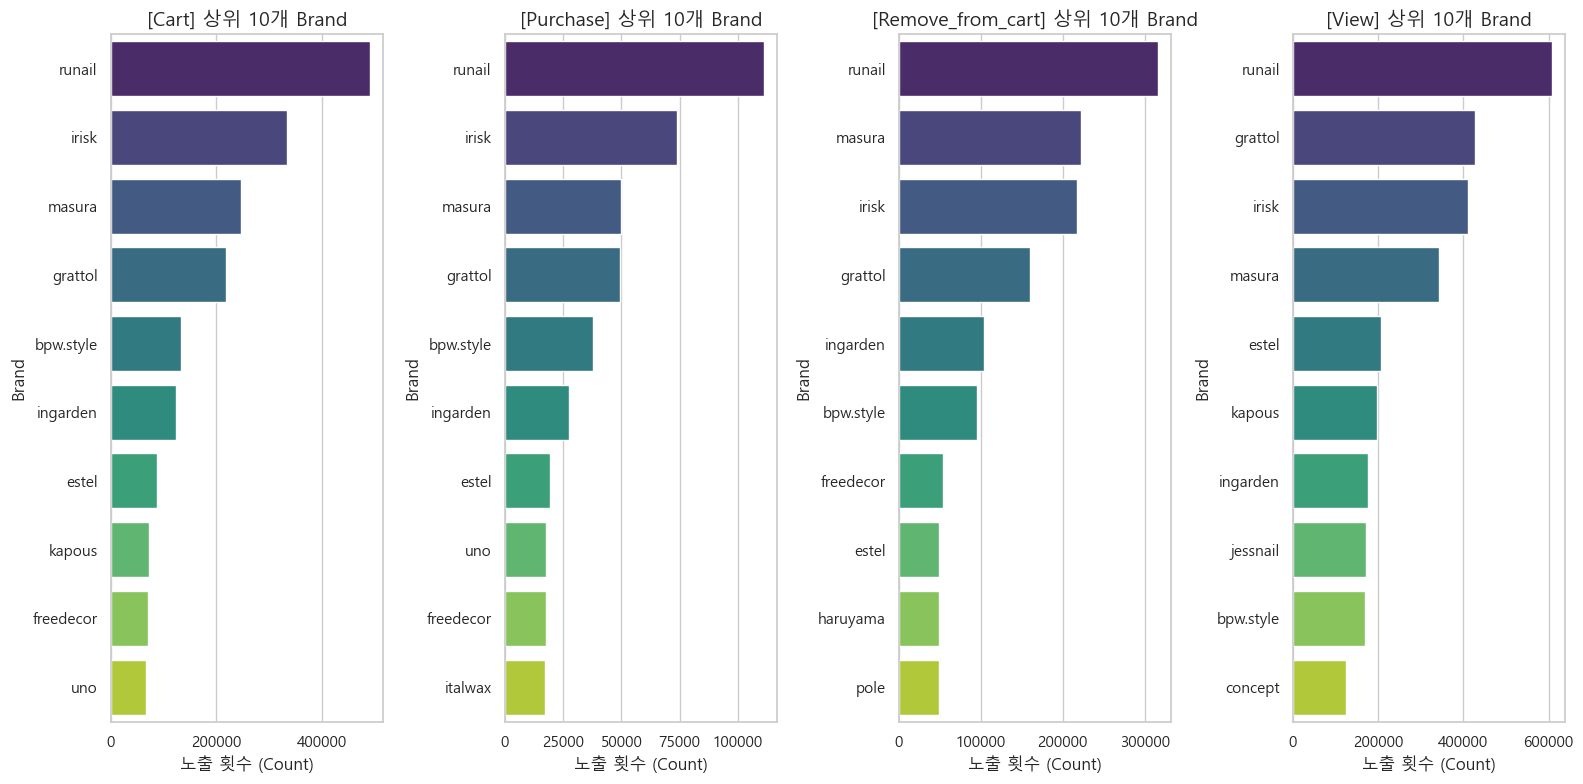

In [79]:
# 설정: 상위/하위 몇 개를 볼 것인지 (N=10으로 설정)
N = 10 

# 1. 'Unknown' 브랜드를 제외하고, 'event_type'과 'brand'만 필터링합니다.
df_filtered = df_combined[df_combined['brand'] != 'Unknown'][['event_type', 'brand']].copy()

# 2. event_type과 brand별 노출 횟수(count) 계산
brand_counts = df_filtered.groupby(['event_type', 'brand']).size().reset_index(name='count')

# 3. 각 event_type별로 순위를 매기기 위해 그룹화 및 결과 저장
results = {}
top_n_for_plot = [] # 시각화를 위해 상위 N개 데이터를 모을 리스트

for event in brand_counts['event_type'].unique():
    # 해당 event_type의 데이터만 필터링
    df_event = brand_counts[brand_counts['event_type'] == event].copy()
    
    # 횟수(count) 기준으로 내림차순 정렬 (상위 N개)
    top_n = df_event.sort_values(by='count', ascending=False).head(N)
    top_n_for_plot.append(top_n) # 시각화 리스트에 추가
    
    # 횟수(count) 기준으로 오름차순 정렬 (하위 N개)
    bottom_n = df_event.sort_values(by='count', ascending=True).head(N)
    
    results[event] = {
        'Top_N': top_n,
        'Bottom_N': bottom_n
    }

# 4. (기존) 결과 출력
print(f"--- 📊 Brand 노출 횟수 (Unknown 제외) - Event Type별 상위/하위 {N}개 ---")
print("-" * 70)

for event, data in results.items():
    print(f"\n====================== 📢 Event Type: {event} ======================")
    
    # 상위 N개 출력
    print(f"--- ✅ 상위 {N}개 Brand (노출 횟수 기준) ---")
    print(data['Top_N'].to_string(index=False))
    
    # 하위 N개 출력
    print(f"\n--- ❌ 하위 {N}개 Brand (노출 횟수 기준) ---")
    print(data['Bottom_N'].to_string(index=False))
    print("=" * 70)

# 5. 시각화 코드 추가 (Event Type별 상위 N개 브랜드)
# 모든 상위 N개 데이터를 하나의 데이터프레임으로 합칩니다.
df_plot = pd.concat(top_n_for_plot)
events = df_plot['event_type'].unique()
n_events = len(events)

plt.figure(figsize=(4 * n_events, 8)) # 전체 figure 크기 조정

for i, event in enumerate(events):
    df_event_top = df_plot[df_plot['event_type'] == event]
    
    plt.subplot(1, n_events, i + 1) # 1행 n_events 열로 서브플롯 생성
    
    # seaborn barplot 사용
    sns.barplot(
        x='count', 
        y='brand', 
        data=df_event_top, 
        palette='viridis', 
        orient='h' # 수평 막대 그래프
    )
    
    plt.title(f'[{event.capitalize()}] 상위 {N}개 Brand', fontsize=14)
    plt.xlabel('노출 횟수 (Count)', fontsize=12)
    plt.ylabel('Brand', fontsize=12)
    plt.ticklabel_format(style='plain', axis='x') # x축 표기를 1e7 대신 실제 숫자로 표시
    
plt.tight_layout() # 서브플롯 간 간격 자동 조정
plt.show()

# Price

In [80]:
df_combined[df_combined['price'] < 0]

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second,time_segment,day_period,weekday_name
693061,2019-12-06 08:44:06,purchase,5670257,1487580014042939619,Unknown,-15.87,410016187,2414f145-f7fa-473f-9d74-41e5694178a0,2019,12,6,8,44,6,06-11시 (오전),월초 (1일 ~ 15일),Friday
942049,2019-12-08 12:38:35,purchase,5670257,1487580014042939619,Unknown,-15.87,579811230,001d3051-07af-1cef-f5e4-10443d9742b9,2019,12,8,12,38,35,12-17시 (오후),월초 (1일 ~ 15일),Sunday
1633142,2019-12-13 08:44:49,purchase,5716859,1487580014042939619,Unknown,-47.62,414087247,6617078d-899a-4b89-8538-b70e505bff38,2019,12,13,8,44,49,06-11시 (오전),월초 (1일 ~ 15일),Friday
1667368,2019-12-13 13:48:10,purchase,5716857,1487580014042939619,Unknown,-23.81,584773479,a3f156d9-b7fc-444d-8899-920715cca75d,2019,12,13,13,48,10,12-17시 (오후),월초 (1일 ~ 15일),Friday
2143701,2019-12-17 10:37:03,purchase,5670257,1487580014042939619,Unknown,-15.87,584498077,ecbf0f7c-3c10-42e8-9af6-1397b5428afa,2019,12,17,10,37,3,06-11시 (오전),월말 (16일 ~ 31일),Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19619234,2020-01-24 21:30:42,purchase,5716859,1487580014042939619,Unknown,-47.62,605668162,1609dc0c-7112-468d-8b5c-1cdcabd4f674,2020,1,24,21,30,42,18-23시 (저녁),월말 (16일 ~ 31일),Friday
19850269,2020-01-26 18:55:52,purchase,5716861,1487580014042939619,Unknown,-79.37,606448681,466cd335-b273-49a4-aefb-3077b5fcd87e,2020,1,26,18,55,52,18-23시 (저녁),월말 (16일 ~ 31일),Sunday
19914917,2020-01-27 08:04:32,view,5716861,1487580014042939619,Unknown,-79.37,531900924,38fe5484-6b5f-44e6-8092-3713df449df7,2020,1,27,8,4,32,06-11시 (오전),월말 (16일 ~ 31일),Monday
19996527,2020-01-27 14:39:33,purchase,5716859,1487580014042939619,Unknown,-47.62,544827743,9bddc864-778a-987e-7f59-a98410752421,2020,1,27,14,39,33,12-17시 (오후),월말 (16일 ~ 31일),Monday


- brand 중 Unknown은 모두 price가 '-' -> 환불?, 환불하면 brand가 자동으로 null설정??

In [81]:
# 1. 가격이 0보다 작은 조건
negative_price = df_combined['price'] < 0

# 2. 브랜드가 'Unknown'이 아닌 조건
not_unknown_brand = df_combined['brand'] != 'Unknown'

# 두 조건을 모두 만족하는 데이터 필터링
df_negative_price_branded = df_combined[negative_price & not_unknown_brand]
df_negative_price_branded

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second,time_segment,day_period,weekday_name


In [82]:
df_combined[(df_combined['price'] > 0) & (df_combined['brand'].isnull())]

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,year,month,day,hour,minute,second,time_segment,day_period,weekday_name


--- Price 컬럼 통계량 ---
count    2.069284e+07
mean     8.534735e+00
std      1.938142e+01
min     -7.937000e+01
25%      2.060000e+00
50%      4.050000e+00
75%      7.060000e+00
max      3.277800e+02
Name: price, dtype: float64


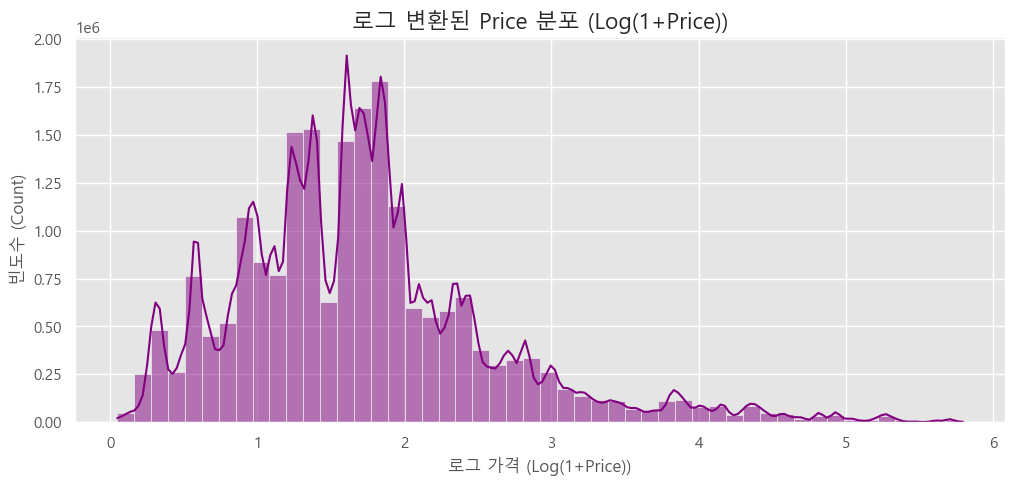

In [83]:
# ----------------------------------------------------
# 폰트 설정 (Windows PC 환경 최적화)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 
plt.style.use('ggplot') 

# 1. 가격 통계량 확인
print("--- Price 컬럼 통계량 ---")
print(df_combined['price'].describe())

# 2. 히스토그램 시각화 (Log 스케일 적용)
# 가격 데이터는 오른쪽으로 긴 꼬리를 가지는 경우가 많아, Log 스케일이 분포를 잘 보여줍니다.
plt.figure(figsize=(12, 5))

# 가격이 0보다 큰 데이터에만 로그 변환 적용
valid_prices = df_combined[df_combined['price'] > 0]['price']

# 로그 변환된 가격 분포 히스토그램
sns.histplot(np.log1p(valid_prices), bins=50, kde=True, color='purple')

plt.title('로그 변환된 Price 분포 (Log(1+Price))', fontsize=16)
plt.xlabel('로그 가격 (Log(1+Price))', fontsize=12)
plt.ylabel('빈도수 (Count)', fontsize=12)
plt.show()

- price 세그먼트 별 구매율(저/중/고가)

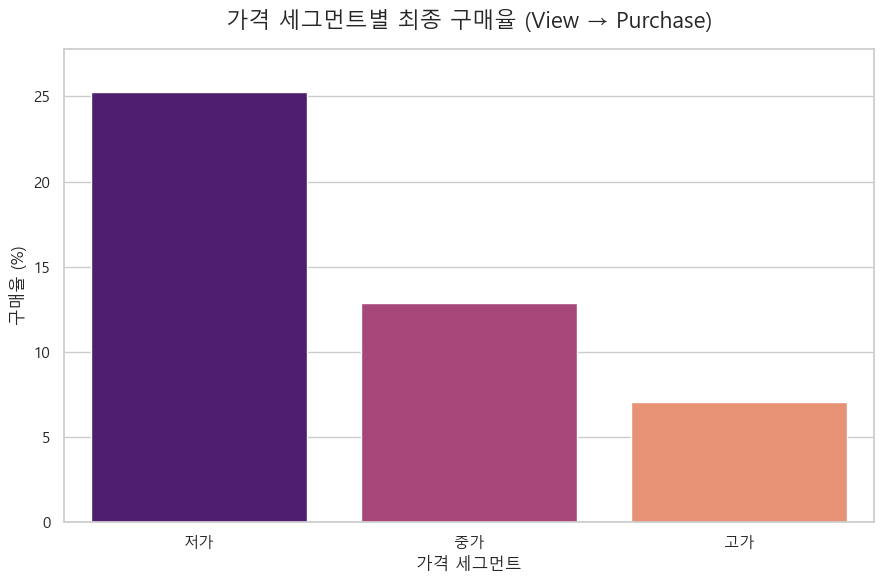


--- 가격 세그먼트별 최종 구매율 ---
price_segment  purchase_rate_percent
           저가               25.2636%
           중가               12.8668%
           고가                7.0772%


In [84]:
warnings.filterwarnings('ignore')

# 📌 폰트 설정
plt.rc("font", family="Malgun Gothic")
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') 

# --------------------- 가격 세그먼트 및 구매율 계산 ---------------------

# 1. price 컬럼의 이상치를 제거한 후 qcut 적용 (0 가격 제외)
# qcut은 NaN 값을 처리하지 못하므로, 유효한 가격(price > 0)에 대해서만 세그먼트화를 진행합니다.
df_valid_price = df_combined[df_combined['price'] > 0].copy()

# 2. qcut을 사용하여 가격을 3개의 구간(Quantile)으로 나눕니다.
# labels=False로 설정하면 구간 경계값(0, 1, 2)이 라벨로 사용됩니다.
try:
    df_valid_price['price_segment'] = pd.qcut(
        df_valid_price['price'],
        q=3,
        labels=['저가', '중가', '고가'],
        duplicates='drop' # 중복 경계값이 발생할 경우 처리 (데이터가 편중될 때 발생)
    )
except ValueError as e:
    # 데이터에 동일한 가격이 많아 3개의 구간을 만들 수 없을 때 (duplicates='drop'으로도 해결 안 될 때)
    print(f"qcut 오류 발생: {e}. 데이터가 너무 편중되어 세그먼트 수를 줄이거나 cut을 사용해야 합니다.")
    # 임시적으로 등간격 cut을 사용하여 대체
    df_valid_price['price_segment'] = pd.cut(
        df_valid_price['price'],
        bins=3,
        labels=['저가', '중가', '고가']
    )


# 3. 가격 세그먼트별 이벤트 수 집계
segment_events = df_valid_price.groupby('price_segment')['event_type'].value_counts().unstack(fill_value=0).reset_index()

# 4. 구매율 (View to Purchase) 계산
# Formula: purchase count / view count (전체 구매 깔때기의 최종 전환율)
if 'view' not in segment_events.columns:
    segment_events['view'] = 0
if 'purchase' not in segment_events.columns:
    segment_events['purchase'] = 0
    
segment_events['purchase_rate'] = segment_events.apply(
    lambda row: row['purchase'] / row['view'] if row['view'] > 0 else 0,
    axis=1
)

# 5. 결과 정리 및 정렬 (구매율 기준 내림차순)
segment_purchase_rate = segment_events[['price_segment', 'purchase_rate']].sort_values(
    by='purchase_rate', ascending=False
)
segment_purchase_rate['purchase_rate_percent'] = segment_purchase_rate['purchase_rate'] * 100

plt.figure(figsize=(9, 6))

# 막대 그래프 생성 (가격 세그먼트별 구매율)
sns.barplot(
    x='price_segment', 
    y='purchase_rate_percent', 
    data=segment_purchase_rate, 
    palette='magma', 
    # qcut의 라벨 순서('저가', '중가', '고가')를 유지하도록 순서 지정
    order=['저가', '중가', '고가']
)

# 그래프 설정
plt.title('가격 세그먼트별 최종 구매율 (View → Purchase)', fontsize=16, pad=15)
plt.xlabel('가격 세그먼트', fontsize=12)
plt.ylabel('구매율 (%)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, segment_purchase_rate['purchase_rate_percent'].max() * 1.1) # Y축 상한 설정
plt.tight_layout()
plt.show()

# 결과 출력 (표)
print("\n--- 가격 세그먼트별 최종 구매율 ---")
print(segment_purchase_rate[['price_segment', 'purchase_rate_percent']].to_string(index=False, float_format='{:.4f}%'.format))

- RFM 의 F/M Score 기준 -> 상위 5/ 5~20/ 20~40/ 40~60/ 60~100% 변경

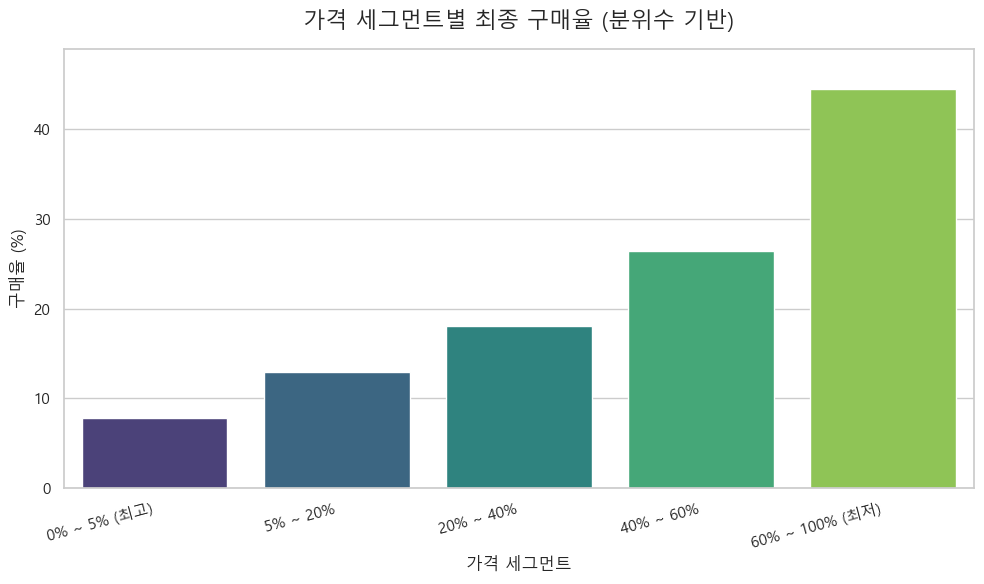


--- 가격 세그먼트별 최종 구매율 ---
  price_segment  purchase_rate_percent
   0% ~ 5% (최고)                7.7618%
       5% ~ 20%               12.9409%
      20% ~ 40%               18.1014%
      40% ~ 60%               26.3966%
60% ~ 100% (최저)               44.5029%


In [103]:
warnings.filterwarnings('ignore')

# 📌 폰트 설정 (이전 설정 재반영)
try:
    plt.rc("font", family="Malgun Gothic")
except:
    pass
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid')

# --------------------- 가격 세그먼트 및 구매율 계산 ---------------------

# df_combined는 전체 이벤트 데이터프레임이라고 가정
df_valid_price = df_combined[df_combined['price'] > 0].copy()

# 2. 가격을 커스텀 5분위 구간으로 나눕니다.
# 📌 커스텀 5분위 기준 적용
q_bins = [0.0, 0.05, 0.20, 0.40, 0.60, 1.0]
q_labels = [
    '60% ~ 100% (최저)', 
    '40% ~ 60%',         
    '20% ~ 40%',         
    '5% ~ 20%',          
    '0% ~ 5% (최고)'     
]

use_qcut_failed = False
try:
    # 2-1. 1차 시도: 분위수 기반 분할 (qcut)
    df_valid_price['price_segment'] = pd.qcut(
        df_valid_price['price'],
        q=q_bins,
        labels=q_labels,
        duplicates='drop'
    )
except ValueError as e:
    # 2-2. qcut 실패 시: 등간격 기반 분할 (cut)으로 대체
    print(f"⚠️ qcut 오류 발생: {e}. 데이터 편중으로 인해 등간격(cut)으로 대체합니다.")
    use_qcut_failed = True
    
    # 등간격 분할을 위한 라벨: 등간격이므로 커스텀 분위수 라벨 대신 단순 라벨 사용
    cut_labels = ['최저가', '저가', '중가', '고가', '최고가']
    df_valid_price['price_segment'] = pd.cut(
        df_valid_price['price'],
        bins=5,
        labels=cut_labels,
        include_lowest=True # cut 함수에서는 include_lowest 사용 가능
    )
    # 그래프 순서를 cut_labels로 변경
    plot_order = cut_labels


# 3. 가격 세그먼트별 이벤트 수 집계
segment_events = df_valid_price.groupby('price_segment')['event_type'].value_counts().unstack(fill_value=0).reset_index()

# 4. 구매율 (View to Purchase) 계산
if 'view' not in segment_events.columns:
    segment_events['view'] = 0
if 'purchase' not in segment_events.columns:
    segment_events['purchase'] = 0
    
segment_events['purchase_rate'] = segment_events.apply(
    lambda row: row['purchase'] / row['view'] if row['view'] > 0 else 0,
    axis=1
)

# 5. 결과 정리 및 시각화 준비
segment_events['purchase_rate_percent'] = segment_events['purchase_rate'] * 100

segment_purchase_rate = segment_events[['price_segment', 'purchase_rate', 'purchase_rate_percent']].sort_values(
    by='purchase_rate', ascending=False
)

# qcut 성공 시 plot_order는 q_labels, 실패 시 cut_labels
if not use_qcut_failed:
    plot_order = q_labels

# 📌 수정된 로직: 그래프와 표의 순서를 모두 '최고가'부터 시작하도록 역순으로 지정
plot_order = q_labels[::-1]

plt.figure(figsize=(10, 6))

# 막대 그래프 생성 (가격 세그먼트별 구매율)
sns.barplot(
    x='price_segment', 
    y='purchase_rate_percent', 
    data=segment_purchase_rate, 
    palette='viridis', 
    order=plot_order # 설정된 순서 유지
)

# 그래프 설정
plt.title(f"가격 세그먼트별 최종 구매율 ({'분위수 기반' if not use_qcut_failed else '등간격 기반'})", fontsize=16, pad=15)
plt.xlabel('가격 세그먼트', fontsize=12)
plt.ylabel('구매율 (%)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, segment_purchase_rate['purchase_rate_percent'].max() * 1.1) 
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show() 

# 결과 출력 (표)
print("\n--- 가격 세그먼트별 최종 구매율 ---")
# 최종 출력 순서도 plot_order를 따르도록 수정
segment_purchase_rate_ordered = segment_events[['price_segment', 'purchase_rate_percent']].set_index('price_segment').loc[plot_order].reset_index()

print(segment_purchase_rate_ordered[['price_segment', 'purchase_rate_percent']].to_string(index=False, float_format='{:.4f}%'.format))

- price 세그먼트 별 각 이벤트 타입 발생 횟수(저/중/고가)

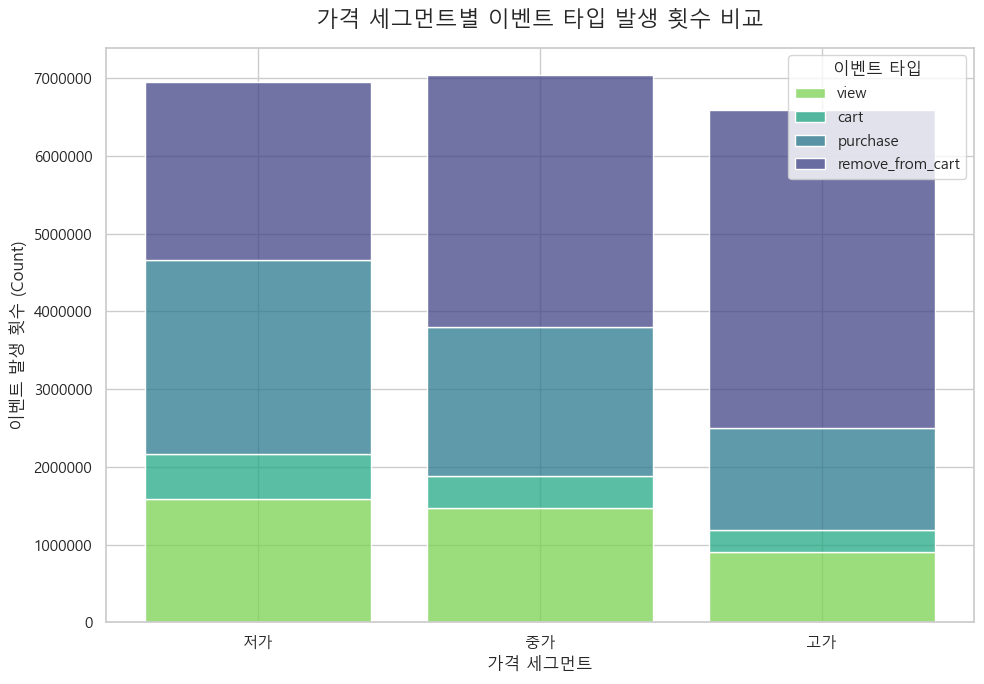


--- 가격 세그먼트별 이벤트 타입별 발생 횟수 ---
event_type        cart  purchase  remove_from_cart     view
price_segment                                              
저가             2492707    580103           1589133  2296200
중가             1911167    417674           1466744  3246147
고가             1315089    289103            899503  4084982


In [85]:
warnings.filterwarnings('ignore')

# 📌 폰트 설정
plt.rc("font", family="Malgun Gothic")
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') 

# --------------------- 가격 세그먼트 및 이벤트 집계 ---------------------

# 1. price 컬럼의 유효 가격(price > 0)에 대해서만 세그먼트화
df_valid_price = df_combined[df_combined['price'] > 0].copy()

# 2. qcut을 사용하여 가격을 3개의 구간(Quantile)으로 나눕니다.
try:
    df_valid_price['price_segment'] = pd.qcut(
        df_valid_price['price'],
        q=3,
        labels=['저가', '중가', '고가'],
        duplicates='drop'
    )
except ValueError as e:
    print(f"⚠️ qcut 오류 발생: {e}. 등간격 cut으로 대체합니다.")
    df_valid_price['price_segment'] = pd.cut(
        df_valid_price['price'],
        bins=3,
        labels=['저가', '중가', '고가']
    )

# 3. 가격 세그먼트별 이벤트 타입 발생 횟수를 집계
# .unstack()을 사용하여 이벤트를 컬럼으로 만듭니다.
segment_events_counts = df_valid_price.groupby('price_segment')['event_type'].value_counts().unstack(fill_value=0)

# 4. 시각화를 위해 인덱스(세그먼트) 순서를 정의
segment_order = ['저가', '중가', '고가']
segment_events_counts = segment_events_counts.reindex(segment_order)

# 5. 시각화를 위해 데이터 형태를 Seaborn이 이해하기 쉽도록 변환 (Stacking 해제)
# Index를 컬럼으로 만들고, 이벤트 타입을 새로운 컬럼으로 만듭니다.
df_plot = segment_events_counts.reset_index().melt(
    id_vars='price_segment', 
    var_name='event_type', 
    value_name='count'
)

plt.figure(figsize=(10, 7))

# 누적 막대 그래프 생성 (kind='bar'는 Matplotlib 기본 기능이지만, Seaborn의 색상 사용)
sns.histplot(
    data=df_plot,
    x='price_segment',
    weights='count', # 'count' 컬럼을 높이로 사용
    hue='event_type', # 'event_type' 컬럼을 색상 구분자로 사용 (누적)
    multiple='stack', # 막대를 누적하여 표시
    palette='viridis', 
    hue_order=['view', 'cart', 'purchase', 'remove_from_cart'], # 이벤트 순서 지정
    shrink=0.8
)

# 그래프 설정
plt.title('가격 세그먼트별 이벤트 타입 발생 횟수 비교', fontsize=16, pad=15)
plt.xlabel('가격 세그먼트', fontsize=12)
plt.ylabel('이벤트 발생 횟수 (Count)', fontsize=12)
plt.legend(title='이벤트 타입', labels=['view', 'cart', 'purchase', 'remove_from_cart'])
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

# 결과 출력 (표)
print("\n--- 가격 세그먼트별 이벤트 타입별 발생 횟수 ---")
print(segment_events_counts.to_string(float_format='{:,}'.format))

- RFM 의 F/M Score 기준 -> 상위 5/ 5~20/ 20~40/ 40~60/ 60~100% 변경

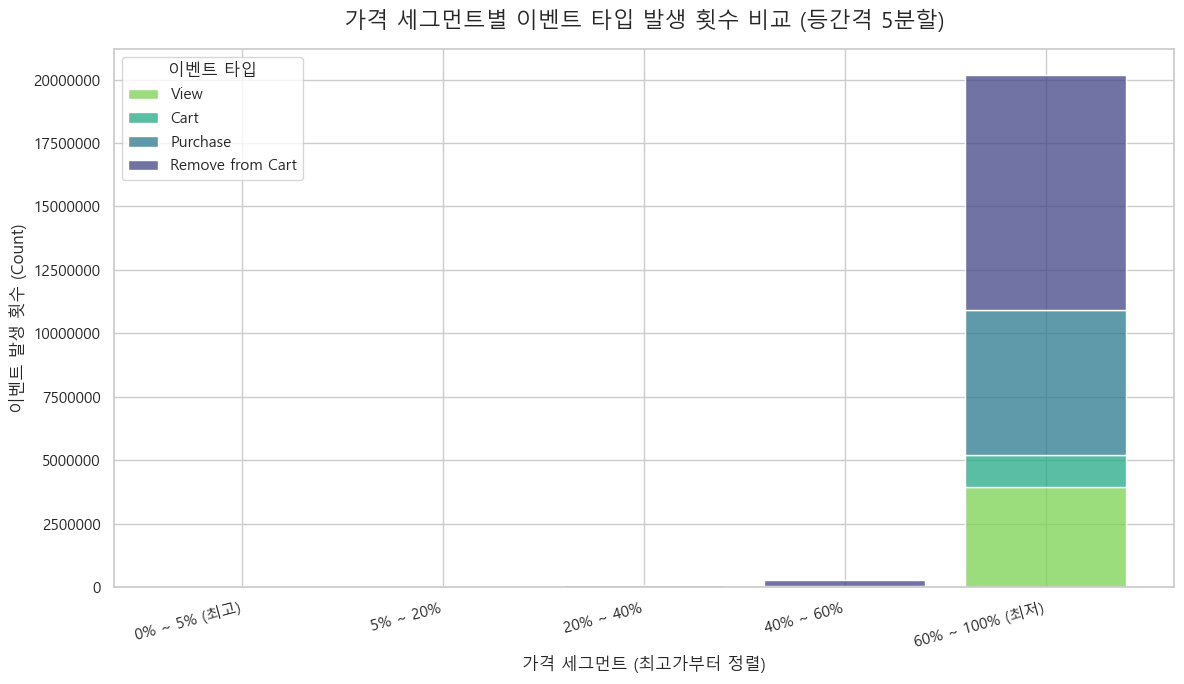


--- 가격 세그먼트별 이벤트 타입별 발생 횟수 ---
event_type          cart  purchase  remove_from_cart     view
price_segment                                                
0% ~ 5% (최고)        1312       116               902    15655
5% ~ 20%            1174       163               780    13218
20% ~ 40%           6282       984              4052    81809
40% ~ 60%          16852      2929             11191   237351
60% ~ 100% (최저)  5693343   1282688           3938455  9279296


In [105]:
warnings.filterwarnings('ignore')

# 📌 폰트 설정
try:
    plt.rc("font", family="Malgun Gothic")
except:
    pass
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') 

# --------------------- 가격 세그먼트 및 이벤트 집계 ---------------------

# df_combined는 전체 이벤트 데이터프레임이라고 가정
# 1. price 컬럼의 유효 가격(price > 0)에 대해서만 세그먼트화
df_valid_price = df_combined[df_combined['price'] > 0].copy()

# 2. pd.qcut 대신 pd.cut (등간격)을 사용하여 가격을 5개의 구간으로 나눕니다.
# 📌 수정된 로직: pd.cut 사용 (가격 범위 기준 5등분)
# 라벨을 커스텀 분위수 라벨과 유사하게 설정하여 통일성을 유지합니다.
cut_labels_5 = [
    '60% ~ 100% (최저)',  # 가격 범위가 가장 낮은 그룹
    '40% ~ 60%',         
    '20% ~ 40%',         
    '5% ~ 20%',          
    '0% ~ 5% (최고)'     # 가격 범위가 가장 높은 그룹
]

# pd.cut을 사용하여 5개의 동일한 가격 범위 구간을 생성
df_valid_price['price_segment'] = pd.cut(
    df_valid_price['price'],
    bins=5, # 5개의 등간격 구간
    labels=cut_labels_5,
    include_lowest=True, # 최솟값을 포함
    duplicates='drop'
)


# 3. 가격 세그먼트별 이벤트 타입 발생 횟수를 집계
# .unstack()을 사용하여 이벤트를 컬럼으로 만듭니다.
segment_events_counts = df_valid_price.groupby('price_segment')['event_type'].value_counts().unstack(fill_value=0)

# 4. 시각화를 위해 인덱스(세그먼트) 순서를 정의
# 📌 수정된 로직: 최고가 세그먼트가 상단(그래프의 왼쪽)에 오도록 순서 역순 정의
segment_order = cut_labels_5[::-1] # 최고가부터 최저가 순으로 역순 정렬
segment_events_counts = segment_events_counts.reindex(segment_order)

# 5. 시각화를 위해 데이터 형태를 Seaborn이 이해하기 쉽도록 변환
df_plot = segment_events_counts.reset_index().melt(
    id_vars='price_segment', 
    var_name='event_type', 
    value_name='count'
)

plt.figure(figsize=(12, 7))

# 누적 막대 그래프 생성
sns.histplot(
    data=df_plot,
    x='price_segment',
    weights='count', 
    hue='event_type', 
    multiple='stack', 
    palette='viridis', 
    hue_order=['view', 'cart', 'purchase', 'remove_from_cart'], # 이벤트 순서 지정
    # order=segment_order, # 📌 수정된 로직: 최고가부터 정렬
    shrink=0.8
)

# 그래프 설정
plt.title('가격 세그먼트별 이벤트 타입 발생 횟수 비교 (등간격 5분할)', fontsize=16, pad=15)
plt.xlabel('가격 세그먼트 (최고가부터 정렬)', fontsize=12)
plt.ylabel('이벤트 발생 횟수 (Count)', fontsize=12)
plt.legend(title='이벤트 타입', labels=['View', 'Cart', 'Purchase', 'Remove from Cart'])
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show() 

# 결과 출력 (표)
print("\n--- 가격 세그먼트별 이벤트 타입별 발생 횟수 ---")
print(segment_events_counts.to_string(float_format='{:,}'.format))

- 고액자(total price 높은사람) 특징 파악 -> 평균 구매단가/주요 활동 시간대/주 구매 카테고리

💰 고액자 기준 금액 (상위 5% 컷오프): >= 192.77
총 고객 수: 110,518
고액자 고객 수 (상위 5%): 5,526

--- 📊 고액자 그룹 (Top 5%) 핵심 통계 ---
                 count   mean    std    min     max
total_price    5526.00 342.49 214.11 192.78 3785.03
purchase_count 5526.00  61.54  47.61   1.00  715.00

평균 구매 단가 (AOV): 14.09

--- ⏰ 고액자 주 활동 시간대 (구매 이벤트 기준) ---
hour event_count proportion
   0       3,708      1.09%
   1       4,450      1.31%
   2       5,199      1.53%
   3       5,408      1.59%
   4       7,191      2.11%
   5      11,423      3.36%
   6      14,627      4.30%
   7      15,020      4.42%
   8      16,419      4.83%
   9      18,936      5.57%

--- 🛒 고액자 주 구매 카테고리 (Top 5) ---
        category_id proportion
1487580007675986893      0.07%
1487580006317032337      0.04%
1487580005092295511      0.04%
1487580005595612013      0.03%
1602943681873052386      0.03%

--- 💵 고액자 주 구매 가격대 (Price Segment) ---
  price_segment proportion
   0% ~ 5% (최고)      0.40%
       5% ~ 20%      0.19%
      20% ~ 40%      0.20%
  

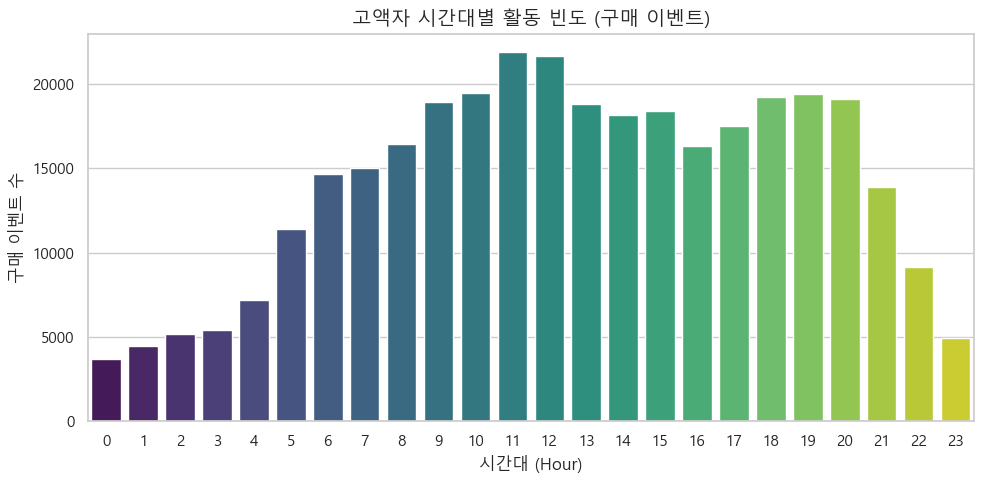

In [108]:
# 📌 폰트 설정 및 경고 무시
warnings.filterwarnings('ignore')
try:
    plt.rc("font", family="Malgun Gothic")
except:
    pass
sns.set(font="Malgun Gothic", 
        rc={"axes.unicode_minus": False}, 
        style='whitegrid') 

# df_combined는 전체 이벤트 데이터프레임이라고 가정하며, 'event_time'은 datetime 객체라고 가정

# --------------------- 1. 고객별 총 구매액 및 구매 횟수 계산 ---------------------

df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()
df_purchase.loc[df_purchase['price'] < 0, 'price'] = 0

user_revenue = df_purchase.groupby('user_id').agg(
    total_price=('price', 'sum'),
    purchase_count=('event_type', 'count')
).reset_index()

# --------------------- 2. 고액자 그룹 정의 (Total Price 상위 5%) ---------------------

revenue_threshold = user_revenue['total_price'].quantile(0.95)
user_revenue['is_top_5_percent'] = user_revenue['total_price'] >= revenue_threshold
top_spenders = user_revenue[user_revenue['is_top_5_percent']].copy()

top_spender_ids = top_spenders['user_id'].tolist()
df_top_spender_events = df_purchase[df_purchase['user_id'].isin(top_spender_ids)].copy()

# --------------------- 3. 고액자 활동 특징 분석 (결과 출력) ---------------------
print(f"💰 고액자 기준 금액 (상위 5% 컷오프): >= {revenue_threshold:,.2f}")
print(f"총 고객 수: {len(user_revenue):,}")
print(f"고액자 고객 수 (상위 5%): {len(top_spenders):,}\n")

print("--- 📊 고액자 그룹 (Top 5%) 핵심 통계 ---")
print(top_spenders[['total_price', 'purchase_count']].describe().loc[['count', 'mean', 'std', 'min', 'max']].T.to_string(float_format='{:.2f}'.format))

top_spenders['AOV'] = top_spenders['total_price'] / top_spenders['purchase_count']
aov_mean = top_spenders['AOV'].mean()
print(f"\n평균 구매 단가 (AOV): {aov_mean:,.2f}\n")

# --------------------- 4. 고액자 주 활동 시간대 분석 ---------------------

df_top_spender_events['hour'] = df_top_spender_events['event_time'].dt.hour
hour_activity = df_top_spender_events['hour'].value_counts().sort_index().reset_index()
hour_activity.columns = ['hour', 'event_count']
hour_activity['proportion'] = hour_activity['event_count'] / hour_activity['event_count'].sum() * 100

print("--- ⏰ 고액자 주 활동 시간대 (구매 이벤트 기준) ---")
hour_formatters = {
    'hour': lambda x: f'{x:.0f}',
    'event_count': lambda x: f'{x:,.0f}',
    'proportion': lambda x: f'{x:.2f}%'
}
print(hour_activity.head(10).to_string(index=False, formatters=hour_formatters))

# --------------------- 5. 고액자 주 구매 제품군 (Top Category) 분석 (오류 해결) ---------------------

top_categories = df_top_spender_events['category_id'].value_counts(normalize=True).head(5).reset_index()
top_categories.columns = ['category_id', 'proportion']

print("\n--- 🛒 고액자 주 구매 카테고리 (Top 5) ---")
category_formatters = {
    'proportion': lambda x: f'{x:.2f}%'
}
print(top_categories.to_string(index=False, formatters=category_formatters))

# --------------------- 6. 고액자 주 구매 가격대 (Price Segment) 분석 (오류 해결) ---------------------

q_bins = [0.0, 0.05, 0.20, 0.40, 0.60, 1.0]
q_labels = [
    '60% ~ 100% (최저)',
    '40% ~ 60%',         
    '20% ~ 40%',         
    '5% ~ 20%',          
    '0% ~ 5% (최고)'
]

try:
    df_top_spender_events['price_segment'] = pd.qcut(
        df_top_spender_events['price'],
        q=q_bins,
        labels=q_labels,
        duplicates='drop'
    )
    
    segment_counts = df_top_spender_events['price_segment'].value_counts(normalize=True).reindex(q_labels[::-1]).reset_index()
    segment_counts.columns = ['price_segment', 'proportion']
    
    print("\n--- 💵 고액자 주 구매 가격대 (Price Segment) ---")
    segment_formatters = {
        'proportion': lambda x: f'{x:.2f}%'
    }
    print(segment_counts.to_string(index=False, formatters=segment_formatters))
    
except ValueError as e:
    print(f"\n❌ 고액자 가격 세그먼트 분석 오류: {e}. 데이터가 너무 편중되어 분위수 분할이 불가능합니다.")

# --------------------- 7. 시각화: 고액자 활동 시간대 ---------------------

plt.figure(figsize=(10, 5))
sns.barplot(x='hour', y='event_count', data=hour_activity, palette='viridis')
plt.title('고액자 시간대별 활동 빈도 (구매 이벤트)', fontsize=14)
plt.xlabel('시간대 (Hour)', fontsize=12)
plt.ylabel('구매 이벤트 수', fontsize=12)
plt.tight_layout()
plt.show()

# 전환율(Conversion_rate)

In [86]:
# 1. event_type별 총 개수 계산
event_counts = df_combined['event_type'].value_counts()

# 각 이벤트의 개수를 변수에 할당합니다.
view_count = event_counts.get('view', 0)
cart_count = event_counts.get('cart', 0)
purchase_count = event_counts.get('purchase', 0)
remove_count = event_counts.get('remove_from_cart', 0)

# 결과를 저장할 딕셔너리
results = {}

# 2. 지표 계산 및 예외 처리 (분모가 0인 경우)

# 장바구니 전환율: cart 수 / view 수
if view_count > 0:
    cart_conver_rate = cart_count / view_count
    results['장바구니 전환율 (View to Cart)'] = f"{cart_conver_rate * 100:.2f}%"
else:
    results['장바구니 전환율 (View to Cart)'] = "N/A (View 수 0)"

# 구매 전환율 (Cart to Purchase): purchase 수 / cart 수
if cart_count > 0:
    purchase_conver_rate = purchase_count / cart_count
    results['구매 전환율 (Cart to Purchase)'] = f"{purchase_conver_rate * 100:.2f}%"
else:
    results['구매 전환율 (Cart to Purchase)'] = "N/A (Cart 수 0)"

# 최종 구매 전환율 (View to Purchase): purchase 수 / view 수
if view_count > 0:
    final_conver_rate = purchase_count / view_count
    results['최종 구매 전환율 (View to Purchase)'] = f"{final_conver_rate * 100:.2f}%"
else:
    results['최종 구매 전환율 (View to Purchase)'] = "N/A (View 수 0)"

# 장바구니 이탈율: remove_from_cart 수 / cart 수
if cart_count > 0:
    removal_rate = remove_count / cart_count
    results['장바구니 이탈율 (Cart Removal)'] = f"{removal_rate * 100:.2f}%"
else:
    results['장바구니 이탈율 (Cart Removal)'] = "N/A (Cart 수 0)"

# 3. 결과 출력
print("--- 구매 깔때기 핵심 지표 ---")
for key, value in results.items():
    print(f"{key}: {value}")

df_combined['cart_conver_rate'] = cart_conver_rate
df_combined['purchase_conver_rate'] = purchase_conver_rate
df_combined['final_conver_rate'] = final_conver_rate
df_combined['removal_rate'] = removal_rate

--- 구매 깔때기 핵심 지표 ---
장바구니 전환율 (View to Cart): 59.73%
구매 전환율 (Cart to Purchase): 22.31%
최종 구매 전환율 (View to Purchase): 13.33%
장바구니 이탈율 (Cart Removal): 68.99%


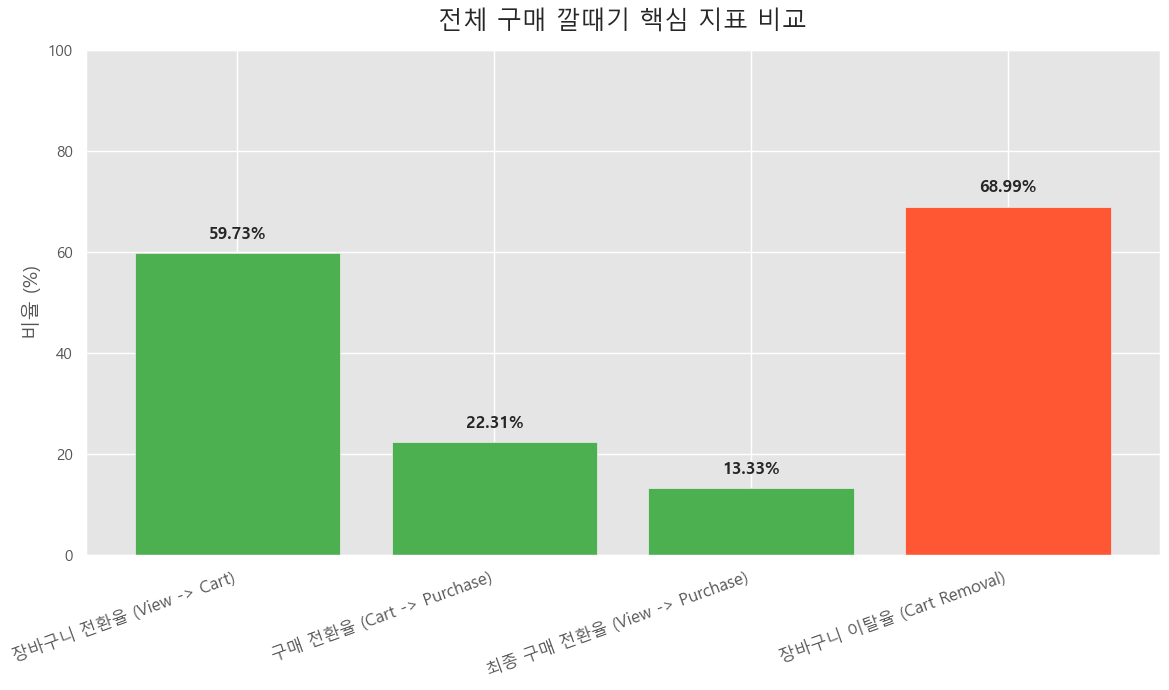

In [87]:
# 경고 메시지 무시 및 한글 폰트 설정 (이전 설정 유지)
warnings.filterwarnings('ignore')
try:
    plt.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot') # 그래프 스타일 설정

# 1. 네 가지 지표 값 설정
data = {
    '지표': [
        '장바구니 전환율 (View -> Cart)', 
        '구매 전환율 (Cart -> Purchase)', 
        '최종 구매 전환율 (View -> Purchase)', # 추가된 지표
        '장바구니 이탈율 (Cart Removal)'
    ],
    '비율': [
        59.73, 
        22.31, 
        13.33, # 추가된 값
        68.99
    ],
    '유형': [
        '전환 (긍정)', 
        '전환 (긍정)', 
        '전환 (긍정)', 
        '이탈 (부정)'
    ]
}
df_metrics = pd.DataFrame(data)

# 2. 시각화 (막대 그래프)
plt.figure(figsize=(12, 7))

# 유형에 따라 색상 설정
colors = ['#4CAF50' if t == '전환 (긍정)' else '#FF5733' for t in df_metrics['유형']]

ax = plt.bar(df_metrics['지표'], df_metrics['비율'], color=colors)

# 3. 그래프 설정
plt.title('전체 구매 깔때기 핵심 지표 비교', fontsize=18, pad=15)
plt.ylabel('비율 (%)', fontsize=14)
plt.ylim(0, 100)
plt.xticks(rotation=20, ha='right', fontsize=12) # 라벨 회전 및 글꼴 크기 조정

# 막대 위에 비율(%) 값 표시
for bar in ax:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [88]:
df_combined.columns

Index(['event_time', 'event_type', 'product_id', 'category_id', 'brand',
       'price', 'user_id', 'user_session', 'year', 'month', 'day', 'hour',
       'minute', 'second', 'time_segment', 'day_period', 'weekday_name',
       'cart_conver_rate', 'purchase_conver_rate', 'final_conver_rate',
       'removal_rate'],
      dtype='object')

# RFM Segment

- qcut = 30 적용

In [89]:
# 분석 기준일 설정 (Recency 계산을 위해 전체 데이터 중 가장 최근 날짜의 다음 날짜로 설정)
# 실제 데이터의 최종 시간으로 설정하는 것이 가장 정확합니다.
# 예시로, df_combined의 최대 event_time에 하루를 더한 시점으로 설정합니다.
ANALYSIS_DATE = df_combined['event_time'].max() + pd.Timedelta(days=1)
print(f"분석 기준일: {ANALYSIS_DATE}")

# 1. 'purchase' 이벤트만 필터링하고 R, F, M 계산에 필요한 데이터프레임 생성
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()

# 2. RFM 지표 계산
rfm_df = df_purchase.groupby('user_id').agg(
    # Recency: 분석 기준일과 최종 구매일 간의 차이 (일 단위)
    Recency=('event_time', lambda x: (ANALYSIS_DATE - x.max()).days),
    
    # Frequency: 총 구매 횟수 (거래 수)
    Frequency=('user_id', 'count'),
    
    # Monetary: 총 구매액 (price의 합)
    Monetary=('price', 'sum')
).reset_index()

# 3. RFM 점수화 (Scoring) - qcut을 사용하여 5분위 점수 부여 (1점 ~ 5점)

# [Frequency, Monetary] 점수화: 값이 클수록 10점 (Top 10%가 10점)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 30, labels=False, duplicates='drop') + 1 # 1부터 10점
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 30, labels=False, duplicates='drop') + 1 # 1부터 10점

# [Recency] 점수화: 값이 작을수록 10점 (최근 구매했을수록 10점)
# labels=False로 0부터 9를 받은 후, 10에서 빼고 1을 더하여 10부터 1점으로 역전
rfm_df['R_Score'] = 30 - pd.qcut(rfm_df['Recency'], 30, labels=False, duplicates='drop')


# 4. 최종 RFM 점수 결합 (세그먼트 정의를 위해 사용)
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df['RFM_Total'] = rfm_df['R_Score'].astype(int) + rfm_df['F_Score'].astype(int) + rfm_df['M_Score'].astype(int)


# 5. 🎉 RFM_Total을 기준으로 내림차순 정렬 추가
# 가장 높은 점수(15점)를 받은 고객이 최상단에 위치합니다.
rfm_sorted_by_total = rfm_df.sort_values(by='RFM_Total', ascending=False)


print("\n--- 💯 최종 RFM 점수화 결과 (RFM 총점 기준 상위 20개) ---")
print(rfm_sorted_by_total[['user_id', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score', 'RFM_Score', 'RFM_Total']].head(20).to_string(index=False))

분석 기준일: 2020-03-01 23:59:59

--- 💯 최종 RFM 점수화 결과 (RFM 총점 기준 상위 20개) ---
  user_id  Recency  R_Score  Frequency  F_Score  Monetary  M_Score RFM_Score  RFM_Total
498066896        4       30         89       19    385.07       30    301930         79
601541842        1       30         81       19    383.88       30    301930         79
556579890        3       30        506       19   1392.45       30    301930         79
539825777        3       30         86       19    275.46       30    301930         79
502942288        1       30        128       19    374.15       30    301930         79
549842627        3       30         64       19    283.19       30    301930         79
530311269        4       30         75       19    269.44       30    301930         79
530711990        4       30         87       19    784.31       30    301930         79
313585716        4       30        111       19    577.00       30    301930         79
461684991        3       30        118       19 

- qcut = 30 적용 -> 히스토그램

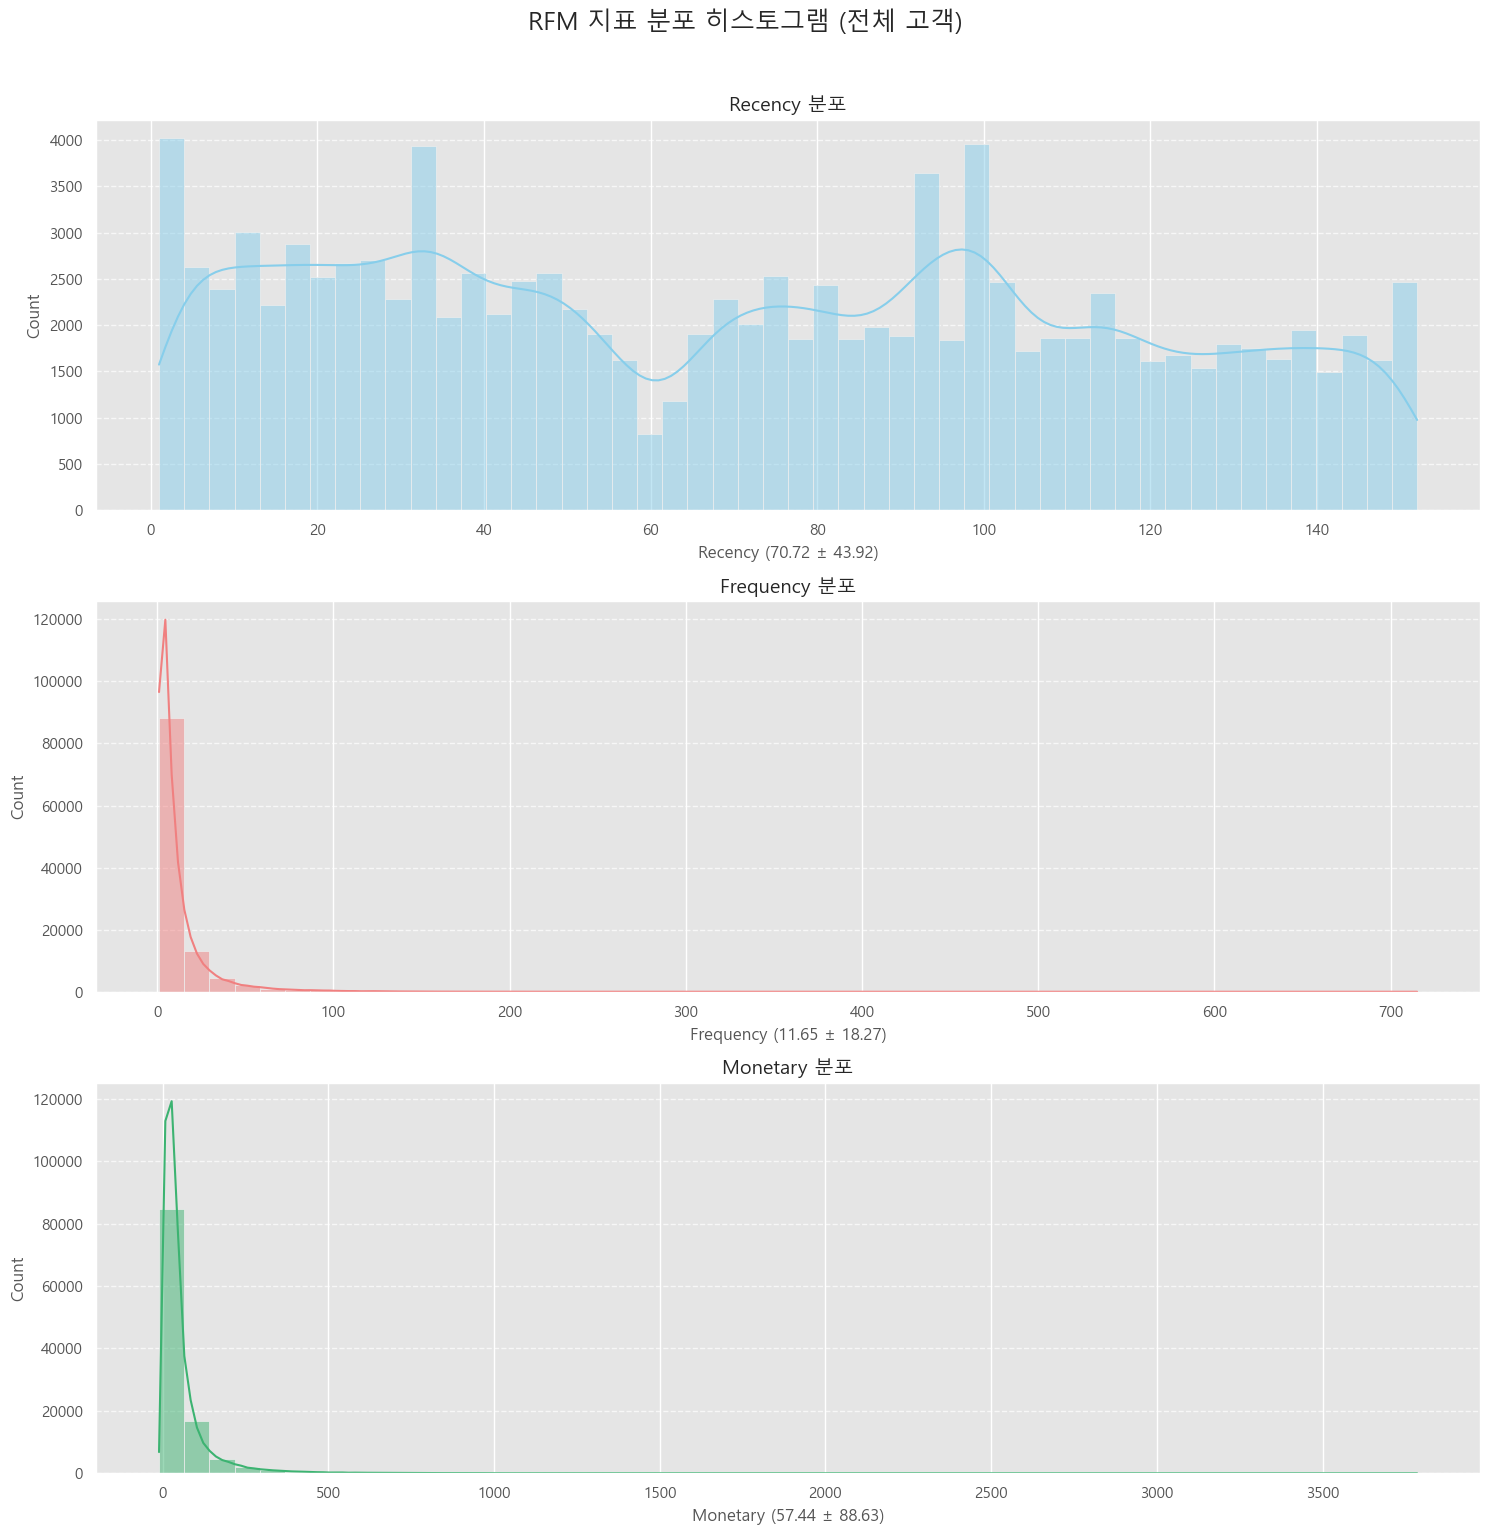


--- 📊 RFM 지표 주요 통계 요약 ---
             Recency      Frequency       Monetary
count  110518.000000  110518.000000  110518.000000
mean       70.723574      11.645225      57.438651
std        43.917114      18.265518      88.630745
min         1.000000       1.000000     -10.520000
25%        32.000000       3.000000      16.240000
50%        71.000000       6.000000      33.180000
75%       106.000000      13.000000      61.510000
max       152.000000     715.000000    3785.030000


In [90]:

# 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (이전 단계에서 설정한 폰트를 재확인)
try:
    plt.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False

# rfm_df 데이터프레임이 이전 단계에서 이미 계산되었다고 가정합니다.

# 1. 히스토그램을 그릴 RFM 지표 리스트 정의
rfm_cols = ['Recency', 'Frequency', 'Monetary']

# 2. 3x1 서브플롯 생성
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
plt.suptitle('RFM 지표 분포 히스토그램 (전체 고객)', fontsize=18, y=1.02)

for i, col in enumerate(rfm_cols):
    ax = axes[i]
    
    # seaborn displot (히스토그램) 사용
    sns.histplot(
        rfm_df[col],
        bins=50, # 더 자세한 분포를 보기 위해 빈(bin) 개수를 50개로 설정
        kde=True, # 커널 밀도 추정 곡선 추가
        ax=ax,
        color='skyblue' if col == 'Recency' else ('lightcoral' if col == 'Frequency' else 'mediumseagreen')
    )
    
    # Frequency와 Monetary는 값이 극단적으로 크면 로그 스케일 적용을 고려할 수 있습니다.
    # 여기서는 일반 스케일로 보여주되, 너무 치우쳐 있으면 로그 스케일 주석을 추가합니다.
    
    # x축 레이블 설정
    ax.set_xlabel(f'{col} ({rfm_df[col].describe().loc["mean"]:.2f} ± {rfm_df[col].describe().loc["std"]:.2f})', fontsize=12)
    ax.set_title(f'{col} 분포', fontsize=14)
    ax.ticklabel_format(style='plain', axis='y') # Y축은 일반 숫자로 표시
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 극단값 제거 후 분포를 보고 싶다면, 99.5% 분위수(percentile)까지로 x축 제한
    # p995 = rfm_df[col].quantile(0.995)
    # ax.set_xlim(0, p995) # 주석 처리됨: 모든 데이터 분포를 일단 확인하기 위함

plt.tight_layout()
plt.show()

print("\n--- 📊 RFM 지표 주요 통계 요약 ---")
print(rfm_df[rfm_cols].describe())

- 상위 20개 -> 상위 5/ 5~20/ 20~40/ 40~60/ 60~100% 변경

분석 기준일: 2020-03-01 23:59:59

--- 💯 최종 RFM 점수화 결과 (R, F, M 점수 우선순위 정렬 상위 20개) ---
  user_id  Recency  R_Score  Frequency  F_Score  Monetary  M_Score RFM_Score  RFM_Total
 50764735       22        5         52        5    330.01        5       555         15
 56612519       24        5         88        5    264.18        5       555         15
 83998413       22        5         89        5    299.19        5       555         15
105697630       12        5        118        5    501.35        5       555         15
107945915        1        5        163        5    479.00        5       555         15
132692896        5        5         68        5    203.10        5       555         15
142717569       13        5         82        5    334.30        5       555         15
146699059       23        5         44        5    350.65        5       555         15
150318419        1        5        370        5   3785.03        5       555         15
151229872        3        5         80 

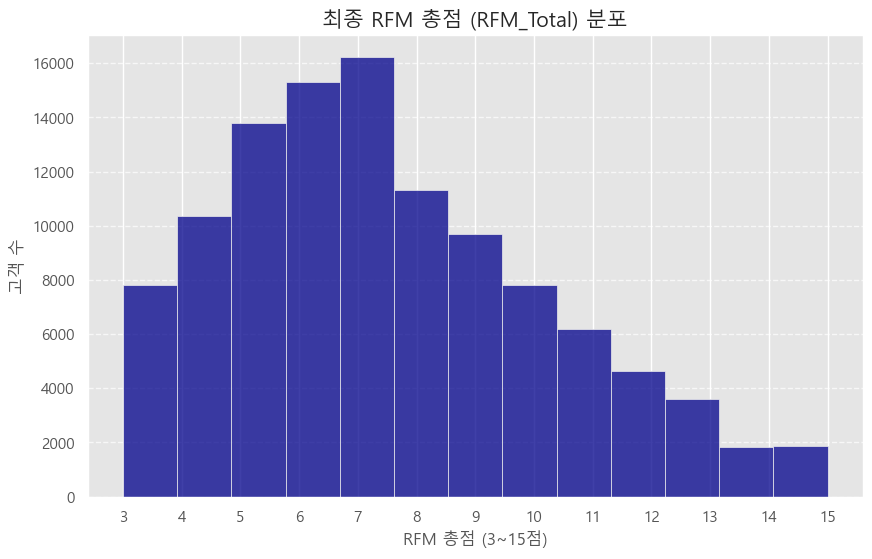

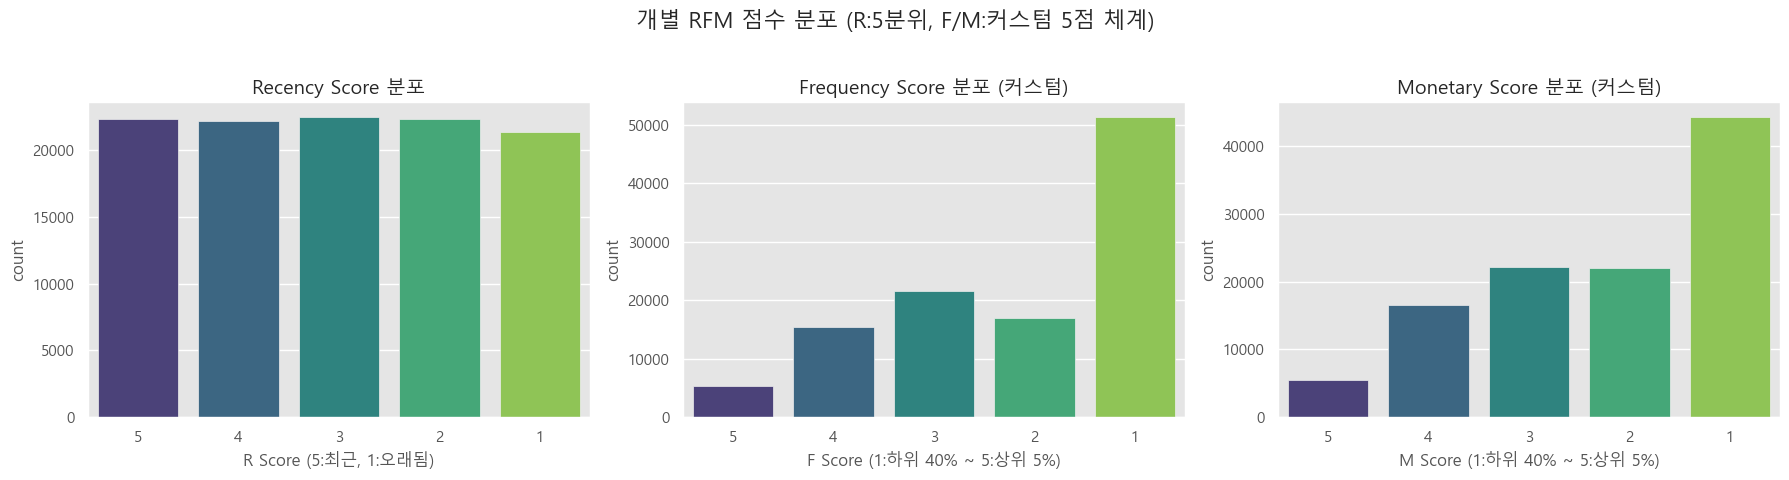

In [91]:
# 분석 기준일 설정 (이전 단계와 동일)
ANALYSIS_DATE = df_combined['event_time'].max() + pd.Timedelta(days=1)
print(f"분석 기준일: {ANALYSIS_DATE}")

# 'purchase' 이벤트만 필터링하고 R, F, M 계산
df_purchase = df_combined[df_combined['event_type'] == 'purchase'].copy()
rfm_df = df_purchase.groupby('user_id').agg(
    Recency=('event_time', lambda x: (ANALYSIS_DATE - x.max()).days),
    Frequency=('user_id', 'count'),
    Monetary=('price', 'sum')
).reset_index()


# --- 2. RFM 점수화 (커스텀 5점 체계) ---

# A. Recency Score (R_Score): 5분위 (Qcut=5) 적용
# 값이 작을수록 (최근일수록) 5점 (labels=[5, 4, 3, 2, 1])
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)


# B. Frequency Score (F_Score): 불균등 5분위 적용 (40% 분위수 추가)
# F_Scores를 계산할 구간 (Thresholds) 설정: 40%, 60%, 80%, 95%
F_thresholds = rfm_df['Frequency'].quantile([0.40, 0.60, 0.80, 0.95]).tolist()
F_thresholds.insert(0, rfm_df['Frequency'].min() - 1) 
F_thresholds.append(rfm_df['Frequency'].max())

F_conditions = [
    (rfm_df['Frequency'] > F_thresholds[4]), # F > 95% -> 5점 (5%)
    (rfm_df['Frequency'] > F_thresholds[3]) & (rfm_df['Frequency'] <= F_thresholds[4]), # F > 80% ~ 95% -> 4점 (15%)
    (rfm_df['Frequency'] > F_thresholds[2]) & (rfm_df['Frequency'] <= F_thresholds[3]), # F > 60% ~ 80% -> 3점 (20%)
    (rfm_df['Frequency'] > F_thresholds[1]) & (rfm_df['Frequency'] <= F_thresholds[2]), # F > 40% ~ 60% -> 2점 (20%)
    (rfm_df['Frequency'] > F_thresholds[0]) & (rfm_df['Frequency'] <= F_thresholds[1])  # F <= 40% -> 1점 (40%)
]
F_values = [5, 4, 3, 2, 1] 
rfm_df['F_Score'] = np.select(F_conditions, F_values, default=1)


# C. Monetary Score (M_Score): 불균등 5분위 적용 (40% 분위수 추가)
M_thresholds = rfm_df['Monetary'].quantile([0.40, 0.60, 0.80, 0.95]).tolist()
M_thresholds.insert(0, rfm_df['Monetary'].min() - 1)
M_thresholds.append(rfm_df['Monetary'].max())

M_conditions = [
    (rfm_df['Monetary'] > M_thresholds[4]), # M > 95% -> 5점 (5%)
    (rfm_df['Monetary'] > M_thresholds[3]) & (rfm_df['Monetary'] <= M_thresholds[4]), # M > 80% ~ 95% -> 4점 (15%)
    (rfm_df['Monetary'] > M_thresholds[2]) & (rfm_df['Monetary'] <= M_thresholds[3]), # M > 60% ~ 80% -> 3점 (20%)
    (rfm_df['Monetary'] > M_thresholds[1]) & (rfm_df['Monetary'] <= M_thresholds[2]), # M > 40% ~ 60% -> 2점 (20%)
    (rfm_df['Monetary'] > M_thresholds[0]) & (rfm_df['Monetary'] <= M_thresholds[1])  # M <= 40% -> 1점 (40%)
]
M_values = [5, 4, 3, 2, 1]
rfm_df['M_Score'] = np.select(M_conditions, M_values, default=1)


# --- 3. 최종 점수 결합 및 정렬 ---

rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df['RFM_Total'] = rfm_df['R_Score'].astype(int) + rfm_df['F_Score'].astype(int) + rfm_df['M_Score'].astype(int)

# R, F, M 점수 우선순위로 정렬 (Recency 우선)
rfm_sorted_by_priority = rfm_df.sort_values(
    by=['R_Score', 'F_Score', 'M_Score'],
    ascending=[False, False, False]
)

print("\n--- 💯 최종 RFM 점수화 결과 (R, F, M 점수 우선순위 정렬 상위 20개) ---")
print(rfm_sorted_by_priority[['user_id', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score', 'RFM_Score', 'RFM_Total']].head(20).to_string(index=False))

print("\n--- 📊 F/M Score 커스텀 분위수 (Quantile) ---")
print(f"Frequency: 40%={rfm_df['Frequency'].quantile(0.40):.2f}, 60%={rfm_df['Frequency'].quantile(0.60):.2f}, 80%={rfm_df['Frequency'].quantile(0.80):.2f}, 95%={rfm_df['Frequency'].quantile(0.95):.2f}")
print(f"Monetary: 40%={rfm_df['Monetary'].quantile(0.40):.2f}, 60%={rfm_df['Monetary'].quantile(0.60):.2f}, 80%={rfm_df['Monetary'].quantile(0.80):.2f}, 95%={rfm_df['Monetary'].quantile(0.95):.2f}")


# --- 4. RFM 점수 분포 시각화 (수정) ---

# RFM_Total 점수 분포 시각화 (3점 ~ 15점)
plt.figure(figsize=(10, 6))
sns.histplot(rfm_df['RFM_Total'], bins=13, kde=False, color='darkblue') 
plt.title('최종 RFM 총점 (RFM_Total) 분포', fontsize=15)
plt.xlabel('RFM 총점 (3~15점)', fontsize=12)
plt.ylabel('고객 수', fontsize=12)
plt.xticks(range(3, 16))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# RFM Score별 고객 수 (R_Score, F_Score, M_Score)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('개별 RFM 점수 분포 (R:5분위, F/M:커스텀 5점 체계)', fontsize=16)

# R_Score (5분위)
sns.countplot(x='R_Score', data=rfm_df, ax=axes[0], palette='viridis', order=[5, 4, 3, 2, 1])
axes[0].set_title('Recency Score 분포', fontsize=14)
axes[0].set_xlabel('R Score (5:최근, 1:오래됨)')

# F_Score (커스텀 5점 체계) - 1점과 2점 분리 확인
sns.countplot(x='F_Score', data=rfm_df, ax=axes[1], palette='viridis', order=[5, 4, 3, 2, 1])
axes[1].set_title('Frequency Score 분포 (커스텀)', fontsize=14)
axes[1].set_xlabel('F Score (1:하위 40% ~ 5:상위 5%)')

# M_Score (커스텀 5점 체계) - 1점과 2점 분리 확인
sns.countplot(x='M_Score', data=rfm_df, ax=axes[2], palette='viridis', order=[5, 4, 3, 2, 1])
axes[2].set_title('Monetary Score 분포 (커스텀)', fontsize=14)
axes[2].set_xlabel('M Score (1:하위 40% ~ 5:상위 5%)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()